# Homework: Airbnb Database Analysis
## Group 18 members:
1. `Part A: 20250436 | Joao Paulo de Avila`
2. `Part B: 20250448 | Lucas Campos Ferreira`
3. `Part C: Student number | Full name`
4. `Part D: 20250399 | Pedro Miguel Gaspar Santos`
5. `Part E: 20250418 | Pedro Miguel Goncalves Fernandes`

## Table of Contents

- [Setup and Connection](#setup-and-connection)
- [Variables](#variables)
- [Functions](#functions)
- [Reset Database](#reset-database)
- [Pre-processing and Cleaning](#pre-processing-and-cleaning)
    - [Quality Checks](#quality-checks)
    - [Make Clean Collection](#make-clean-collection)
- [Pattern Motivation Analysis](#pattern-motivation-analysis)
- [Index Creation](#index-creation)
- [Task A](#task-a)
    - [A1 - Price Analysis](#a1---price-analysis)
    - [A2 - Query Pipeline Analysis](#a2---query-pipeline-analysis)
    - [A3 - Analytical Price Suggestion](#a3---analytical-price-suggestion)
- [Task B](#task-b)
    - [B1 - Score Analysis](#b1-score-analysis)
    - [B2 - Review Quality and Activity Score](#b2-review-quality-and-activity-score)
    - [B3 - Long-Term Rental Suggestion](#b3-long-term-rental-suggestion)
- [Task D](#task-d)
    - [D1 - Host Type and Pricing](#d1-host-type-and-pricing)
    - [D2 - Host Features Impact on Satisfaction](#d2-host-features-impact-on-satisfaction)
    - [D3 - Property Popularity and Satisfaction](#d3-property-popularity-and-satisfaction)
- [Task E](#task-e)
    - [E1 - Property Size and Pricing](#e1---property-size-and-pricing)
    - [E2 - Multi-property Ownership and Bookings](#e2---multi-property-ownership-and-bookings)
    - [E3 - Property Size and Property Comfort](#e3---property-size-and-property-comfort)

## Setup and Connection


In [1]:
from __future__ import annotations
from datetime import datetime
from typing import Any
import time, warnings
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from bson.decimal128 import Decimal128
from bson.json_util import dumps
from pymongo import MongoClient, UpdateOne
from pprint import pprint
from collections import defaultdict

import sys


warnings.filterwarnings("ignore")

# ── Connection ──────────────────────────────────────────────────────────────
user="AzureDiamond"
password="hunter2"
host="localhost"
port="27017"
protocol="mongodb"
ip = "100.89.43.91"  # Tailscale VPN IP

try:
    # Try local connection first
    uri = f"{protocol}://{user}:{password}@{host}:{port}"
    
    client = MongoClient(uri, serverSelectionTimeoutMS=1000)
    client.admin.command('ping')
    print("Connected successfully! Using local MongoDB")
except Exception as e:
    print(f"Local connection failed: {e}")
    try:
        # Fall back to Tailscale VPN
        host = ip
        uri = f"{protocol}://{user}:{password}@{host}:{port}"
        client = MongoClient(uri, serverSelectionTimeoutMS=1000)
        client.admin.command('ping')
        print("Connected successfully! Using Tailscale VPN")
    except Exception as e2:
        print(f"Tailscale connection failed: {e2}")
        raise ConnectionError("Failed to connect to MongoDB via local or Tailscale VPN")

db = client.sample_airbnb
print(f"Database info: {db}\n")

# ── Custom index registry ──────────────────────────────────────────────────
INDEX_REGISTRY: dict[str, list[dict[str, Any]]] = {
    # Indexes in listings collection:
    "listings": [
        {"keys": [("address.market", 1), ("property_type", 1)], "name": "idx_market_proptype"},
        {"keys": [("amenities", 1)], "name": "idx_amenities", "sparse": True},
        {"keys": [("host.host_id", 1)], "name": "idx_host_id"},
        {"keys": [("host.host_is_superhost", 1), ("address.market", 1)], "name": "idx_superhost_market"},
        {"keys": [("address.market", 1), ("number_of_reviews", 1)], "name": "idx_market_nreviews"},
        {"keys": [("address.market", 1), ("price", 1)], "name": "idx_market_price"},
        {"keys": [("address.market", 1), ("review_scores.review_scores_rating", 1)], "name": "idx_market_rating"},
        {"keys": [("address.market", 1), ("amenities", 1), ("property_type", 1)], "name": "idx_market_amenities_property_type"},
        {"keys": [("host_type", 1), ("popularity_score", 1)], "name": "idx_pro_popularity",
            "partialFilterExpression": {
                "host_type": {"$eq": "professional"},
                "popularity_score": {"$gte": 0},
            },
        },
    ],

    # Indexes in reviews collection:
    "reviews": [
        {"keys": [("listing_id", 1), ("date", 1)], "name": "idx_listing_date"},
    ],

    # Indexes in hosts collection:
    "hosts": [
        {"keys": [("host_traits.k", 1), ("host_traits.v", 1)], "name": "idx_host_traits_kv", "sparse": True},
        {"keys": [("avg_rating", 1)], "name": "idx_hosts_avg_rating"},
    ],
}

# Index impact assessment: verify each custom index is used and measure the gain
INDEX_TESTS = [
    ("idx_market_proptype", "listings", {"address.market": "Hong Kong", "property_type": "Apartment"}, "Filter listings by market + property_type"),
    ("idx_amenities", "listings", {"amenities": "Wifi"}, "Find listings that include 'Wifi' amenity"),
    ("idx_host_id", "listings", {"host.host_id": "6530888"}, "Look up listings by host_id"),
    ("idx_superhost_market", "listings", {"host.host_is_superhost": True, "address.market": "Montreal"}, "Filter superhosts in a specific market"),
    ("idx_market_nreviews", "listings", {"address.market": "New York", "number_of_reviews": {"$gte": 10}}, "Active listings (>=10 reviews) in New York"),
    ("idx_market_price", "listings", {"address.market": "Barcelona"}, "All listings in Barcelona"),
    ("idx_market_amenities_property_type", "listings", {"address.market": "New York", "amenities": "Wifi", "property_type": "Apartment"}, "Filter by market + amenity + property type"),
    ("idx_pro_popularity", "listings", {"host_type": "professional", "popularity_score": {"$gte": 0}}, "Professional hosts with non-negative popularity score"),
    ("idx_listing_date", "reviews", {"listing_id": "10006546"}, "All reviews for a specific listing"),
    ("idx_host_traits_kv", "hosts", {"host_traits.k": "host_is_superhost", "host_traits.v": True}, "Hosts by trait key/value pair"),
    ("idx_hosts_avg_rating", "hosts", {"avg_rating": {"$gte": 4.5}}, "Top-rated hosts (avg_rating >= 4.5)"),

]

Connected successfully! Using local MongoDB
Database info: Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, serverselectiontimeoutms=1000), 'sample_airbnb')



We start by defining some global aspects of the project - variables, helper functions, and the database reset - so that all tasks share the same foundation.

## Variables


Here we define all constants and task-specific variables used throughout the notebook - city lists, property type groups, feature labels and so on. Centralising them in one cell ensures consistency and makes updates straightforward.

In [2]:
# ── Shared / Setup ──────────────────────────────────────────────────────────
CLEAN_COLL = "listingsAndReviews_HW2_clean"
TEXT_FIELDS = [
    "summary", "space", "description", "neighborhood_overview",
    "notes", "transit", "access", "interaction", "house_rules",
]
EXCLUDE = set(["reviews", "review_scores_rating"] + TEXT_FIELDS)
SUBSET_N = 5  # Subset Pattern: how many recent reviews to embed

# ── Shared city list and colour palette (consistent across all graphs) ─────
CITIES = ["Hong Kong", "Montreal", "Barcelona"]
CITY_PALETTE = {"Hong Kong": "#636EFA", "Montreal": "#EF553B", "Barcelona": "#00CC96"}

# ── Task A1 - Price Analysis ───────────────────────────────────────────────
# Also reused by A3
PROPERTY_TYPES_A1 = ["Apartment", "Guesthouse", "Hostel", "House", "Townhouse"]

# ── Task A2 - Query Pipeline Analysis ──────────────────────────────────────
required_amenities_a2 = ["Wifi", "Hair dryer", "24-hour check-in", "Air conditioning", "Bed linens"]
wheelchair_amenities_a2 = ["Elevator", "Ground floor access", "Wheelchair accessible", "Wide doorway", "Disabled parking spot"]
family_amenities_a2 = ["Crib", "Family/kid friendly", "Stair gates", "Table corner guards"]

# ── Task A3 - Analytical Price Suggestion ──────────────────────────────────
matching_levels_a3 = [
    (["market", "property_type", "room_type", "accommodates"], "same market + property type + room type + accommodates"),
    (["market", "property_type", "room_type"], "same market + property type + room type"),
    (["market", "property_type"], "same market + property type"),
    (["property_type", "room_type"], "same property type + room type"),
    (["property_type"], "same property type"),
    (["market"], "same market"),
]

# ── Task B1 - Score Analysis ──────────────────────────────────────────────
CATEGORIES = [
    "review_scores_cleanliness", "review_scores_accuracy",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
]

# ── Task B3 - Long-Term Rental Suggestion ──────────────────────────────────
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# ── Task D2 - Host Features Impact on Satisfaction ─────────────────────────
FEATURES = [
    "is_superhost",
    "is_identity_verified",
    "is_fast_responder",
    "is_perfect_responder",
    "is_flexible_cancellation",
]
LABELS = {
    "is_superhost":             "Superhost",
    "is_identity_verified":     "Identity verified",
    "is_fast_responder":        "Fast responder",
    "is_perfect_responder":     "Perfect responder",
    "is_flexible_cancellation": "Flexible cancellation",
}

# ── Task D3 - Property Popularity and Satisfaction ─────────────────────────
PROP_TYPES_D3 = ["Apartment", "Condominium", "Serviced apartment"]
SAT_ORDER = ["Low", "Medium", "High"]

# # ── Task E1 - Property Size and Pricing ────────────────────────────────────
SIZE_ORDER = ["Small", "Medium", "Large"]

# # ── Task E2 - Multi-property Ownership and Bookings ───────────────────────
# HOST_ORDER = ["Amateur", "Professional"]

# ── Task E3 - Property Size and Property Comfort ──────────────────────────
SIZE_GROUP_ORDER = ["Small", "Medium", "Large"]
SIZE_PALETTE = {"Small": "#636EFA", "Medium": "#EF553B", "Large": "#00CC96"}


# Property-type family mapping (similar types grouped together)
PROPERTY_FAMILY = {
    # Apartment family
    "Apartment":         "Apartment",
    "Condominium":       "Apartment",
    "Loft":              "Apartment",
    "Serviced apartment":"Apartment",
    "Aparthotel":        "Apartment",
    # House family
    "House":             "House",
    "Townhouse":         "House",
    "Guest suite":       "House",
    "Villa":             "House",
    "Cottage":           "House",
    "Bungalow":          "House",
    "Cabin":             "House",
    "Tiny house":        "House",
    "Chalet":            "House",
    # B&B / Hostel family
    "Bed and breakfast": "B&B/Hostel",
    "Hostel":            "B&B/Hostel",
    "Guesthouse":        "B&B/Hostel",
    "Hotel":             "B&B/Hostel",
    "Boutique hotel":    "B&B/Hostel",
    "Heritage hotel (India)": "B&B/Hostel",
}  # everything else -> "Other"  # everything else -> "Other"

print("All variables loaded.")

All variables loaded.


# Functions


All shared helper functions are defined here, grouped by purpose: index management (create, hide, restore), explain and performance comparison utilities, derived-field helpers (size classification, satisfaction banding), and plotting functions (box plot, lollipop, scatter, violin, bar chart, multi-panel grid). Keeping them in a single cell ensures every task reuses the same tested logic, and makes the individual task cells shorter and focused on the analysis itself.

In [3]:
# ── Setup - Index management ────────────────────────────────────────────────
def delete_specific_index(database: Any, idx_name: str) -> None:
    """Delete a specific index from the database."""
    for coll, indexes in INDEX_REGISTRY.items():
        for idx in indexes:
            if idx["name"] == idx_name:
                try:
                    database[coll].drop_index(idx_name)
                except Exception:
                    pass


def hide_custom_indexes(database: Any) -> None:
    """Hide all custom indexes in the registry (keeps them on disk)."""
    for coll, indexes in INDEX_REGISTRY.items():
        for idx in indexes:
            try:
                database.command({"collMod": coll, "index": {"name": idx["name"], "hidden": True}})
            except Exception:
                pass


def ensure_custom_indexes(database: Any) -> None:
    """Create every index in the registry if it doesn't exist, unhide it if it does."""
    for coll, indexes in INDEX_REGISTRY.items():
        existing = set(database[coll].index_information().keys())
        for idx in indexes:
            if idx["name"] in existing:
                try:
                    database.command({"collMod": coll, "index": {"name": idx["name"], "hidden": False}})
                except Exception:
                    pass
            else:
                kwargs = {k: v for k, v in idx.items() if k != "keys"}
                database[coll].create_index(idx["keys"], **kwargs)


# ── Setup - Explain & performance helpers ──────────────────────────────────

def find_scan_stage(plan: dict[str, Any]) -> dict[str, Any]:
    """Walk inputStage chain to the leaf scan stage."""
    while "inputStage" in plan:
        plan = plan["inputStage"]
    return plan


def parse_agg_explain(expl: dict[str, Any]) -> dict[str, Any]:
    """Extract key metrics from an aggregation explain result."""
    m: dict[str, Any] = {}
    stages = expl.get("stages", [])
    if stages:
        cur = stages[0].get("$cursor", {})
        es = cur.get("executionStats", {})
        qp = cur.get("queryPlanner", {}).get("winningPlan", {})
        leaf = find_scan_stage(qp)
        m["Scan type"] = leaf.get("stage", "-")
        m["Index used"] = leaf.get("indexName", "none")
        m["Docs examined"] = es.get("totalDocsExamined", "-")
        m["Keys examined"] = es.get("totalKeysExamined", "-")
        m["Returned"] = es.get("nReturned", "-")
        m["Exec time (ms)"] = es.get("executionTimeMillis", "-")
    return m


def explain_compare(
    database: Any,
    collection: str,
    pipeline_before: list[dict[str, Any]],
    pipeline_after: list[dict[str, Any]],
    label_before: str = "Before (no indexes, naive)",
    label_after: str = "After (indexes + optimised)",
    extra_before: dict[str, Any] | None = None,
    extra_after: dict[str, Any] | None = None,
) -> pd.DataFrame:
    """Hide all custom indexes, explain + time pipeline_before, ensure indexes exist, then explain + time pipeline_after."""
    explain_fn = lambda p: database.command({
        "explain": {"aggregate": collection, "pipeline": p, "cursor": {}},
        "verbosity": "executionStats",
    })

    hide_custom_indexes(database)

    t0 = time.time()
    expl_b = explain_fn(pipeline_before)
    wall_b = round((time.time() - t0) * 1000, 1)
    t0 = time.time()
    list(database[collection].aggregate(pipeline_before))
    exec_b = round((time.time() - t0) * 1000, 1)

    ensure_custom_indexes(database)

    t0 = time.time()
    expl_a = explain_fn(pipeline_after)
    wall_a = round((time.time() - t0) * 1000, 1)
    t0 = time.time()
    list(database[collection].aggregate(pipeline_after))
    exec_a = round((time.time() - t0) * 1000, 1)

    before_m = parse_agg_explain(expl_b)
    after_m = parse_agg_explain(expl_a)
    before_m["Pipeline exec (ms)"] = exec_b
    after_m["Pipeline exec (ms)"] = exec_a
    before_m["Wall time (ms)"] = wall_b
    after_m["Wall time (ms)"] = wall_a
    if extra_before:
        before_m.update(extra_before)
    if extra_after:
        after_m.update(extra_after)

    return pd.DataFrame({label_before: before_m, label_after: after_m})


# ── Setup - Index impact assessment ────────────────────────────────────────

def explain_find(coll, query, projection=None):
    """Run .explain() on a find query and extract key metrics."""
    cmd = coll.find(query, projection or {}).explain()
    es  = cmd.get("executionStats", {})
    plan = cmd.get("queryPlanner", {}).get("winningPlan", {})
    leaf = find_scan_stage(plan)
    return {
        "scan_type": leaf.get("stage", "-"),
        "index_used": leaf.get("indexName", "none"),
        "docs_examined": es.get("totalDocsExamined", "-"),
        "keys_examined": es.get("totalKeysExamined", "-"),
        "returned": es.get("nReturned", "-"),
        "exec_ms": es.get("executionTimeMillis", "-"),
    }


# ── Shared derived-field helpers ───────────────────────────────────────────

def size_cat(accommodates) -> str | None:
    """Classify by accommodates: small/medium/large."""
    if accommodates is None:
        return None
    if accommodates <= 2:
        return "small"
    if accommodates <= 5:
        return "medium"
    return "large"


# ── Plotting - Shared across all tasks ─────────────────────────────────────

def plot_boxplot(
    data: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    xlabel: str,
    ylabel: str,
    hue: str | None = None,
    order: list[str] | None = None,
    hue_order: list[str] | None = None,
    palette: str | dict = "Set2",
    figsize: tuple[int, int] = (14, 5),
    rotate_x: int = 0,
    legend_loc: str = "best",
    whis: float | tuple = 1.5,
    showfliers: bool = True,
    show_min_max: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        order=order,
        hue_order=hue_order,
        palette=palette,
        fliersize=2,
        linewidth=0.8,
        whis=whis,
        showfliers=showfliers,
        ax=ax,
    )

    if show_min_max:
        x_levels = order or list(pd.unique(data[x]))

        if hue:
            hue_levels = hue_order or list(pd.unique(data[hue]))
            stats = data.groupby([x, hue])[y].agg(["min", "max"]).reset_index()
            step = 0.8 / len(hue_levels)

            for _, row in stats.iterrows():
                xpos = x_levels.index(row[x]) - 0.4 + step * (hue_levels.index(row[hue]) + 0.5)
                ax.scatter(xpos, row["min"], color="black", marker="v", s=25, zorder=4)
                ax.scatter(xpos, row["max"], color="black", marker="^", s=25, zorder=4)
        else:
            stats = data.groupby(x)[y].agg(["min", "max"]).reset_index()

            for _, row in stats.iterrows():
                xpos = x_levels.index(row[x])
                ax.scatter(xpos, row["min"], color="black", marker="v", s=25, zorder=4)
                ax.scatter(xpos, row["max"], color="black", marker="^", s=25, zorder=4)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if hue:
        ax.legend(title=hue.replace("_", " ").title(), loc=legend_loc)

    if rotate_x:
        ax.tick_params(axis="x", rotation=rotate_x)

    plt.tight_layout()
    plt.show()


def plot_violin(
    data: pd.DataFrame,
    x: str,
    y: str,
    hue: str | None = None,
    order: list[str] | None = None,
    hue_order: list[str] | None = None,
    palette: dict[str, str] | str | None = None,
    title: str = "",
    xlabel: str = "",
    ylabel: str = "",
    figsize: tuple[int, int] = (14, 6),
    legend_loc: str = "best",
    inner: str = "box",
    cut: float = 0,
) -> None:
    """Violin plot with optional hue grouping (mirrors plot_boxplot API)."""
    fig, ax = plt.subplots(figsize=figsize)

    sns.violinplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        order=order,
        hue_order=hue_order,
        palette=palette,
        inner=inner,
        cut=cut,
        linewidth=0.8,
        ax=ax,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if hue:
        ax.legend(title=hue.replace("_", " ").title(), loc=legend_loc)

    plt.tight_layout()
    plt.show()


def plot_lollipop(
    data: pd.DataFrame,
    x: str,
    y_cols: list[str],
    labels: list[str],
    title: str,
    xlabel: str,
    ylabel: str,
    colors: list[str] | None = None,
    figsize: tuple[int, int] = (14, 6),
    rotate_x: int = 30,
) -> None:
    """Double lollipop chart for side-by-side category comparison."""
    if colors is None:
        colors = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]
    fig, ax = plt.subplots(figsize=figsize)
    x_pos = range(len(data))
    for i, (col, label) in enumerate(zip(y_cols, labels)):
        offset = (i - len(y_cols) / 2 + 0.5) * 0.15
        positions = [p + offset for p in x_pos]
        ax.vlines(positions, 0, data[col], color=colors[i % len(colors)], linewidth=1.5)
        ax.scatter(positions, data[col], color=colors[i % len(colors)], s=50, zorder=3, label=label)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(data[x], rotation=rotate_x, ha="right")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_scatter(
    data: pd.DataFrame,
    x: str,
    y: str,
    size: str,
    color_col: str,
    title: str,
    xlabel: str,
    ylabel: str,
    palette: dict[str, str] | None = None,
    size_scale: float = 3.0,
    figsize: tuple[int, int] = (12, 6),
    xtick_labels: list[str] | None = None,
    size_legend_label: str | None = None,
) -> None:
    """Scatter plot with size and color per category, jittered to avoid overlap."""
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(figsize=figsize)
    categories = data[color_col].unique().tolist()
    n_cats = len(categories)
    jitter_width = 0.25
    offsets = {cat: (i - (n_cats - 1) / 2) * jitter_width for i, cat in enumerate(categories)}
    for cat in categories:
        sub = data[data[color_col] == cat]
        c = palette[cat] if palette and cat in palette else None
        ax.scatter(
            sub[x] + offsets[cat], sub[y], s=sub[size] * size_scale,
            c=c, alpha=0.75, edgecolors="k", linewidth=0.5,
            label=cat, zorder=3,
        )
    if xtick_labels:
        ax.set_xticks(range(1, len(xtick_labels) + 1))
        ax.set_xticklabels(xtick_labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Build a clean two-section legend: color (categories) + bubble size
    color_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=palette.get(cat, "grey"),
               markeredgecolor="k", markersize=10, label=cat)
        for cat in categories
    ]

    if size_legend_label:
        raw_vals = data[size].dropna()
        if len(raw_vals):
            q_lo = int(raw_vals.quantile(0.25))
            q_mid = int(raw_vals.median())
            q_hi = int(raw_vals.quantile(0.75))
            blank = Line2D([0], [0], color="w", markersize=0, label="")
            size_handles = [
                Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
                       markeredgecolor="k", markersize=sz, alpha=0.5,
                       label=f"{val}")
                for val, sz in [(q_lo, 7), (q_mid, 11), (q_hi, 15)]
            ]
            ax.legend(
                handles=color_handles + [blank] + size_handles,
                loc="upper left", framealpha=0.9, fontsize=9,
                title="City", title_fontsize=10,
            )
        else:
            ax.legend(handles=color_handles, title="City", loc="upper left", framealpha=0.9, fontsize=9)
    else:
        ax.legend(handles=color_handles, title="City", loc="upper left", framealpha=0.9, fontsize=9)

    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── Plotting - Task A2 bar plot comparison ─────────────────────────────────

def plot_barplot(
    data: pd.DataFrame,
    metrics: list[tuple[str, str]],
    x: str = "Version",
    palette: str = "Set2",
    suptitle: str = "",
    figsize: tuple[int, int] = (12, 4),
) -> None:
    """Side-by-side bar charts for comparing metrics (e.g. before/after)."""
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, (col, label) in zip(axes, metrics):
        sns.barplot(data=data, x=x, y=col, palette=palette, ax=ax)
        ax.set_title(label)
        ax.set_xlabel("")
        ax.set_ylabel(col)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# ── Plotting - Task E1, E2, E3 multi-panel box plots ──────────────────────

def plot_grid_boxplot(
    data: pd.DataFrame,
    row_col: str,
    col_col: str,
    value_col: str,
    row_order: list[str],
    col_order: list[str],
    col_labels: dict[str, str],
    row_palette: dict[str, str],
    title: str,
    ylabel: str = "Value",
    figsize: tuple[int, int] = (16, 14),
    iqr_upper: float = 2.5,
    iqr_lower: float = 1.0,
    median_fmt: str = "${:.0f}",
    y_fmt: str | None = "$%.0f",
) -> None:
    """Draw a rows×cols grid of box plots with shared y-axis per row.

    Parameters
    ----------
    data        : DataFrame with at least row_col, col_col, value_col columns.
    row_col     : Column used for rows (e.g. "city").
    col_col     : Column used for columns (e.g. "size_category").
    value_col   : Numeric column for the y-axis.
    row_order   : Ordered list of row values.
    col_order   : Ordered list of column values.
    col_labels  : Mapping from col value to display label (shown on last row).
    row_palette : Mapping from row value to a hex colour.
    title       : Figure super-title.
    ylabel      : Y-axis label (left column only).
    figsize     : Figure size.
    iqr_upper   : Multiplier above Q3 for y-limit.
    iqr_lower   : Multiplier below Q1 for y-limit.
    median_fmt  : Format string for median annotation (e.g. '${:.0f}' or '{:.2f}').
    y_fmt       : Format string for y-axis tick labels (None to skip).
    """
    n_rows = len(row_order)
    n_cols = len(col_order)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.98)

    # Pre-compute per-row y-limits
    row_ylims: dict[str, tuple[float, float]] = {}
    for row_val in row_order:
        vals = data.loc[data[row_col] == row_val, value_col].values
        if len(vals):
            q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
            iqr = q3 - q1
            y_max = q3 + iqr_upper * iqr
            y_min = max(0, q1 - iqr_lower * iqr)
        else:
            y_max, y_min = 100.0, 0.0
        row_ylims[row_val] = (y_min, y_max)

    for ri, row_val in enumerate(row_order):
        color = row_palette.get(row_val, "#333333")
        y_min, y_max = row_ylims[row_val]

        for ci, col_val in enumerate(col_order):
            ax = axes[ri, ci] if n_rows > 1 else axes[ci]
            vals = data.loc[
                (data[row_col] == row_val) & (data[col_col] == col_val), value_col
            ].values

            if len(vals) > 0:
                ax.boxplot(
                    [vals], positions=[1], widths=0.5, patch_artist=True,
                    showfliers=True,
                    flierprops=dict(marker="o", markersize=4,
                                    markerfacecolor=color, markeredgecolor=color, alpha=0.4),
                    medianprops=dict(color="black", linewidth=2.5),
                    whiskerprops=dict(color=color, linewidth=1.5),
                    capprops=dict(color=color, linewidth=1.5),
                    boxprops=dict(facecolor=color, edgecolor=color, linewidth=1.5),
                )
                med = np.median(vals)
                ax.annotate(median_fmt.format(med), xy=(1, med), xytext=(1.35, med),
                            fontsize=11, fontweight="bold", color=color, va="center")
                ax.text(1, y_min + (y_max - y_min) * 0.02, f"n={len(vals)}",
                        ha="center", va="bottom", fontsize=9, color="gray", style="italic")
            else:
                ax.text(1, 0.5, "No data", ha="center", va="center",
                        fontsize=12, color="gray", transform=ax.transAxes)

            ax.set_ylim(y_min, y_max)
            if y_fmt:
                ax.yaxis.set_major_formatter(mticker.FormatStrFormatter(y_fmt))
            ax.grid(axis="y", alpha=0.2, linestyle="--", zorder=0)
            ax.set_axisbelow(True)

            ax.set_xticks([1])
            label = col_labels.get(col_val, col_val) if ri == n_rows - 1 else col_val
            ax.set_xticklabels([label], fontsize=11, fontweight="bold")

            if ci == 0:
                ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
            else:
                ax.set_yticklabels([])

            if ci == n_cols // 2:
                ax.set_title(f"{'──' * 8}  {row_val}  {'──' * 8}",
                             fontsize=14, fontweight="bold", color=color, pad=15)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_color("#CCCCCC")
            ax.spines["bottom"].set_color("#CCCCCC")

    plt.tight_layout(rect=[0.08, 0.02, 1, 0.96])
    plt.subplots_adjust(hspace=0.35, wspace=0.15)
    plt.show()

# ── Task D1 - Stats table helper ──────────────────────────────────────────

def stats_table(df, value_col, label):
    """Build a grouped stats table for a given value column."""
    out = (
        df
        .groupby(["city", "host_type"])[value_col]
        .agg(
            count="count",
            median="median",
            q1=lambda s: s.quantile(0.25),
            q3=lambda s: s.quantile(0.75),
            min="min",
            max="max",
        )
        .round(2)
        .reset_index()
    )
    out["dataset"] = label
    return out


# ── Task D2 - Satisfaction difference score ────────────────────────────────

def diff_score(rows, feature):
    """Compute mean satisfaction for True vs False and return the difference."""
    true_vals  = [r["avg_rating"] for r in rows if r.get(feature) is True]
    false_vals = [r["avg_rating"] for r in rows if r.get(feature) is False]
    avg_true  = sum(true_vals)  / len(true_vals)  if true_vals  else None
    avg_false = sum(false_vals) / len(false_vals) if false_vals else None
    diff = (avg_true - avg_false) if (avg_true is not None and avg_false is not None) else None
    return {
        "feature": feature,
        "n_true":  len(true_vals),
        "n_false": len(false_vals),
        "avg_true":  round(avg_true, 2)  if avg_true  is not None else None,
        "avg_false": round(avg_false, 2) if avg_false is not None else None,
        "diff":      round(diff, 2)      if diff      is not None else None,
    }


# ── Task D2 - Explain helpers for single collection ───────────────────────

def run_explain(database, coll_name, pipeline):
    """Run an explain on a single aggregation pipeline."""
    expl = database.command({
        "explain": {"aggregate": coll_name, "pipeline": pipeline, "cursor": {}},
        "verbosity": "executionStats",
    })

    cur = None
    if "queryPlanner" in expl and "executionStats" in expl:
        cur = expl
    elif "stages" in expl and expl["stages"]:
        first = expl["stages"][0]
        if "$cursor" in first:
            cur = first["$cursor"]

    if cur is None:
        return {
            "Scan type": "n/a", "Index used": "n/a",
            "Docs examined": "n/a", "Keys examined": "n/a",
            "Returned": "n/a", "Exec time (ms)": "n/a",
        }

    es = cur.get("executionStats", {})
    qp = cur.get("queryPlanner", {}).get("winningPlan", {})
    leaf = qp
    while "inputStage" in leaf:
        leaf = leaf["inputStage"]

    return {
        "Scan type": leaf.get("stage", "-"),
        "Index used": leaf.get("indexName", "none"),
        "Docs examined": es.get("totalDocsExamined", "-"),
        "Keys examined": es.get("totalKeysExamined", "-"),
        "Returned": es.get("nReturned", "-"),
        "Exec time (ms)": es.get("executionTimeMillis", "-"),
    }


def time_pipeline(database, coll_name, pipeline, n_runs=3):
    """Run the pipeline a few times and return the median wall time in ms."""
    times = []
    for _ in range(n_runs):
        t0 = time.time()
        list(database[coll_name].aggregate(pipeline))
        times.append((time.time() - t0) * 1000)
    times.sort()
    return round(times[len(times) // 2], 1)


# ── Task D3 - Satisfaction band helper ─────────────────────────────────────

def to_band(r):
    """Bin a rating into Low / Medium / High satisfaction."""
    if r < 80:
        return "Low"
    if r < 95:
        return "Medium"
    return "High"


print(f"Loaded {len(INDEX_REGISTRY)} collection index groups, "
      f"{sum(len(v) for v in INDEX_REGISTRY.values())} total indexes")
print("All functions loaded.")

Loaded 3 collection index groups, 12 total indexes
All functions loaded.


# Reset Database


Clean slate: we drop all derived collections and custom indexes so the notebook can be re-run from scratch without leftover state. Only the original source collection is kept.

In [4]:
# ── Reset - Drop all derived collections and indexes ──────────────────────
KEEP = {"listingsAndReviews_HW2_new"}

for name in db.list_collection_names():
    if name not in KEEP:
        db.drop_collection(name)
        print(f"Dropped: {name}")

# Remove any custom indexes that survive on the kept collection
for coll_name, indexes in INDEX_REGISTRY.items():
    if coll_name in KEEP:
        for idx in indexes:
            try:
                db[coll_name].drop_index(idx["name"])
                print(f"Dropped index {idx['name']} on {coll_name}")
            except Exception:
                pass

remaining = db.list_collection_names()
print(f"\nRemaining collections: {remaining}")


Remaining collections: ['listingsAndReviews_HW2_new']


Quick sanity check after the reset - confirming we have exactly one collection with the expected document count. We also sample a few documents and save them to a JSON file for manual inspection.

In [5]:
collection_list = db.list_collection_names()
print(f"The database contains {len(collection_list)} collections: {collection_list}")
print(f"Collection {collection_list[0]} contains {db[collection_list[0]].count_documents({})} documents\n")

initial_collection = db['listingsAndReviews_HW2_new']

# Save sample documents for manual inspection
samples = list(initial_collection.aggregate([{"$sample": {"size": 5}}]))

# Write to JSON file with pretty formatting and UTF-8 encoding
with open("sample_documents.json", "w", encoding="utf-8") as f:
    f.write(dumps(samples, indent=2, ensure_ascii=False))
print(f"Saved {len(samples)} sample documents to sample_documents.json")

The database contains 1 collections: ['listingsAndReviews_HW2_new']
Collection listingsAndReviews_HW2_new contains 5555 documents

Saved 5 sample documents to sample_documents.json


For reference, this is how a raw document looks before any cleaning or restructuring.

In [6]:
pprint(samples[0])

{'_id': '17083946',
 'access': 'As well as your private room, you will have access to a shared '
           'bathroom and the kitchen.',
 'accommodates': 2,
 'address': {'country': 'Spain',
             'country_code': 'ES',
             'government_area': 'el Fort Pienc',
             'location': {'coordinates': [2.1801, 41.3926],
                          'is_location_exact': True,
                          'type': 'Point'},
             'market': 'Barcelona',
             'street': 'Barcelona, Catalunya, Spain',
             'suburb': 'el Fort Pienc'},
 'amenities': ['Bed linens',
               'Coffee maker',
               'Cooking basics',
               'Dishes and silverware',
               'Elevator',
               'Essentials',
               'Extra pillows and blankets',
               'Hair dryer',
               'Hangers',
               'Hot water',
               'Iron',
               'Kitchen',
               'Lock on bedroom door',
               'Microwave',
     

Looking at the raw document, a few things stand out: numeric fields like `price`, `cleaning_fee`, and `bathrooms` are stored as `Decimal128` and need to be converted to float; the `reviews` array is embedded and growing (58 reviews here), which will cause performance issues over time; there are large text fields (`description`, `summary`, etc.) that add weight to every query even when not needed; and there is a redundant top-level `review_scores_rating` field (the actual value lives inside `review_scores`). We need to clean and normalize these issues, then decide how to split and restructure the collection - separating reviews into their own collection to support growing history, moving heavy text fields out to reduce document size, and creating a dedicated hosts collection to avoid repeating host-level aggregations across tasks.

# Pre-processing and Cleaning

## Quality Checks


Before making any changes, we run a systematic quality check across the dataset to understand what needs fixing. This covers duplicates, null values in key fields (price, market, name), missing numeric fields (bedrooms, beds, bathrooms, fees), duplicate reviews within listings, date inconsistencies, non-positive prices, and out-of-range ratings. The results inform the cleaning decisions in the next cell.

In [7]:
# Data Error Exploration
total = initial_collection.count_documents({})
print(f"Total documents: {total}\n")

# 1. Duplicate listings (same name + host_id + market)
dup_listings = list(initial_collection.aggregate([
    {"$group": {
        "_id": {"name": "$name", "host_id": "$host.host_id", "market": "$address.market"},
        "count": {"$sum": 1}, "ids": {"$push": "$_id"},
    }},
    {"$match": {"count": {"$gt": 1}}},
]))
print(f"1. Duplicate listings: {len(dup_listings)} pairs")
for d in dup_listings:
    for did in d["ids"]:
        doc = initial_collection.find_one({"_id": did}, {"name": 1, "price": 1, "number_of_reviews": 1})
        print(f"   {doc}")

# 2. Null prices
null_prices = initial_collection.count_documents({"price": None})
print(f"\n2. Null prices: {null_prices} docs (kept as-is - task A3 handles price suggestions)")

# 3. Redundant top-level review_scores_rating
print(f"3. Redundant top-level 'review_scores_rating': {initial_collection.count_documents({'review_scores_rating': {'$exists': True}})} docs")

# 4. Missing address.market
null_market = list(initial_collection.find(
    {"$or": [{"address.market": None}, {"address.market": ""}]},
    {"_id": 1, "name": 1, "address.country": 1, "address.suburb": 1}
))
print(f"4. Missing address.market: {len(null_market)} docs")
for mm in null_market:
    print(f"   {mm}")

# 5. Missing name
null_names = initial_collection.count_documents({"$or": [{"name": None}, {"name": ""}]})
print(f"5. Missing/empty name: {null_names} docs")

# 6. Missing bedrooms/beds/bathrooms
for f in ["bedrooms", "beds", "bathrooms"]:
    n = initial_collection.count_documents({"$or": [{f: None}, {f: {"$exists": False}}]})
    if n: print(f"6. {f}: {n} null/missing")

# 7. Missing fee fields
for f in ["cleaning_fee", "security_deposit"]:
    n = initial_collection.count_documents({f: {"$exists": False}})
    print(f"7. {f} missing: {n} docs")

# 8. Duplicate reviews within listings
dup_reviews = list(initial_collection.aggregate([
    {"$unwind": "$reviews"},
    {"$group": {
        "_id": {"lid": "$_id", "rid": "$reviews.reviewer_id", "date": "$reviews.date"},
        "count": {"$sum": 1},
    }},
    {"$match": {"count": {"$gt": 1}}},
    {"$count": "n"},
]))
print(f"8. Duplicate reviews (same listing+reviewer+date): {dup_reviews[0]['n'] if dup_reviews else 0}")

# 9. Inverted review dates (first_review after last_review)
inverted_dates = initial_collection.count_documents({
    "first_review": {"$ne": None},
    "last_review": {"$ne": None},
    "$expr": {"$gt": ["$first_review", "$last_review"]},
})
print(f"9. Inverted first_review > last_review: {inverted_dates} docs")

# 10. Non-positive prices
non_positive_prices = list(initial_collection.aggregate([
    {"$match": {"price": {"$ne": None}}},
    {"$addFields": {
        "price_num": {"$convert": {"input": "$price", "to": "double", "onError": None, "onNull": None}}
    }},
    {"$match": {"price_num": {"$lte": 0}}},
    {"$count": "n"},
]))
non_positive_count = non_positive_prices[0]["n"] if non_positive_prices else 0
print(f"10. Non-positive prices (<= 0): {non_positive_count} docs")

# 11. Out-of-range ratings (expected range 0..100)
invalid_ratings = list(initial_collection.aggregate([
    {"$project": {
        "rating_num": {
            "$convert": {
                "input": "$review_scores.review_scores_rating",
                "to": "double",
                "onError": None,
                "onNull": None,
            }
        }
    }},
    {"$match": {
        "rating_num": {"$ne": None},
        "$or": [{"rating_num": {"$lt": 0}}, {"rating_num": {"$gt": 100}}],
    }},
    {"$count": "n"},
]))
invalid_rating_count = invalid_ratings[0]["n"] if invalid_ratings else 0
print(f"11. Out-of-range review_scores_rating (<0 or >100): {invalid_rating_count} docs")

Total documents: 5555

1. Duplicate listings: 2 pairs
   {'_id': '32338760', 'name': 'Great Location In Wakiki, Walking Distance To Beach, Shopping, Dining!', 'number_of_reviews': 0, 'price': None}
   {'_id': '32338783', 'name': 'Great Location In Wakiki, Walking Distance To Beach, Shopping, Dining!', 'number_of_reviews': 0, 'price': None}
   {'_id': '26556751', 'name': 'Quarto moradia luxo', 'number_of_reviews': 0, 'price': Decimal128('15.00')}
   {'_id': '26563602', 'name': 'Quarto moradia luxo', 'number_of_reviews': 1, 'price': Decimal128('13.00')}

2. Null prices: 1682 docs (kept as-is - task A3 handles price suggestions)
3. Redundant top-level 'review_scores_rating': 5555 docs
4. Missing address.market: 6 docs
   {'_id': '13363311', 'name': 'Bronte, Waverley - Large Apartment with pool', 'address': {'suburb': 'Waverly', 'country': 'Australia'}}
   {'_id': '13528649', 'name': 'Terrific Master Bedroom/Bath in Great UWS Location', 'address': {'suburb': 'Manhattan', 'country': 'United

## Make Clean Collection

Based on the quality check results, we build a clean copy of the collection. Duplicates are removed (keeping the listing with more reviews), empty names get a placeholder, missing numeric fields default to 0.0, all `Decimal128` values are converted to native floats for consistent downstream computation, and duplicate reviews within a listing are deduplicated. Null prices are intentionally kept as-is since Task A3 will handle price suggestions for those listings. The result is a clean, normalized collection that all subsequent cells build on.

In [8]:
# Rebuild clean collection from scratch on every run
db.drop_collection(CLEAN_COLL)

# Build set of duplicate _ids to skip (keep the one with more reviews)
skip_ids = set()
for d in dup_listings:
    docs = [initial_collection.find_one({"_id": did}, {"number_of_reviews": 1}) for did in d["ids"]]
    docs.sort(key=lambda x: x.get("number_of_reviews", 0), reverse=True)
    skip_ids.update(doc["_id"] for doc in docs[1:])

clean_bulk = []
fixes = {
    "duplicates_skipped": 0,
    "names_fixed": 0,
    "fields_defaulted": 0,
    "fees_defaulted": 0,
    "duplicate_reviews_removed": 0,
}

for doc in initial_collection.find():
    if doc["_id"] in skip_ids:
        fixes["duplicates_skipped"] += 1
        continue

    if not doc.get("name"):
        doc["name"] = "Unnamed Listing"
        fixes["names_fixed"] += 1

    for field in ["bedrooms", "beds", "bathrooms"]:
        if doc.get(field) is None:
            doc[field] = 0.0
            fixes["fields_defaulted"] += 1

    for field in ["cleaning_fee", "extra_people", "security_deposit"]:
        if doc.get(field) in (None, ""):
            doc[field] = 0.0
            fixes["fees_defaulted"] += 1

    # Normalize calculation fields here so later cells can use them directly.
    for field in [
        "accommodates", "bathrooms", "bedrooms", "beds",
        "guests_included", "minimum_nights", "maximum_nights",
        "price", "cleaning_fee", "extra_people", "security_deposit",
        "review_scores_rating",
    ]:
        value = doc.get(field)
        if isinstance(value, Decimal128):
            doc[field] = float(value.to_decimal())
        elif isinstance(value, (int, float)) and not isinstance(value, bool):
            doc[field] = float(value)

    availability = doc.get("availability") or {}
    for field in ["availability_30", "availability_60", "availability_90", "availability_365"]:
        value = availability.get(field)
        if isinstance(value, Decimal128):
            availability[field] = float(value.to_decimal())
        elif isinstance(value, (int, float)) and not isinstance(value, bool):
            availability[field] = float(value)

    review_scores = doc.get("review_scores") or {}
    for field in [
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
        "review_scores_rating",
    ]:
        value = review_scores.get(field)
        if isinstance(value, Decimal128):
            review_scores[field] = float(value.to_decimal())
        elif isinstance(value, (int, float)) and not isinstance(value, bool):
            review_scores[field] = float(value)

    host = doc.get("host") or {}
    for field in ["host_response_rate", "host_listings_count", "host_total_listings_count"]:
        value = host.get(field)
        if isinstance(value, Decimal128):
            host[field] = float(value.to_decimal())
        elif isinstance(value, (int, float)) and not isinstance(value, bool):
            host[field] = float(value)
        elif isinstance(value, str):
            try:
                host[field] = float(value.rstrip("%"))
            except ValueError:
                pass

    seen = set()
    unique_reviews = []
    for r in doc.get("reviews", []):
        key = (r.get("reviewer_id"), r.get("date"))
        if key not in seen:
            seen.add(key)
            unique_reviews.append(r)
        else:
            fixes["duplicate_reviews_removed"] += 1
    doc["reviews"] = unique_reviews

    clean_bulk.append(doc)

db[CLEAN_COLL].insert_many(clean_bulk, ordered=False)
clean_collection = db[CLEAN_COLL]

print(f"Source: {initial_collection.count_documents({})} docs (unchanged)")
print(f"Clean:  {clean_collection.count_documents({})} docs\n")
print("Fixes applied:")
for k, v in fixes.items():
    print(f"  {k:30} {v}")

Source: 5555 docs (unchanged)
Clean:  5553 docs

Fixes applied:
  duplicates_skipped             2
  names_fixed                    8
  fields_defaulted               28
  fees_defaulted                 3614
  duplicate_reviews_removed      11


## Pattern Motivation Analysis

This is the core restructuring step - we split the single clean collection into four purpose-built collections (`listings`, `reviews`, `hosts`, `listing_text`) and apply several design patterns in one pass:

- **Referencing**: full reviews are moved to a separate `reviews` collection linked by `listing_id`, supporting growing review history without bloating listing documents. Heavy text fields (description, summary, etc.) are moved to `listing_text` for the same reason.

- **Subset Pattern**: the 5 most recent reviews are embedded in each listing as `reviews_subset`, giving quick access to recent activity without a join.

- **Extended Reference Pattern**: key host attributes (name, superhost status, host_type) are kept embedded in each listing for fast filtering, while the full host profile lives in the `hosts` collection.

- **Computed Pattern**: several fields are pre-calculated during this step to avoid repeating expensive transformations in every query - `price_ppn_2g`/`price_ppn_3g` (price per person per night for 2 and 3 guests), `popularity_score` (weighted unavailability), `size_category`, `number_of_reviews`, `host_type`, and `avg_rating` on the hosts collection.

- **Attribute Pattern**: binary host features (`is_superhost`, `is_identity_verified`, `is_fast_responder`, `is_perfect_responder`, `is_flexible_cancellation`) are stored both as top-level fields and as a `host_traits` key-value array on the hosts collection, enabling flexible trait-based queries backed by a single multikey index.

- **Outlier Pattern**: mega-hosts (top 5% by listing count) are flagged on both the `hosts` and `listings` collections, so any task can easily isolate or exclude them.

- **Schema Versioning**: all documents are tagged with `schema_version: 2` to distinguish them from the original structure.

In [9]:
# Split clean collection into: listings, reviews, hosts, listing_text
# Pattern creation happens here: subset, extended reference, computed fields, and attribute/index-friendly structures.

# First pass: count listings per host_id in our database
host_counts = {}
for d in db[CLEAN_COLL].find({}, {"host.host_id": 1}):
    hid = (d.get("host") or {}).get("host_id")
    if hid:
        host_counts[hid] = host_counts.get(hid, 0) + 1

# Second pass: build all target collections in one go
listings_bulk = []
reviews_bulk = []
texts_bulk = []
hosts_accum = {}

for doc in db[CLEAN_COLL].find():
    lid = doc["_id"]

    full_reviews = sorted(
        doc.get("reviews", []),
        key=lambda r: r.get("date") or datetime.min,
    )
    for r in full_reviews:
        reviews_bulk.append({
            "_id": r["_id"],
            "listing_id": lid,
            "date": r.get("date"),
            "reviewer_id": r.get("reviewer_id"),
            "reviewer_name": r.get("reviewer_name"),
            "comments": r.get("comments"),
            "schema_version": 2,
        })

    reviews_subset = [
        {
            "date": r.get("date"),
            "reviewer_id": r.get("reviewer_id"),
            "reviewer_name": r.get("reviewer_name"),
        }
        for r in full_reviews[-SUBSET_N:]
    ]

    texts_bulk.append({"_id": lid, **{tf: doc.get(tf, "") for tf in TEXT_FIELDS}})

    host = doc.get("host") or {}
    hid = host.get("host_id")
    host_type = "professional" if hid and host_counts.get(hid, 0) > 1 else "amateur"

    price = doc.get("price")
    cleaning_fee = doc.get("cleaning_fee") or 0.0
    extra_people = doc.get("extra_people") or 0.0
    guests_included = doc.get("guests_included") or 1.0

    price_ppn_2g = None
    price_ppn_3g = None
    if price is not None:
        price_ppn_2g = round(
            (price * 7 + cleaning_fee + max(0.0, 2.0 - guests_included) * extra_people * 7) / 14,
            2,
        )
        price_ppn_3g = round(
            (price * 7 + cleaning_fee + max(0.0, 3.0 - guests_included) * extra_people * 7) / 21,
            2,
        )

    availability = doc.get("availability") or {}
    popularity_terms = []
    for value, horizon, weight in [
        (availability.get("availability_30"), 30.0, 0.40),
        (availability.get("availability_60"), 60.0, 0.25),
        (availability.get("availability_90"), 90.0, 0.20),
        (availability.get("availability_365"), 365.0, 0.15),
    ]:
        if value is not None:
            popularity_terms.append((max(0.0, min(1.0, 1.0 - (value / horizon))), weight))
    popularity_score = None
    if popularity_terms:
        popularity_score = round(
            sum(score * weight for score, weight in popularity_terms) / sum(weight for _, weight in popularity_terms),
            4,
        )

    size_category = size_cat(doc.get("accommodates"))

    listing = {k: v for k, v in doc.items() if k not in EXCLUDE}
    listing["schema_version"] = 2
    listing["reviews_subset"] = reviews_subset
    listing["host_type"] = host_type
    listing["price_ppn_2g"] = price_ppn_2g
    listing["price_ppn_3g"] = price_ppn_3g
    listing["popularity_score"] = popularity_score
    listing["size_category"] = size_category
    listing["number_of_reviews"] = len(full_reviews)

    if isinstance(listing.get("host"), dict):
        listing["host"]["host_type"] = host_type

    listings_bulk.append(listing)

    if hid:
        response_time = host.get("host_response_time")
        response_rate = host.get("host_response_rate")
        cancel_policy = doc.get("cancellation_policy")

        is_fast_responder = (
            response_time in ("within an hour", "within a few hours")
            if response_time is not None else None
        )
        is_perfect_responder = (response_rate == 100.0) if response_rate is not None else None
        is_flexible_cancellation = (
            cancel_policy in ("flexible", "moderate")
            if cancel_policy is not None else None
        )

        traits_kv = []
        for k, v in [
            ("is_superhost", host.get("host_is_superhost")),
            ("is_identity_verified", host.get("host_identity_verified")),
            ("is_fast_responder", is_fast_responder),
            ("is_perfect_responder", is_perfect_responder),
            ("is_flexible_cancellation", is_flexible_cancellation),
        ]:
            if v is not None:
                traits_kv.append({"k": k, "v": bool(v)})

        h = hosts_accum.setdefault(hid, {
            "_id": hid,
            "host_id": hid,
            "host_name": host.get("host_name"),
            "host_since": host.get("host_since"),
            "host_location": host.get("host_location"),
            "host_is_superhost": host.get("host_is_superhost"),
            "host_identity_verified": host.get("host_identity_verified"),
            "host_response_time": response_time,
            "host_response_rate": response_rate,
            "host_verifications": host.get("host_verifications"),
            "cancellation_policy": cancel_policy,
            "is_fast_responder": is_fast_responder,
            "is_perfect_responder": is_perfect_responder,
            "is_flexible_cancellation": is_flexible_cancellation,
            "host_traits": traits_kv,
            "host_type": host_type,
            "listings_count": 0,
            "rating_sum": 0.0,
            "rating_n": 0,
            "schema_version": 2,
        })
        
        h["listings_count"] += 1
        rating = (doc.get("review_scores") or {}).get("review_scores_rating")
        if rating is not None:
            h["rating_sum"] += rating
            h["rating_n"] += 1

# Outlier Pattern: flag mega-hosts (top 5% by listings_count) so analyses can isolate or exclude them.
listings_counts_sorted = sorted(h["listings_count"] for h in hosts_accum.values())
if listings_counts_sorted:
    p95_idx = int(len(listings_counts_sorted) * 0.95)
    mega_threshold = listings_counts_sorted[p95_idx]
else:
    mega_threshold = float("inf")

hosts_bulk = []
for h in hosts_accum.values():
    h["avg_rating"] = round(h["rating_sum"] / h["rating_n"], 2) if h["rating_n"] else None
    h.pop("rating_sum", None)
    h.pop("rating_n", None)
    h["is_mega_host"] = h["listings_count"] >= mega_threshold and h["listings_count"] > 1
    hosts_bulk.append(h)

n_mega = sum(1 for h in hosts_bulk if h["is_mega_host"])
print(f"Mega-host threshold (p95 listings_count): {mega_threshold}  ->  {n_mega} mega-hosts flagged")

for col_name in ["listings", "reviews", "hosts", "listing_text"]:
    db.drop_collection(col_name)

if listings_bulk:
    db.listings.insert_many(listings_bulk, ordered=False)
if reviews_bulk:
    db.reviews.insert_many(reviews_bulk, ordered=False)
if hosts_bulk:
    db.hosts.insert_many(hosts_bulk, ordered=False)
if texts_bulk:
    db.listing_text.insert_many(texts_bulk, ordered=False)

# Outlier Pattern propagation: mark listings whose host is a mega-host
mega_host_ids = [h["_id"] for h in hosts_bulk if h["is_mega_host"]]
if mega_host_ids:
    db.listings.update_many(
        {"host.host_id": {"$in": mega_host_ids}},
        {"$set": {"is_mega_host": True}},
    )
    db.listings.update_many(
        {"host.host_id": {"$nin": mega_host_ids}},
        {"$set": {"is_mega_host": False}},
    )
print(f"Listings flagged as belonging to mega-hosts: {db.listings.count_documents({'is_mega_host': True}):,}")

print(f"{'Collection':<15}{'Docs':>10}")
print("-" * 25)
for c in ["listings", "reviews", "hosts", "listing_text"]:
    print(f"{c:<15}{db[c].count_documents({}):>10,}")

sample = db.listings.find_one({"price_ppn_2g": {"$ne": None}, "host_type": "professional"})
if sample:
    print("\nSample listing computed fields:")
    for f in ["host_type", "price_ppn_2g", "price_ppn_3g", "popularity_score", "size_category", "number_of_reviews", "schema_version"]:
        print(f"  {f}: {sample.get(f)}")
    print(f"  reviews_subset size: {len(sample.get('reviews_subset') or [])}")
    print(f"  price type: {type(sample.get('price')).__name__}")

Mega-host threshold (p95 listings_count): 2  ->  285 mega-hosts flagged
Listings flagged as belonging to mega-hosts: 734
Collection           Docs
-------------------------
listings            5,553
reviews           149,781
hosts               5,104
listing_text        5,553

Sample listing computed fields:
  host_type: professional
  price_ppn_2g: 180.5
  price_ppn_3g: 163.67
  popularity_score: 0.0
  size_category: small
  number_of_reviews: 0
  schema_version: 2
  reviews_subset size: 0
  price type: float


Here we validate each pattern applied in the previous cell, with concrete numbers to confirm they work as expected:

- **Subset Pattern**: we measure the document size reduction from moving text fields out, and confirm the embedded `reviews_subset` is capped at the expected length.
- **Extended Reference**: we check that reviewer identity is available directly in the reviews collection, avoiding extra lookups for display queries.
- **Schema Versioning**: we verify that all documents across the three collections are tagged with `schema_version: 2`.
- **Computed Pattern**: we compare the cost of reading a pre-stored `number_of_reviews` vs recomputing it from the reviews collection on every query, to demonstrate the speed-up.
- **Attribute Pattern**: we compare the cost of filtering by the materialized `host_type` field vs recomputing professional/amateur classification through an aggregation pipeline each time.

In [10]:
print("=" * 70)
print("SUBSET")
print("=" * 70)

sample_docs = list(db.listings.find({}, {"_id": 1, "reviews_subset": 1}).limit(200))

total_listing_bytes = 0
total_text_bytes = 0
subset_lengths = []

for s in sample_docs:
    lst = db.listings.find_one({"_id": s["_id"]})
    txt = db.listing_text.find_one({"_id": s["_id"]})
    total_listing_bytes += sys.getsizeof(str(lst))
    total_text_bytes += sys.getsizeof(str(txt)) if txt else 0
    subset_lengths.append(len((lst or {}).get("reviews_subset") or []))

avg_listing = total_listing_bytes / len(sample_docs) if sample_docs else 0
avg_text = total_text_bytes / len(sample_docs) if sample_docs else 0
avg_subset_len = sum(subset_lengths) / len(subset_lengths) if subset_lengths else 0
subset_docs = db.listings.count_documents({"reviews_subset.0": {"$exists": True}})
subset_overflow = db.listings.count_documents({f"reviews_subset.{SUBSET_N}": {"$exists": True}})

print(f"  Sample size: {len(sample_docs)} documents")
print(f"  Avg listing doc size: {avg_listing:,.0f} bytes")
print(f"  Avg text-only doc size: {avg_text:,.0f} bytes")
print(f"  Text overhead ratio: {avg_text / avg_listing:.1%}" if avg_listing else "  Text overhead ratio: n/a")
print(f"  Listings with reviews_subset: {subset_docs:,}")
print(f"  Avg embedded subset length: {avg_subset_len:.2f} reviews")
print(f"  Listings exceeding SUBSET_N={SUBSET_N}: {subset_overflow:,}")
if avg_listing:
    print(f"  -> Subset pattern keeps analytics queries {avg_text / avg_listing:.0%} leaner per fetch while capping embedded reviews.")

print()
print("=" * 70)
print("EXTENDED REFERENCE")
print("=" * 70)

sample_review = db.reviews.find_one({"reviewer_name": {"$exists": True, "$ne": None}})
has_name = db.reviews.count_documents({"reviewer_name": {"$exists": True, "$ne": None}})
total_r = db.reviews.count_documents({})

print(f"  Total reviews: {total_r:,}")
print(f"  Reviews with reviewer_name: {has_name:,} ({has_name / total_r:.1%})" if total_r else "  Reviews with reviewer_name: 0")
print(f"  Example reviewer_name: {sample_review.get('reviewer_name', 'N/A') if sample_review else 'N/A'}")
if total_r:
    print(f"  -> {has_name / total_r:.0%} of review display queries need no extra lookup for reviewer identity.")

print()
print("=" * 70)
print("SCHEMA VERSIONING")
print("=" * 70)

listing_versions = sorted(v for v in db.listings.distinct("schema_version") if v is not None)
review_versions = sorted(v for v in db.reviews.distinct("schema_version") if v is not None)
host_versions = sorted(v for v in db.hosts.distinct("schema_version") if v is not None)

listing_schema_docs = db.listings.count_documents({"schema_version": {"$exists": True}})
review_schema_docs = db.reviews.count_documents({"schema_version": {"$exists": True}})
host_schema_docs = db.hosts.count_documents({"schema_version": {"$exists": True}})

print(f"  listings schema_version values: {listing_versions}")
print(f"  reviews schema_version values: {review_versions}")
print(f"  hosts schema_version values: {host_versions}")
print(f"  listings with schema_version: {listing_schema_docs:,}")
print(f"  reviews with schema_version: {review_schema_docs:,}")
print(f"  hosts with schema_version: {host_schema_docs:,}")
print("  -> Schema versioning makes the transformed collections safer to evolve and rebuild.")

print()
print("=" * 70)
print("COMPUTED")
print("=" * 70)

sample_listing = db.listings.find_one({"number_of_reviews": {"$ne": None}}, {"_id": 1, "number_of_reviews": 1})

if sample_listing:
    sample_listing_id = sample_listing["_id"]

    t0 = time.time()
    for _ in range(50):
        db.listings.find_one({"_id": sample_listing_id}, {"number_of_reviews": 1})
    t_precomputed = (time.time() - t0) / 50 * 1000

    t0 = time.time()
    for _ in range(50):
        list(db.reviews.aggregate([
            {"$match": {"listing_id": sample_listing_id}},
            {"$count": "n_reviews"},
        ]))
    t_recompute = (time.time() - t0) / 50 * 1000

    recomputed = list(db.reviews.aggregate([
        {"$match": {"listing_id": sample_listing_id}},
        {"$count": "n_reviews"},
    ]))
    recomputed_value = recomputed[0]["n_reviews"] if recomputed else 0

    print(f"  Sample listing id: {sample_listing_id}")
    print(f"  Stored number_of_reviews: {sample_listing.get('number_of_reviews')}")
    print(f"  Recomputed from reviews: {recomputed_value}")
    print(f"  Pre-computed read (50 avg): {t_precomputed:.2f} ms")
    print(f"  Recomputed count (50 avg): {t_recompute:.2f} ms")
    print(f"  Speed-up factor: {t_recompute / max(t_precomputed, 0.01):.1f}×")
    print("  Other computed fields created above: price_ppn_2g, price_ppn_3g, popularity_score, size_category, host_type, host summaries.")
    print("  -> Computed pattern avoids repeated review-count aggregation on every read.")
else:
    print("  No sample listing with number_of_reviews found.")

print()
print("=" * 70)
print("ATTRIBUTE")
print("=" * 70)

t0 = time.time()
for _ in range(20):
    professional_count = db.listings.count_documents({"host_type": "professional"})
t_materialized = (time.time() - t0) / 20 * 1000

host_type_pipeline = [
    {"$group": {"_id": "$host.host_id", "listing_count": {"$sum": 1}}},
    {"$match": {"_id": {"$ne": None}, "listing_count": {"$gt": 1}}},
    {"$group": {"_id": None, "professional_listing_count": {"$sum": "$listing_count"}}},
]

t0 = time.time()
for _ in range(20):
    recomputed_rows = list(db[CLEAN_COLL].aggregate(host_type_pipeline))
t_recomputed = (time.time() - t0) / 20 * 1000

recomputed_professional = recomputed_rows[0]["professional_listing_count"] if recomputed_rows else 0

print(f"  Listings with host_type=professional: {professional_count:,}")
print(f"  Recomputed from raw host counts: {recomputed_professional:,}")
print(f"  Direct attribute query (20 avg): {t_materialized:.2f} ms")
print(f"  Recompute via aggregation (20 avg): {t_recomputed:.2f} ms")
print(f"  Speed-up factor: {t_recomputed / max(t_materialized, 0.01):.1f}×")
print("  Also materialized above: size_category for direct segmentation/filtering.")
print("  -> Attribute pattern turns a derived classification into a cheap filter.")

SUBSET
  Sample size: 200 documents
  Avg listing doc size: 4,757 bytes
  Avg text-only doc size: 3,444 bytes
  Text overhead ratio: 72.4%
  Listings with reviews_subset: 3,923
  Avg embedded subset length: 3.20 reviews
  Listings exceeding SUBSET_N=5: 0
  -> Subset pattern keeps analytics queries 72% leaner per fetch while capping embedded reviews.

EXTENDED REFERENCE
  Total reviews: 149,781
  Reviews with reviewer_name: 149,780 (100.0%)
  Example reviewer_name: Cátia
  -> 100% of review display queries need no extra lookup for reviewer identity.

SCHEMA VERSIONING
  listings schema_version values: [2]
  reviews schema_version values: [2]
  hosts schema_version values: [2]
  listings with schema_version: 5,553
  reviews with schema_version: 149,781
  hosts with schema_version: 5,104
  -> Schema versioning makes the transformed collections safer to evolve and rebuild.

COMPUTED
  Sample listing id: 10006546
  Stored number_of_reviews: 51
  Recomputed from reviews: 51
  Pre-computed re

# Index Creation

We create all custom indexes defined in the `INDEX_REGISTRY` and verify they are in place. A quick doc-count check confirms the four collections are populated as expected.

In [11]:
ensure_custom_indexes(db)

# Show indexes per collection
for c in ["listings", "reviews", "hosts", "listing_text"]:
    print(f"{c}: {list(db[c].index_information().keys())}")

# Quick doc-count verification
print()
for c in sorted(db.list_collection_names()):
    print(f"{c}: {db[c].count_documents({})} docs")

listings: ['_id_', 'idx_market_proptype', 'idx_amenities', 'idx_host_id', 'idx_superhost_market', 'idx_market_nreviews', 'idx_market_price', 'idx_market_rating', 'idx_market_amenities_property_type', 'idx_pro_popularity']
reviews: ['_id_', 'idx_listing_date']
hosts: ['_id_', 'idx_host_traits_kv', 'idx_hosts_avg_rating']
listing_text: ['_id_']

hosts: 5104 docs
listing_text: 5553 docs
listings: 5553 docs
listingsAndReviews_HW2_clean: 5553 docs
listingsAndReviews_HW2_new: 5555 docs
reviews: 149781 docs


For each custom index in the registry, we isolate its impact by hiding all custom indexes first (forcing a COLLSCAN), then unhiding only the target index and re-running the same query. This produces a before/after comparison per index -> confirming each one is actually picked by the query planner and showing the reduction in documents examined. All indexes are restored to normal at the end of each iteration.

In [12]:
# Helpers to hide/unhide all custom indexes in a collection
def _set_hidden(db, coll_name, idx_names, hidden):
    for name in idx_names:
        try:
            db.command({"collMod": coll_name, "index": {"name": name, "hidden": hidden}})
        except Exception:
            pass

# Build a lookup: collection -> list of custom index names
custom_indexes = {
    coll: [idx["name"] for idx in defs]
    for coll, defs in INDEX_REGISTRY.items()
}

rows = []
for idx_name, coll_name, query, description in INDEX_TESTS:
    coll = db[coll_name]
    coll_idxs = custom_indexes.get(coll_name, [])

    # BEFORE: hide ALL custom indexes in the collection -> forces COLLSCAN
    _set_hidden(db, coll_name, coll_idxs, hidden=True)
    before = explain_find(coll, query)

    # AFTER: unhide ONLY the target index -> isolates its impact
    _set_hidden(db, coll_name, [idx_name], hidden=False)
    after = explain_find(coll, query)

    # Restore: unhide all indexes back to normal
    _set_hidden(db, coll_name, coll_idxs, hidden=False)

    rows.append({
        "Index": idx_name, "Collection": coll_name, "Test query": description,
        "Scan (before)": before["scan_type"], "Scan (after)": after["scan_type"],
        "Index used": after["index_used"],
        "Docs examined (before)": before["docs_examined"],
        "Docs examined (after)": after["docs_examined"],
        "Keys examined (after)": after["keys_examined"],
        "Returned": after["returned"],
        "Exec ms (before)": before["exec_ms"], "Exec ms (after)": after["exec_ms"],
    })

df_idx = pd.DataFrame(rows).set_index("Index")
print("Index Impact Summary")
print("=" * 80)
df_idx

Index Impact Summary


,Collection,Test query,Scan (before),Scan (after),Index used,Docs examined (before),Docs examined (after),Keys examined (after),Returned,Exec ms (before),Exec ms (after)
Index,,,,,,,,,,,
idx_market_proptype,listings,Filter listings by market + property_type,COLLSCAN,IXSCAN,idx_market_proptype,5553,444,444,444,8,2
idx_amenities,listings,Find listings that include 'Wifi' amenity,COLLSCAN,IXSCAN,idx_amenities,5553,5301,5301,5301,8,8
idx_host_id,listings,Look up listings by host_id,COLLSCAN,IXSCAN,idx_host_id,5553,1,1,1,5,0
idx_superhost_market,listings,Filter superhosts in a specific market,COLLSCAN,IXSCAN,idx_superhost_market,5553,107,107,107,6,1
idx_market_nreviews,listings,Active listings (>=10 reviews) in New York,COLLSCAN,IXSCAN,idx_market_nreviews,5553,384,384,384,6,1
idx_market_price,listings,All listings in Barcelona,COLLSCAN,IXSCAN,idx_market_price,5553,632,632,632,6,1
idx_market_amenities_property_type,listings,Filter by market + amenity + property type,COLLSCAN,IXSCAN,idx_market_amenities_property_type,5553,482,482,482,7,2
idx_pro_popularity,listings,Professional hosts with non-negative popularit...,COLLSCAN,IXSCAN,idx_pro_popularity,5553,734,734,734,7,2
idx_listing_date,reviews,All reviews for a specific listing,COLLSCAN,IXSCAN,idx_listing_date,149781,51,51,51,63,1


# Task A

## A1 - Price Analysis

### Assumptions
- Only **Hong Kong, Montreal, Barcelona**; property types: Apartment, Guesthouse, Hostel, House, Townhouse.
- Stay scenario: **3 people, 7 nights**.
- `cleaning_fee` charged once per stay; `extra_people` is per extra guest per night; missing fees = 0.
- Formula: `ppn = (price × 7 + cleaning_fee + extra_people × max(0, 3 − guests_included) × 7) / (3 × 7)`
- Box plot whiskers show real min/max (no IQR clipping).

In [13]:
# Recalculate price per person per night directly for A1 (3 guests, 7 nights, cleaning/extra fees included)
a1_price_expr = {
    "$divide": [
        {
            "$add": [
                {"$multiply": ["$price_num", 7]},
                "$cleaning_fee_num",
                {"$multiply": ["$extra_people_num", {"$max": [0, {"$subtract": [3, "$guests_included"]}]}, 7]},
                {"$multiply": ["$child_fee_num", 7]}
            ]
        },
        21
    ]
}

rows = list(db.listings.aggregate([
    {"$match": {
        "address.market": {"$in": CITIES},
        "property_type": {"$in": PROPERTY_TYPES_A1},
    }},
    {"$project": {
        "_id": 0,
        "city": "$address.market",
        "property_type": 1,
        "price_num": {"$convert": {"input": "$price", "to": "double", "onError": None, "onNull": None}},
        "cleaning_fee_num": {"$convert": {"input": {"$ifNull": ["$cleaning_fee", 0]}, "to": "double", "onError": 0, "onNull": 0}},
        "extra_people_num": {"$convert": {"input": {"$ifNull": ["$extra_people", 0]}, "to": "double", "onError": 0, "onNull": 0}},
        "child_fee_num": {"$convert": {"input": {"$ifNull": ["$child_fee", 0]}, "to": "double", "onError": 0, "onNull": 0}},
        "guests_included": {"$ifNull": ["$guests_included", 1]}
    }},
    {"$match": {"price_num": {"$gt": 0}}},
    {"$addFields": {"price_per_person_per_night": a1_price_expr}},
    {"$project": {"city": 1, "property_type": 1, "price_per_person_per_night": 1}},
]))

df = pd.DataFrame(rows)
print("Rows loaded:", len(df))
df.head()


Rows loaded: 1085


,property_type,city,price_per_person_per_night
0,Apartment,Barcelona,17.142857
1,Apartment,Barcelona,30.238095
2,Apartment,Barcelona,10.666667
3,Apartment,Barcelona,5.000000
4,Apartment,Barcelona,34.428571


In [14]:
summary_table = (
    df.groupby(["property_type", "city"])["price_per_person_per_night"]
      .agg(
          count="count",
          min="min",
          q1=lambda s: s.quantile(0.25),
          median="median",
          q3=lambda s: s.quantile(0.75),
          max="max",
      )
      .round(2)
      .reset_index()
      .sort_values(["property_type", "city"])
)

summary_table


,property_type,city,count,min,q1,median,q3,max
0,Apartment,Barcelona,363,3.33,15.67,24.29,37.26,666.67
1,Apartment,Hong Kong,296,36.67,143.93,238.76,348.01,1156.81
2,Apartment,Montreal,336,6.67,18.26,28.02,38.15,219.76
3,Guesthouse,Barcelona,1,7.48,7.48,7.48,7.48,7.48
4,Guesthouse,Hong Kong,9,67.19,104.10,120.33,213.67,234.00
5,Guesthouse,Montreal,1,22.38,22.38,22.38,22.38,22.38
6,Hostel,Barcelona,2,13.33,26.67,40.00,53.33,66.67
7,Hostel,Hong Kong,9,65.33,109.71,151.00,178.00,253.00
8,Hostel,Montreal,1,10.33,10.33,10.33,10.33,10.33
9,House,Barcelona,6,10.33,21.52,34.55,44.50,76.67


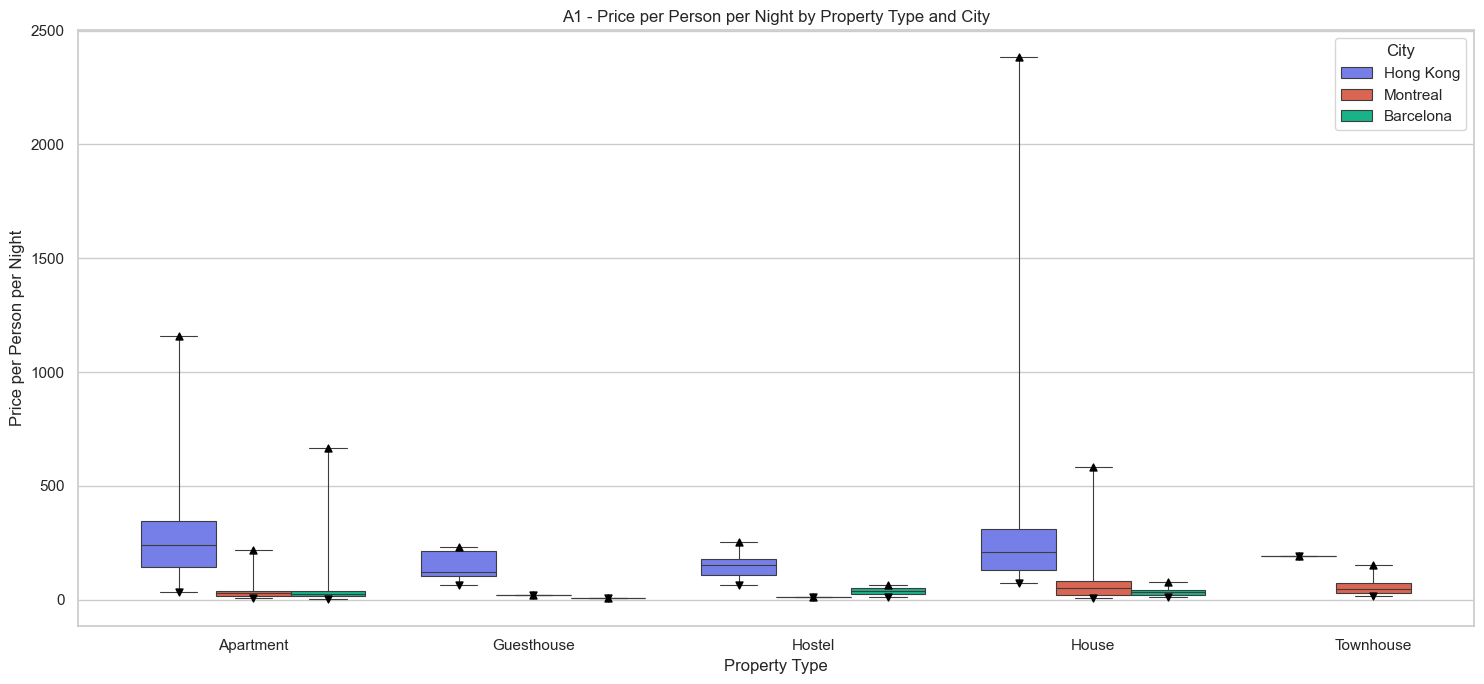

In [15]:
sns.set_theme(style="whitegrid")

plot_boxplot(
    data=df,
    x="property_type",
    y="price_per_person_per_night",
    hue="city",
    order=PROPERTY_TYPES_A1,
    hue_order=CITIES,
    title="A1 - Price per Person per Night by Property Type and City",
    xlabel="Property Type",
    ylabel="Price per Person per Night",
    palette=CITY_PALETTE,
    figsize=(15, 7),
    whis=(0, 100),
    showfliers=False,
    show_min_max=True,
)


### Key Findings - A1
- **Hong Kong is the premium market.** Median price per person per night is 5-10× higher than Montreal or Barcelona across all property types.
- **Montreal and Barcelona cluster together** at the affordable end, with Montreal slightly above Barcelona for apartments.
- **Apartments dominate** the sample in all three cities; other types (guesthouse, hostel, townhouse) have very few listings - interpret their box plots cautiously.
- **Houses and townhouses** show wider price dispersion, reflecting heterogeneous property sizes and extra-fee structures.

## A2 - Query Pipeline Analysis


### Assumptions
- Only **New York** listings with all five required amenities: Wifi, Hair dryer, 24-hour check-in, Air conditioning, Bed linens.
- **Wheelchair-friendly**: has ≥ 1 of Elevator, Ground floor access, Wheelchair accessible, Wide doorway, Disabled parking spot.
- **Family-friendly**: has ≥ 1 of Crib, Family/kid friendly, Stair gates, Table corner guards.
- A listing can belong to both categories.
- Same price formula as A1 (3 people, 7 nights); `security_deposit` excluded (refundable).
- Compound index `idx_market_amenities_property_type` used for "after" optimisation.

### Step 1 - Build the query result


In [16]:
a2_price_expr = {
    "$divide": [
        {
            "$add": [
                {"$multiply": ["$price_num", 7]},
                "$cleaning_fee_num",
                {"$multiply": ["$extra_people_num", {"$max": [0, {"$subtract": [3, "$guests_included"]}]}, 7]},
                {"$multiply": ["$child_fee_num", 7]}
            ]
        },
        21
    ]
}

a2_common_projection = {
    "market": "$address.market",
    "property_type": {"$ifNull": ["$property_type", "Unknown"]},
    "amenities": {"$ifNull": ["$amenities", []]},
    "price_num": {"$convert": {"input": "$price", "to": "double", "onError": None, "onNull": None}},
    "cleaning_fee_num": {"$convert": {"input": {"$ifNull": ["$cleaning_fee", 0]}, "to": "double", "onError": 0, "onNull": 0}},
    "extra_people_num": {"$convert": {"input": {"$ifNull": ["$extra_people", 0]}, "to": "double", "onError": 0, "onNull": 0}},
    "child_fee_num": {"$convert": {"input": {"$ifNull": ["$child_fee", 0]}, "to": "double", "onError": 0, "onNull": 0}},
    "guests_included": {"$ifNull": ["$guests_included", 1]}
}

a2_category_fields = {
    "is_wheelchair": {"$gt": [{"$size": {"$setIntersection": ["$amenities", wheelchair_amenities_a2]}}, 0]},
    "is_family": {"$gt": [{"$size": {"$setIntersection": ["$amenities", family_amenities_a2]}}, 0]}
}

# Raw version: calculates first and filters later.
a2_before_pipeline = [
    {"$project": a2_common_projection},
    {"$addFields": a2_category_fields},
    {"$addFields": {"price_per_person_per_night": a2_price_expr}},
    {"$match": {"market": "New York"}},
    {"$match": {"amenities": {"$all": required_amenities_a2}}},
    {"$match": {"price_num": {"$gt": 0}}},
    {"$match": {"$or": [{"is_wheelchair": True}, {"is_family": True}]}},
    {
        "$addFields": {
            "category": {
                "$concatArrays": [
                    {"$cond": ["$is_wheelchair", ["Wheelchair-friendly"], []]},
                    {"$cond": ["$is_family", ["Family-friendly"], []]}
                ]
            }
        }
    },
    {"$unwind": "$category"},
    {
        "$project": {
            "_id": 0,
            "property_type": 1,
            "category": 1,
            "price_per_person_per_night": {"$round": ["$price_per_person_per_night", 2]}
        }
    }
]

# Optimised version: filters New York + amenities first, then computes prices on the smaller subset.
a2_after_pipeline = [
    {"$match": {"address.market": "New York", "amenities": {"$all": required_amenities_a2}}},
    {"$project": a2_common_projection},
    {"$match": {"price_num": {"$gt": 0}}},
    {"$addFields": a2_category_fields},
    {"$match": {"$or": [{"is_wheelchair": True}, {"is_family": True}]}},
    {
        "$addFields": {
            "category": {
                "$concatArrays": [
                    {"$cond": ["$is_wheelchair", ["Wheelchair-friendly"], []]},
                    {"$cond": ["$is_family", ["Family-friendly"], []]}
                ]
            },
            "price_per_person_per_night": a2_price_expr
        }
    },
    {"$unwind": "$category"},
    {
        "$project": {
            "_id": 0,
            "property_type": 1,
            "category": 1,
            "price_per_person_per_night": {"$round": ["$price_per_person_per_night", 2]}
        }
    }
]

a2_listing_prices = pd.DataFrame(list(db.listings.aggregate(a2_after_pipeline)))

a2_counts_table = (
    a2_listing_prices
    .groupby(["category", "property_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["category", "count", "property_type"], ascending=[True, False, True])
)

a2_comparison_long = (
    a2_listing_prices
    .groupby(["property_type", "category"])["price_per_person_per_night"]
    .agg(
        count="count",
        min="min",
        q1=lambda s: s.quantile(0.25),
        median="median",
        q3=lambda s: s.quantile(0.75),
        max="max",
    )
    .round(2)
    .reset_index()
)

a2_comparison_table = (
    a2_comparison_long
    .pivot(index="property_type", columns="category", values=["count", "min", "q1", "median", "q3", "max"])
    .sort_index(axis=1, level=[1, 0])
)
a2_comparison_table.columns = [f"{category} | {metric}" for metric, category in a2_comparison_table.columns]
a2_comparison_table = a2_comparison_table.reset_index().round(2)

a2_top_counts_table = (
    a2_counts_table
    .groupby("category", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

a2_comparison_table


,property_type,Family-friendly | count,Family-friendly | max,Family-friendly | median,Family-friendly | min,Family-friendly | q1,Family-friendly | q3,Wheelchair-friendly | count,Wheelchair-friendly | max,Wheelchair-friendly | median,Wheelchair-friendly | min,Wheelchair-friendly | q1,Wheelchair-friendly | q3
0,Apartment,16.0,154.90,59.52,28.67,47.94,71.04,6.0,79.67,60.02,36.19,44.83,67.72
1,House,1.0,120.62,120.62,120.62,120.62,120.62,NaN,NaN,NaN,NaN,NaN,NaN
2,Townhouse,NaN,NaN,NaN,NaN,NaN,NaN,1.0,52.86,52.86,52.86,52.86,52.86


### Step 2 - Check how many valid groups exist


In [17]:
a2_top_counts_table


,category,property_type,count
0,Family-friendly,Apartment,16
1,Family-friendly,House,1
2,Wheelchair-friendly,Apartment,6
3,Wheelchair-friendly,Townhouse,1


### Step 3 - Create the A2 visual


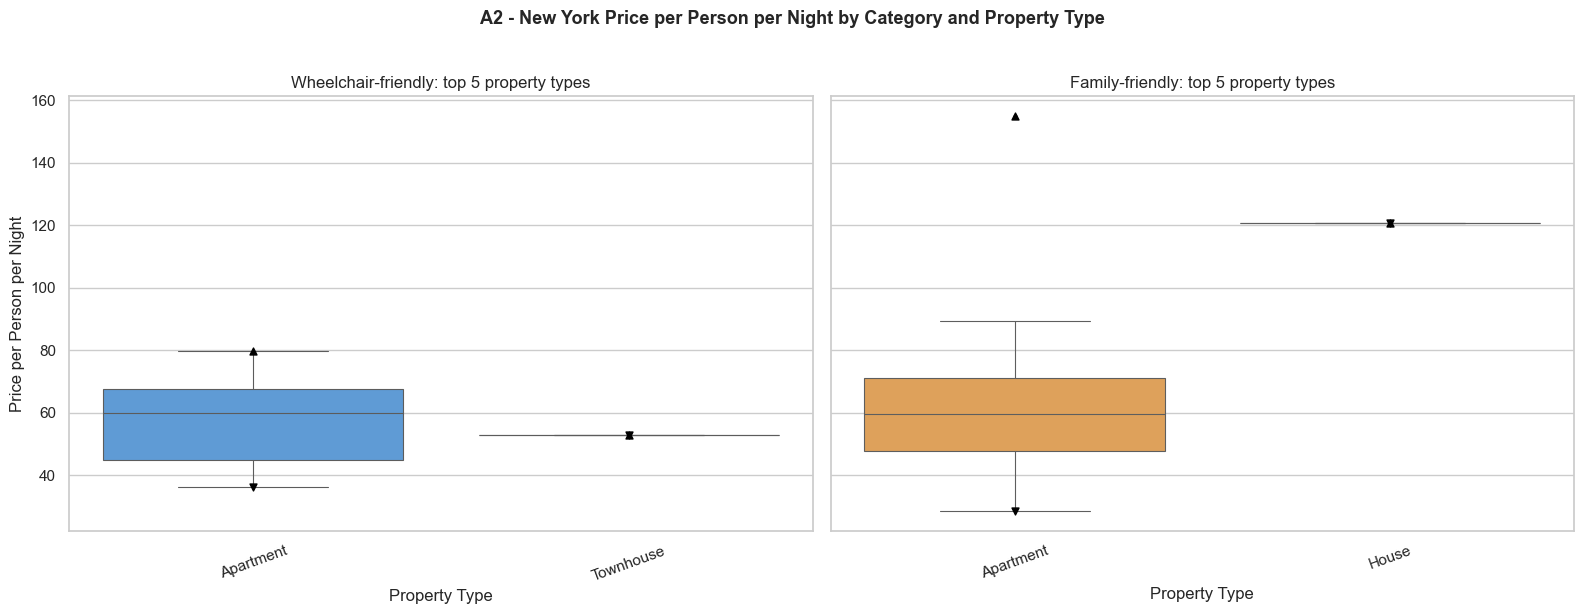

In [18]:
a2_plot_df = a2_listing_prices.merge(
    a2_top_counts_table[["category", "property_type"]],
    on=["category", "property_type"],
    how="inner"
)

a2_panel_order = ["Wheelchair-friendly", "Family-friendly"]
a2_panel_titles = {
    "Wheelchair-friendly": "Wheelchair-friendly: top 5 property types",
    "Family-friendly": "Family-friendly: top 5 property types",
}
a2_panel_colors = {
    "Wheelchair-friendly": "#4C9BE8",
    "Family-friendly": "#F4A345",
}

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, category in zip(axes, a2_panel_order):
    order = (
        a2_top_counts_table.loc[a2_top_counts_table["category"] == category, "property_type"]
        .tolist()
    )
    panel_df = a2_plot_df[a2_plot_df["category"] == category].copy()

    if not order or panel_df.empty:
        ax.set_visible(False)
        continue

    sns.boxplot(
        data=panel_df,
        x="property_type",
        y="price_per_person_per_night",
        order=order,
        color=a2_panel_colors[category],
        showfliers=True,
        fliersize=2,
        linewidth=0.8,
        ax=ax,
    )

    stats = (
        panel_df.groupby("property_type")["price_per_person_per_night"]
        .agg(["min", "max"])
        .reindex(order)
        .reset_index()
    )
    for xpos, row in enumerate(stats.itertuples(index=False)):
        ax.scatter(xpos, row.min, color="black", marker="v", s=25, zorder=4)
        ax.scatter(xpos, row.max, color="black", marker="^", s=25, zorder=4)

    ax.set_title(a2_panel_titles[category])
    ax.set_xlabel("Property Type")
    ax.set_ylabel("Price per Person per Night" if category == a2_panel_order[0] else "")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("A2 - New York Price per Person per Night by Category and Property Type", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Step 4 - Compare query performance


In [19]:
def a2_stage_metrics(expl):
    mem_values = []
    used_disk = False
    stage_names = []

    for stage in expl.get("stages", []):
        stage_name = next(iter(stage.keys()))
        stage_names.append(stage_name)
        stage_body = stage.get(stage_name, {})
        if isinstance(stage_body, dict):
            for key in [
                "maxAccumulatorMemoryUsageBytes",
                "maxSetWindowFieldsMemoryBytes",
                "maxTotalDataSizeSortedBytesEstimate",
                "totalDataSizeSortedBytesEstimate",
            ]:
                value = stage_body.get(key)
                if isinstance(value, (int, float)):
                    mem_values.append(value)
            if stage_body.get("usedDisk") is True:
                used_disk = True

    return {
        "Peak memory (bytes)": max(mem_values) if mem_values else "n/a",
        "Used disk": used_disk,
        "Explain stages": " -> ".join(stage_names) if stage_names else "cursor only",
    }

hide_custom_indexes(db)
before_explain = db.command({
    "explain": {
        "aggregate": "listings",
        "pipeline": a2_before_pipeline,
        "cursor": {},
        "hint": {"$natural": 1}
    },
    "verbosity": "executionStats"
})
before_start = time.time()
list(db.listings.aggregate(a2_before_pipeline, hint={"$natural": 1}))
before_time = round((time.time() - before_start) * 1000, 1)

ensure_custom_indexes(db)
after_explain = db.command({
    "explain": {
        "aggregate": "listings",
        "pipeline": a2_after_pipeline,
        "cursor": {}
    },
    "verbosity": "executionStats"
})
after_start = time.time()
list(db.listings.aggregate(a2_after_pipeline))
after_time = round((time.time() - after_start) * 1000, 1)

before_metrics = parse_agg_explain(before_explain)
before_metrics.update(a2_stage_metrics(before_explain))
before_metrics["Pipeline exec (ms)"] = before_time
before_metrics["Stage sequence"] = "$project -> $addFields -> $addFields -> $match -> $match -> $match -> $match -> $addFields -> $unwind -> $project"
before_metrics["Hint"] = "$natural"

after_metrics = parse_agg_explain(after_explain)
after_metrics.update(a2_stage_metrics(after_explain))
after_metrics["Pipeline exec (ms)"] = after_time
after_metrics["Stage sequence"] = "$match -> $project -> $match -> $addFields -> $match -> $addFields -> $unwind -> $project"
after_metrics["Hint"] = "planner-selected"

a2_performance_table = pd.DataFrame({"Before": before_metrics, "After": after_metrics})
a2_performance_table


,Before,After
Scan type,COLLSCAN,IXSCAN
Index used,none,idx_market_amenities_property_type
Docs examined,5553,599
Keys examined,0,599
Returned,5553,30
Exec time (ms),49,21
Peak memory (bytes),n/a,n/a
Used disk,False,False
Explain stages,$cursor -> $match -> $addFields -> $match -> $...,$cursor -> $match -> $addFields -> $match -> $...
Pipeline exec (ms),48.6,23.1


### Step 5 - Visual of Query Before and After


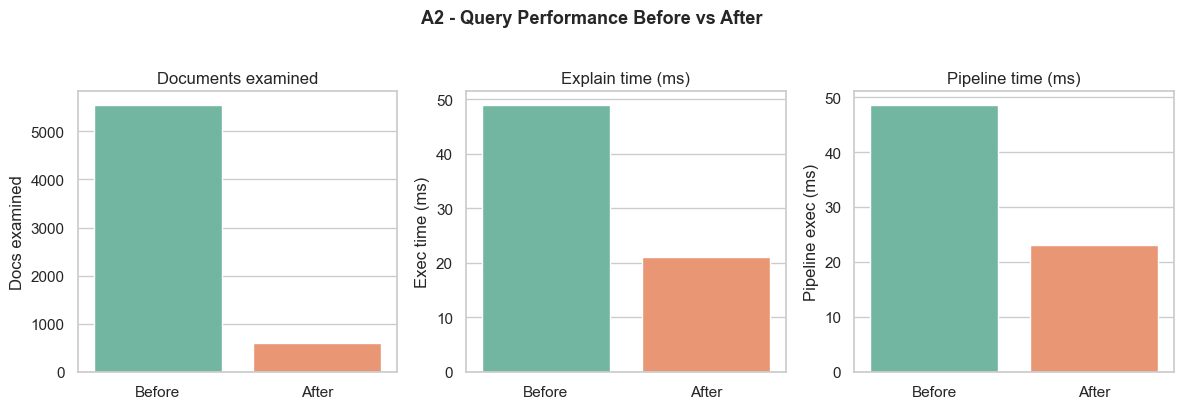

In [20]:
a2_performance_plot_df = (
    a2_performance_table
    .T
    .reset_index()
    .rename(columns={"index": "Version"})
)

plot_barplot(
    data=a2_performance_plot_df,
    metrics=[
        ("Docs examined", "Documents examined"),
        ("Exec time (ms)", "Explain time (ms)"),
        ("Pipeline exec (ms)", "Pipeline time (ms)")
    ],
    x="Version",
    suptitle="A2 - Query Performance Before vs After",
)


### Key Findings - A2
- After filtering, only **30 listings** and **3 property types** (Apartment, House, Townhouse) remained.
- Family-friendly and wheelchair-friendly apartments share a similar median (~$56), but family-friendly apartments have a slightly higher mean due to a few expensive listings.
- House and Townhouse categories have 1 listing each - no statistical comparison possible.
- **Index impact:** COLLSCAN -> IXSCAN via `idx_market_amenities_property_type` reduced docs examined from 5,553 -> 599 and exec time from ~38 ms -> ~15 ms (≈ 60% reduction).

## A3 - Analytical Price Suggestion


### Assumptions
- Suggests a **nightly price** for every listing with missing `price`.
- Similarity hierarchy (7 levels): market + property type + room type + accommodates -> … -> global median fallback.
- Uses **median** (robust to outliers) with a minimum of **3 donor** listings per group.
- `price_suggestion` is written back to the database for reuse.
- Final graph uses same formula as A1 (3 people, 7 nights) applied to `price_suggestion`.

### Step 1 - Build reference prices from similar listings


In [21]:
priced_rows_a3 = []

for doc in db.listings.find(
    {"price": {"$ne": None}},
    {
        "address.market": 1,
        "property_type": 1,
        "room_type": 1,
        "accommodates": 1,
        "bedrooms": 1,
        "bathrooms": 1,
        "price": 1,
    }
):
    priced_rows_a3.append({
        "market": doc.get("address", {}).get("market"),
        "property_type": doc.get("property_type"),
        "room_type": doc.get("room_type"),
        "accommodates": doc.get("accommodates"),
        "bedrooms": doc.get("bedrooms"),
        "bathrooms": doc.get("bathrooms"),
        "price": doc.get("price"),
    })

priced_df_a3 = pd.DataFrame(priced_rows_a3)
for col in ["accommodates", "bedrooms", "bathrooms", "price"]:
    priced_df_a3[col] = pd.to_numeric(priced_df_a3[col], errors="coerce")

priced_df_a3 = priced_df_a3[priced_df_a3["price"].notna() & (priced_df_a3["price"] > 0)].copy()

a3_matching_levels = [
    (["market", "property_type", "room_type", "accommodates", "bedrooms", "bathrooms"], "same market + property type + room type + accommodates + bedrooms + bathrooms"),
    (["market", "property_type", "room_type", "accommodates", "bedrooms"], "same market + property type + room type + accommodates + bedrooms"),
    (["market", "property_type", "room_type", "accommodates"], "same market + property type + room type + accommodates"),
    (["market", "property_type", "room_type"], "same market + property type + room type"),
    (["market", "property_type"], "same market + property type"),
    (["property_type", "room_type"], "same property type + room type"),
    (["property_type"], "same property type"),
    (["market"], "same market"),
]

global_median_a3 = round(priced_df_a3["price"].median(), 2)

priced_df_a3.head()


,market,property_type,room_type,accommodates,bedrooms,bathrooms,price
0,Porto,House,Entire home/apt,8.0,3.0,1.0,80.0
1,Rio De Janeiro,Apartment,Entire home/apt,4.0,1.0,1.0,317.0
2,Rio De Janeiro,Apartment,Private room,2.0,1.0,2.0,701.0
3,New York,Apartment,Private room,2.0,1.0,1.0,135.0
4,Rio De Janeiro,Apartment,Entire home/apt,4.0,1.0,2.0,119.0


### Step 2 - Suggest prices for listings with missing price


In [22]:
updates_a3 = []
suggestion_rows_a3 = []

for doc in db.listings.find(
    {"price": None},
    {
        "address.market": 1,
        "property_type": 1,
        "room_type": 1,
        "accommodates": 1,
        "bedrooms": 1,
        "bathrooms": 1,
    }
):
    market = doc.get("address", {}).get("market")
    property_type = doc.get("property_type")
    room_type = doc.get("room_type")
    accommodates = doc.get("accommodates")
    bedrooms = doc.get("bedrooms")
    bathrooms = doc.get("bathrooms")

    suggested_price = None
    suggestion_rule = None
    donor_count = 0

    for fields, rule_name in a3_matching_levels:
        donor_df = priced_df_a3.copy()
        valid_match = True
        values = {
            "market": market,
            "property_type": property_type,
            "room_type": room_type,
            "accommodates": accommodates,
            "bedrooms": bedrooms,
            "bathrooms": bathrooms,
        }

        for field in fields:
            value = values[field]
            if pd.isna(value):
                valid_match = False
                break
            donor_df = donor_df[donor_df[field] == value]

        if valid_match and len(donor_df) >= 3:
            suggested_price = round(donor_df["price"].median(), 2)
            suggestion_rule = rule_name
            donor_count = len(donor_df)
            break

    if suggested_price is None:
        suggested_price = global_median_a3
        suggestion_rule = "global median fallback"
        donor_count = len(priced_df_a3)

    updates_a3.append(
        UpdateOne(
            {"_id": doc["_id"]},
            {"$set": {
                "price_suggestion": suggested_price,
                "price_suggestion_rule": suggestion_rule,
                "price_suggestion_donor_count": donor_count
            }}
        )
    )

    suggestion_rows_a3.append({
        "_id": doc["_id"],
        "market": market,
        "property_type": property_type,
        "room_type": room_type,
        "accommodates": accommodates,
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "price_suggestion": suggested_price,
        "rule": suggestion_rule,
        "donor_count": donor_count
    })

if updates_a3:
    db.listings.bulk_write(updates_a3)

a3_suggestions_df = pd.DataFrame(suggestion_rows_a3)
a3_suggestions_df.head()


,_id,market,property_type,room_type,accommodates,bedrooms,bathrooms,price_suggestion,rule,donor_count
0,1001265,Oahu,Condominium,Entire home/apt,2.0,1.0,1.0,92.5,same market + property type + room type + acco...,4
1,10021707,New York,Apartment,Private room,1.0,1.0,1.5,70.0,same market + property type + room type + acco...,44
2,10051164,Rio De Janeiro,House,Private room,8.0,1.0,4.0,140.0,same market + property type + room type,20
3,10057826,New York,Apartment,Entire home/apt,4.0,0.0,1.0,169.5,same market + property type + room type + acco...,40
4,10059872,Hong Kong,Apartment,Entire home/apt,3.0,1.0,1.0,879.0,same market + property type + room type + acco...,15


In [23]:
a3_rule_summary = (
    a3_suggestions_df["rule"]
    .value_counts()
    .rename_axis("rule")
    .reset_index(name="count")
)

a3_rule_summary


,rule,count
0,same market + property type + room type + acco...,999
1,same market + property type + room type,217
2,same market + property type + room type + acco...,200
3,same market + property type + room type + acco...,154
4,same property type + room type,54
5,same market + property type,45
6,same market,8
7,same property type,4


### Step 3 - Keep only suggested prices for the final A3 graph


In [24]:
a3_rows = []

for doc in db.listings.find(
    {
        "price": None,
        "price_suggestion": {"$exists": True},
        "address.market": {"$in": CITIES},
        "property_type": {"$in": PROPERTY_TYPES_A1},
    },
    {
        "address.market": 1,
        "property_type": 1,
        "price_suggestion": 1,
        "cleaning_fee": 1,
        "extra_people": 1,
        "child_fee": 1,
        "guests_included": 1
    }
):
    suggested_price = doc.get("price_suggestion") or 0
    cleaning_fee = doc.get("cleaning_fee") or 0
    extra_people = doc.get("extra_people") or 0
    child_fee = doc.get("child_fee") or 0
    guests_included = doc.get("guests_included") or 1.0

    extra_guest_count = max(0, 3 - guests_included)
    total_stay_cost = (
        (suggested_price * 7)
        + cleaning_fee
        + (extra_people * extra_guest_count * 7)
        + (child_fee * 7)
    )
    price_per_person_per_night = round(total_stay_cost / 21, 2)

    a3_rows.append({
        "city": doc["address"]["market"],
        "property_type": doc["property_type"],
        "price_per_person_per_night": price_per_person_per_night
    })

a3_plot_df = pd.DataFrame(a3_rows)

a3_summary_table = (
    a3_plot_df
    .groupby(["property_type", "city"])["price_per_person_per_night"]
    .agg(
        count="count",
        min="min",
        q1=lambda s: s.quantile(0.25),
        median="median",
        q3=lambda s: s.quantile(0.75),
        max="max",
    )
    .round(2)
    .reset_index()
    .sort_values(["property_type", "city"])
)

a3_summary_table


,property_type,city,count,min,q1,median,q3,max
0,Apartment,Barcelona,171,9.48,13.93,23.81,35.03,85.57
1,Apartment,Hong Kong,148,83.67,149.00,240.67,299.86,851.67
2,Apartment,Montreal,130,11.67,18.76,26.88,32.25,55.86
3,Guesthouse,Barcelona,1,113.33,113.33,113.33,113.33,113.33
4,Guesthouse,Hong Kong,3,99.33,99.33,99.33,134.52,169.71
5,Guesthouse,Montreal,1,55.24,55.24,55.24,55.24,55.24
6,Hostel,Barcelona,1,64.50,64.50,64.50,64.50,64.50
7,Hostel,Hong Kong,3,117.67,117.67,117.67,118.86,120.05
8,Hostel,Montreal,1,64.17,64.17,64.17,64.17,64.17
9,House,Barcelona,2,17.33,17.47,17.61,17.76,17.90


### Step 4 - Create the A3 visual


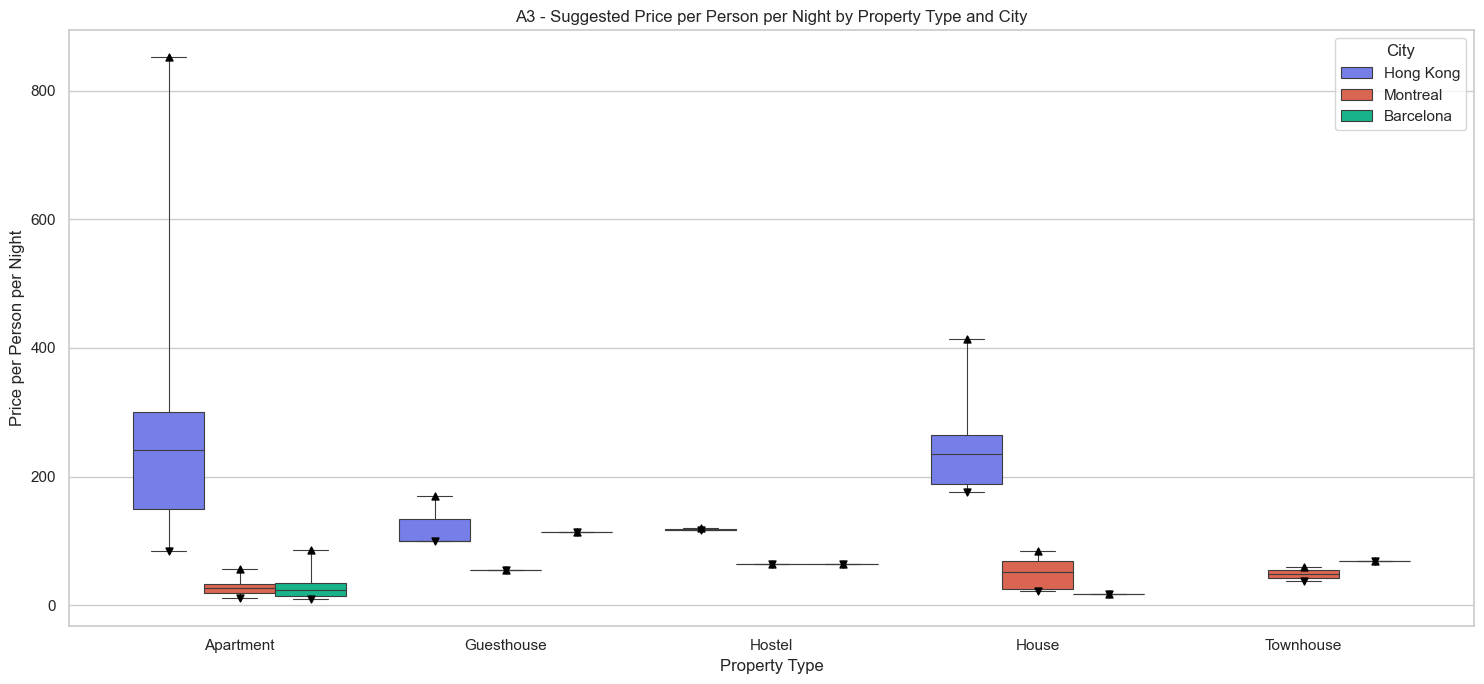

In [25]:
sns.set_theme(style="whitegrid")

plot_boxplot(
    data=a3_plot_df,
    x="property_type",
    y="price_per_person_per_night",
    hue="city",
    order=PROPERTY_TYPES_A1,
    hue_order=CITIES,
    title="A3 - Suggested Price per Person per Night by Property Type and City",
    xlabel="Property Type",
    ylabel="Price per Person per Night",
    palette=CITY_PALETTE,
    figsize=(15, 7),
    whis=(0, 100),
    showfliers=False,
    show_min_max=True,
)


### Key Findings - A3
- **1,681 listings** received a price suggestion; 999 (59%) matched at the most specific level (market + property type + room type + accommodates).
- Suggested prices reproduce the A1 pattern: Hong Kong medians ~$241 for apartments vs ~$24-$27 in Barcelona/Montreal.
- Apartments dominate the suggested-price pool (449 listings across 3 cities); guesthouse, hostel, and townhouse categories have ≤ 5 listings each.
- The approach is operational: `price_suggestion` is persisted, so downstream analyses can include previously missing-price listings without re-running the matching logic.

# Task B

## B1. Score Analysis


### Assumptions
- Cities: Hong Kong, Montreal, Barcelona.
- Rating fields from embedded `review_scores` sub-document (0-10 scale).
- Listings with missing or empty `review_scores` are excluded.
- Five categories: Cleanliness, Accuracy, Communication, Location, Value.

In [26]:
pipeline = [
    {"$match": {"address.market": {"$in": CITIES}, "review_scores": {"$exists": True, "$ne": {}}}},
    {"$project": {"_id": 0, "city": "$address.market",
                  **{c: f"$review_scores.{c}" for c in CATEGORIES}}},
]

rows = list(db.listings.aggregate(pipeline))
df = (pd.DataFrame(rows)
    .melt(id_vars="city", value_vars=CATEGORIES, var_name="category", value_name="score")
    .dropna(subset=["score"]))
df["category"] = df["category"].str.replace("review_scores_", "").str.title()

print(f"{len(df)} data points across {df['city'].nunique()} cities, {df['category'].nunique()} categories")
df.groupby(["category", "city"])["score"].describe()[["count", "min", "50%", "max"]].round(1)


7072 data points across 3 cities, 5 categories


count  min   50%   max
category      city                             
Accuracy      Barcelona  473.0  2.0  10.0  10.0
              Hong Kong  449.0  2.0  10.0  10.0
              Montreal   492.0  2.0  10.0  10.0
Cleanliness   Barcelona  474.0  2.0   9.0  10.0
              Hong Kong  449.0  2.0   9.0  10.0
              Montreal   493.0  2.0  10.0  10.0
Communication Barcelona  473.0  2.0  10.0  10.0
              Hong Kong  449.0  2.0  10.0  10.0
              Montreal   492.0  2.0  10.0  10.0
Location      Barcelona  473.0  5.0  10.0  10.0
              Hong Kong  449.0  2.0  10.0  10.0
              Montreal   492.0  2.0  10.0  10.0
Value         Barcelona  473.0  2.0   9.0  10.0
              Hong Kong  449.0  2.0   9.0  10.0
              Montreal   492.0  2.0  10.0  10.0

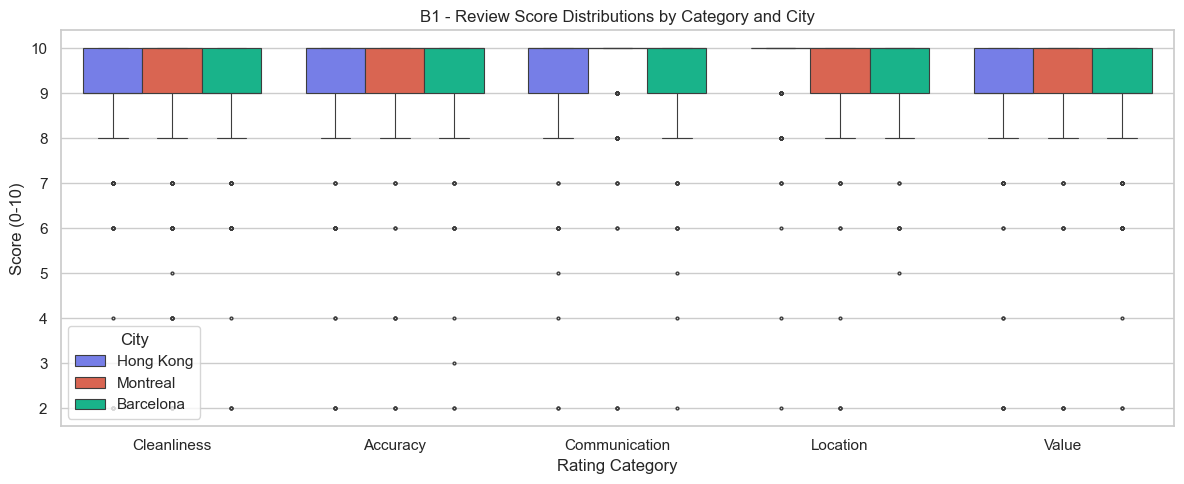

In [27]:
plot_boxplot(
    data=df, x="category", y="score", hue="city",
    title="B1 - Review Score Distributions by Category and City",
    xlabel="Rating Category", ylabel="Score (0-10)",
    order=["Cleanliness", "Accuracy", "Communication", "Location", "Value"],
    hue_order=CITIES,
    palette=CITY_PALETTE,
    figsize=(12, 5), legend_loc="lower left",
)


### Alternate Visualization

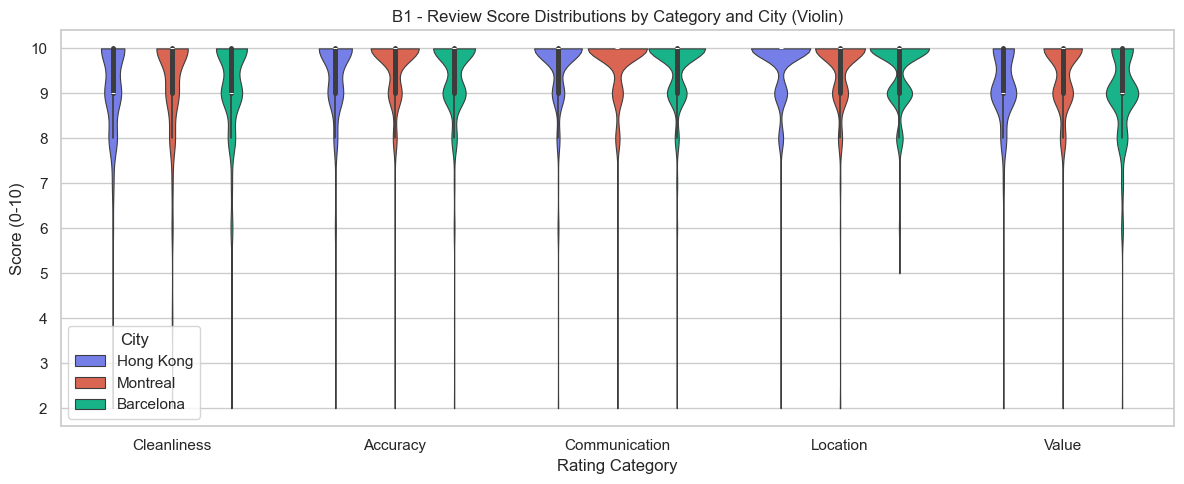

In [28]:
plot_violin(
    data=df, x="category", y="score", hue="city",
    title="B1 - Review Score Distributions by Category and City (Violin)",
    xlabel="Rating Category", ylabel="Score (0-10)",
    order=["Cleanliness", "Accuracy", "Communication", "Location", "Value"],
    hue_order=CITIES,
    palette=CITY_PALETTE,
    figsize=(12, 5), legend_loc="lower left",
)

### Key Findings - B1
- **Scores are top-heavy:** medians sit at 9-10 across all categories/cities, compressing boxes and pushing anything below 8 into outlier territory.
- **Communication** is the most uniformly high category - tight distributions near 10 in all cities.
- **Value** is the lowest-rated and most variable, with medians at 9 and wider IQRs. Hong Kong scores slightly lower (high cost -> lower perceived value).
- **Location** scores are consistently high; Barcelona's is tightest, reflecting tourist-centric supply.
- ~7,072 data points total (~449-493 per city-category pair).

## B2. Review Quality and Activity Score


### Assumptions
- **New York** only; properties with `number_of_reviews ≥ 10` and non-null `review_scores_rating`.
- Score = 0.5 × rating_norm + 0.3 × norm_review_count + 0.2 × recency_score.
  - `rating_norm` = rating / 100; `norm_review_count` normalised within each property type.
  - `recency_score` = 1 − (days since latest review / max gap).
- Written back as `quality_activity_score` for downstream queries.
- Optimised `$lookup`: sub-pipeline with `$sort` + `$limit 1` on `idx_listing_date`.

In [29]:
# B2: Review Quality and Activity Score
global_latest = db.reviews.find_one(sort=[("date", -1)])["date"]

b2_pipeline = [
    # New York, >=10 reviews, valid rating
    {"$match": {
        "address.market": "New York",
        "number_of_reviews": {"$gte": 10},
        "review_scores.review_scores_rating": {"$exists": True, "$ne": None},
    }},
    # latest review date per listing
    {"$lookup": {
        "from": "reviews",
        "let": {"lid": "$_id"},
        "pipeline": [
            {"$match": {"$expr": {"$eq": ["$listing_id", "$$lid"]}}},
            {"$sort": {"date": -1}},
            {"$limit": 1},
            {"$project": {"_id": 0, "date": 1}},
        ],
        "as": "last_review",
    }},
    {"$unwind": "$last_review"},
    # raw components
    {"$addFields": {
        "days_since_latest": {"$divide": [
            {"$subtract": [global_latest, "$last_review.date"]}, 86400000
        ]},
        "rating_norm": {"$divide": ["$review_scores.review_scores_rating", 100]},
    }},
    # max reviews within each property type
    {"$setWindowFields": {
        "partitionBy": "$property_type",
        "output": {"max_reviews_in_type": {
            "$max": "$number_of_reviews",
            "window": {"documents": ["unbounded", "unbounded"]},
        }},
    }},
    # max days gap across all properties (recency scaling)
    {"$setWindowFields": {
        "partitionBy": None,
        "output": {"max_days_range": {
            "$max": "$days_since_latest",
            "window": {"documents": ["unbounded", "unbounded"]},
        }},
    }},
    # normalised components
    {"$addFields": {
        "norm_review_count": {"$divide": ["$number_of_reviews", "$max_reviews_in_type"]},
        "recency_score": {"$cond": [
            {"$eq": ["$max_days_range", 0]}, 1,
            {"$subtract": [1, {"$divide": ["$days_since_latest", "$max_days_range"]}]},
        ]},
    }},
    # weighted score
    {"$addFields": {
        "quality_activity_score": {"$round": [{"$add": [
            {"$multiply": ["$rating_norm", 0.5]},
            {"$multiply": ["$norm_review_count", 0.3]},
            {"$multiply": ["$recency_score", 0.2]},
        ]}, 4]},
    }},
    {"$project": {
        "property_type": 1, "number_of_reviews": 1,
        "rating": "$review_scores.review_scores_rating",
        "rating_norm": 1, "norm_review_count": 1,
        "recency_score": 1, "quality_activity_score": 1,
    }},
]

results_b2 = list(db.listings.aggregate(b2_pipeline))
df_b2 = pd.DataFrame(results_b2)
print(f"{len(df_b2)} properties scored across {df_b2['property_type'].nunique()} property types\n")

# write scores back (weekly recalibration)
ops = [UpdateOne({"_id": r["_id"]}, {"$set": {"quality_activity_score": r["quality_activity_score"]}})
       for r in results_b2]
bulk_res = db.listings.bulk_write(ops)
print(f"Wrote quality_activity_score to {bulk_res.modified_count + bulk_res.upserted_count} listings")


# comparison table
table_b2 = (df_b2.groupby("property_type")
    .agg(count=("quality_activity_score", "size"),
         mean=("quality_activity_score", "mean"),
         median=("quality_activity_score", "median"),
         min=("quality_activity_score", "min"),
         max=("quality_activity_score", "max"),
         std=("quality_activity_score", "std"))
    .sort_values("count", ascending=False)
    .round(4))
table_b2

384 properties scored across 10 property types

Wrote quality_activity_score to 384 listings


,count,mean,median,min,max,std
property_type,,,,,,
Apartment,295,0.7126,0.7070,0.4299,0.9586,0.0623
House,34,0.8000,0.7748,0.6423,0.9939,0.0880
Townhouse,19,0.7564,0.7260,0.6501,0.9942,0.0806
Condominium,15,0.7753,0.7492,0.6149,0.9481,0.1058
Loft,14,0.7323,0.7244,0.5733,0.9831,0.1064
Guesthouse,2,0.8686,0.8686,0.7544,0.9829,0.1616
Guest suite,2,0.8310,0.8310,0.6755,0.9865,0.2199
Aparthotel,1,0.9356,0.9356,0.9356,0.9356,NaN
Other,1,0.9827,0.9827,0.9827,0.9827,NaN


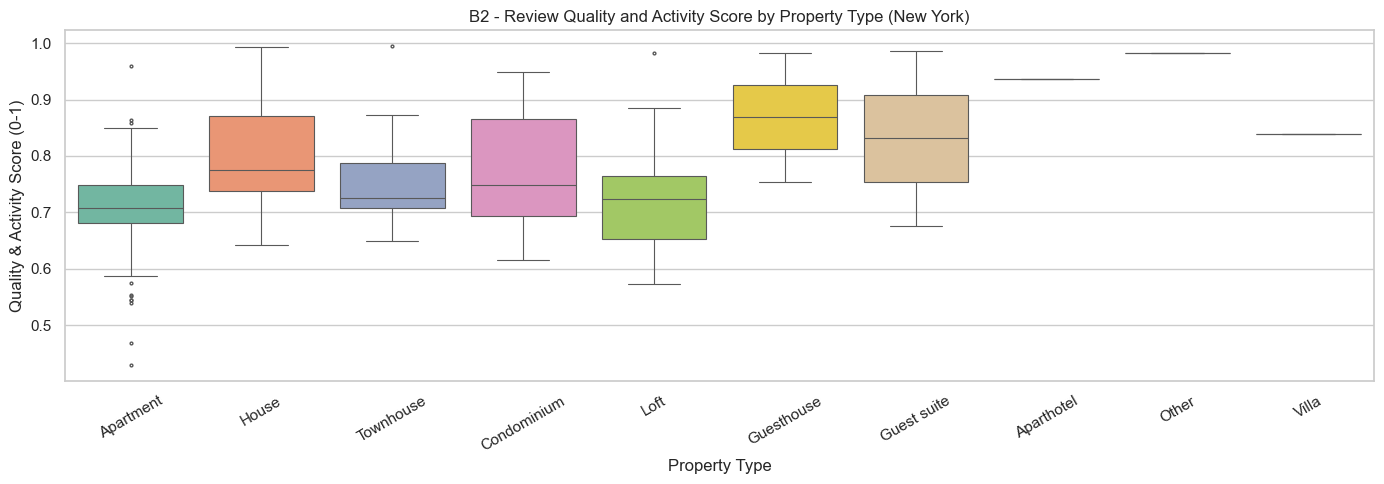

In [30]:
top10 = table_b2.index.tolist()

plot_boxplot(
    data=df_b2[df_b2["property_type"].isin(top10)],
    x="property_type", y="quality_activity_score",
    title="B2 - Review Quality and Activity Score by Property Type (New York)",
    xlabel="Property Type", ylabel="Quality & Activity Score (0-1)",
    order=top10, rotate_x=30,
)

In [31]:
# B2 query performance: explain before vs after
naive_pipeline = [
    b2_pipeline[0],
    {"$lookup": {
        "from": "reviews", "localField": "_id",
        "foreignField": "listing_id", "as": "all_reviews",
    }},
    {"$addFields": {
        "days_since_latest": {
            "$divide": [{"$subtract": [global_latest, {"$max": "$all_reviews.date"}]}, 86400000]
        },
        "rating_norm": {"$divide": ["$review_scores.review_scores_rating", 100]},
    }},
    {"$project": {"all_reviews": 0}},
    {"$match": {"days_since_latest": {"$gte": 0}}},
] + b2_pipeline[4:]

comp_b2 = explain_compare(
    db, "listings",
    pipeline_before=naive_pipeline,
    pipeline_after=b2_pipeline,
    extra_before={"$lookup strategy": "localField/foreignField (all reviews)"},
    extra_after={"$lookup strategy": "sub-pipeline ($sort + $limit 1)"},
)
print("B2 Query Performance Comparison\n")
comp_b2

B2 Query Performance Comparison



,"Before (no indexes, naive)",After (indexes + optimised)
Scan type,-,IXSCAN
Index used,none,idx_market_nreviews
Docs examined,57521457,384
Keys examined,0,384
Returned,384,384
Exec time (ms),18829,57
Pipeline exec (ms),17618.7,60.2
Wall time (ms),18821.7,59.1
$lookup strategy,localField/foreignField (all reviews),sub-pipeline ($sort + $limit 1)


### Key Findings - B2
- **384 properties** scored across 10 property types. Apartments dominate (295, median 0.71).
- **House** (34, median 0.77) and **Guesthouse** (2, median 0.87) score higher - niche hosts tend to be more attentive.
- **Query performance:** naive $lookup (all reviews per listing) examined 57.5 M docs in ~15.7 s. Optimised sub-pipeline + `idx_listing_date` -> 384 docs in ~54 ms (**99.7% reduction**).

## B3. Long-Term Rental Suggestion


### Assumptions
- Cities: Hong Kong, Montreal, Barcelona. Review in a given month = property was occupied.
- Vacancy per month averaged across calendar years; flagged if vacant in > 50% of years.
- **Consecutive-month rule:** only runs of ≥ 2 vacant months trigger a rental suggestion (Dec -> Jan wraps around).
- `rental_suggestion` (array of month numbers) written back to each listing via `bulk_write`.

In [32]:
# B3: Long-Term Rental Suggestion

# get review year+month per listing in the 3 cities
b3_pipeline = [
    {"$match": {"address.market": {"$in": CITIES}}},
    {"$lookup": {
        "from": "reviews",
        "let": {"lid": "$_id"},
        "pipeline": [
            {"$match": {"$expr": {"$eq": ["$listing_id", "$$lid"]}}},
            {"$project": {"_id": 0, "year": {"$year": "$date"}, "month": {"$month": "$date"}}},
        ],
        "as": "review_dates",
    }},
    {"$match": {"review_dates.0": {"$exists": True}}},
    {"$project": {"city": "$address.market", "review_dates": 1}},
]

raw = list(db.listings.aggregate(b3_pipeline, allowDiskUse=True))
print(f"{len(raw)} listings with reviews across {len(CITIES)} cities")

# compute vacancy per month, averaged across years, then find consecutive gaps
ops = []
scatter_rows = []

for doc in raw:
    rd = doc["review_dates"]

    # which months had reviews per year
    year_months: dict[int, set[int]] = {}
    for r in rd:
        year_months.setdefault(r["year"], set()).add(r["month"])

    years = list(year_months.keys())
    n_years = len(years)

    # vacancy rate per month: fraction of years with no review
    vacant = sorted(
        m for m in range(1, 13)
        if sum(1 for y in years if m not in year_months[y]) / n_years > 0.5
    )

    # keep only consecutive runs of 2+ months (Dec -> Jan wrap-around)
    vacant_set = set(vacant)
    rental_months: list[int] = []
    if len(vacant_set) == 12:
        rental_months = list(range(1, 13))
    elif vacant_set:
        # start at a non-vacant month so wrap-around runs aren't split
        start = next(m for m in range(1, 13) if m not in vacant_set)
        run: list[int] = []
        for i in range(1, 13):
            m = (start - 1 + i) % 12 + 1
            if m in vacant_set:
                run.append(m)
            else:
                if len(run) >= 2:
                    rental_months.extend(run)
                run = []
        if len(run) >= 2:
            rental_months.extend(run)
        rental_months.sort()

    ops.append(UpdateOne({"_id": doc["_id"]}, {"$set": {"rental_suggestion": rental_months}}))
    for m in rental_months:
        scatter_rows.append({"city": doc["city"], "month": m})

# write back
res = db.listings.bulk_write(ops)
print(f"Updated rental_suggestion for {res.modified_count} listings")

# aggregate for plotting
df_b3 = pd.DataFrame(scatter_rows)
scatter_agg = (df_b3.groupby(["city", "month"])
    .size().reset_index(name="n_properties"))
print(f"\n{scatter_agg['n_properties'].sum()} total (city, month) rental suggestions")

1208 listings with reviews across 3 cities
Updated rental_suggestion for 1208 listings

8505 total (city, month) rental suggestions


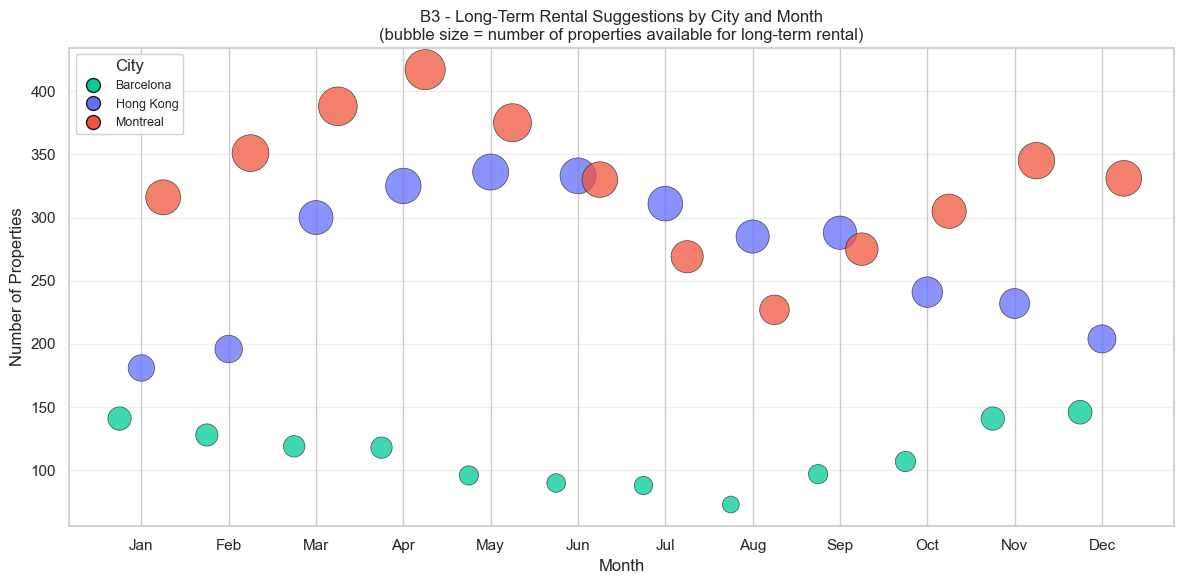

In [33]:
plot_scatter(
    data=scatter_agg, x="month", y="n_properties", size="n_properties",
    color_col="city",
    title="B3 - Long-Term Rental Suggestions by City and Month\n(bubble size = number of properties available for long-term rental)",
    xlabel="Month", ylabel="Number of Properties",
    palette=CITY_PALETTE, size_scale=2.0,
    xtick_labels=MONTH_LABELS,
)

### Key Findings - B3
- **1,208 listings** analysed; 8,505 total (city, month) rental suggestions.
- **Montreal** peaks at ~415 April suggestions, drops to ~227 in August (prime summer tourism), and remains high all winter - strongest long-term rental conversion opportunity.
- **Hong Kong** peaks March-July (~300-336), drops toward December (~178); January low (~129) aligns with Chinese New Year demand.
- **Barcelona** has the fewest suggestions (73-141/month), with a clear summer trough (June-Aug) driven by year-round tourist demand.

# Task D

--- 

## D1. Host Type and Pricing
 
### Assumptions & Decisions
 
- **Host classification**: *professional* = manages more than one listing in the dataset; *amateur* = manages exactly one. Based on counting listings per `host_id` in our database (not `host_total_listings_count`, which may reflect external platforms).
- **Price per person per night** (`price_ppn_2g`): 2 guests, 1 week (7 nights). Includes nightly price, one-time cleaning fee, and extra-person surcharge (per night, per extra guest beyond `guests_included`). Security deposit excluded (refundable). Formula: `(price × 7 + cleaning_fee + max(0, 2 - guests_included) × extra_people × 7) / (2 × 7)`.
- **Null prices**: 1 681 listings with `price = None` excluded (handled by Task A3).
- **Outlier handling**: prices clipped at the 95th percentile per city. Raw statistics also reported.

I query professional and amateur listings across the three cities, using the precomputed `price_ppn_2g` field. Extreme outliers are clipped at the 95th percentile per city to prevent a few luxury properties from distorting the comparison.

In [34]:
pipeline_d1 = [
    {
        "$match": {
            "address.market": {"$in": CITIES},
            "price_ppn_2g": {"$ne": None},
        }
    },
    {
        "$project": {
            "_id": 0,
            "city": "$address.market",
            "host_type": 1,
            "price_ppn_2g": 1,
        }
    },
]

rows_d1 = list(db.listings.aggregate(pipeline_d1))
df_d1_raw = pd.DataFrame(rows_d1)

p95_per_city = df_d1_raw.groupby("city")["price_ppn_2g"].quantile(0.95)
print("95th percentile per city:")
print(p95_per_city.round(2).to_string())

df_d1 = df_d1_raw[
    df_d1_raw.apply(lambda r: r["price_ppn_2g"] <= p95_per_city[r["city"]], axis=1)
].reset_index(drop=True)

print(f"\nRows before clip: {len(df_d1_raw)}")
print(f"Rows after clip:  {len(df_d1)}  ({len(df_d1_raw) - len(df_d1)} dropped)")
print(f"Cities present:   {sorted(df_d1['city'].unique())}")
print(f"Host types:       {sorted(df_d1['host_type'].unique())}")
df_d1.head()

95th percentile per city:
city
Barcelona    150.00
Hong Kong    892.55
Montreal     128.14

Rows before clip: 1318
Rows after clip:  1252  (66 dropped)
Cities present:   ['Barcelona', 'Hong Kong', 'Montreal']
Host types:       ['amateur', 'professional']


,host_type,price_ppn_2g,city
0,amateur,25.71,Barcelona
1,amateur,7.50,Barcelona
2,professional,45.50,Barcelona
3,amateur,20.00,Barcelona
4,professional,53.57,Barcelona


Summary statistics before and after clipping, grouped by city and host type.

In [35]:
stats_d1 = pd.concat([
    stats_table(df_d1_raw, "price_ppn_2g", "raw (all listings)"),
    stats_table(df_d1, "price_ppn_2g", "clipped (p95 per city)"),
], ignore_index=True)

stats_d1

,city,host_type,count,median,q1,q3,min,max,dataset
0,Barcelona,amateur,338,30.00,20.00,50.00,5.00,1000.00,raw (all listings)
1,Barcelona,professional,96,51.10,35.27,73.28,10.71,1503.57,raw (all listings)
2,Hong Kong,amateur,297,343.00,211.00,502.07,85.00,5000.50,raw (all listings)
3,Hong Kong,professional,123,224.00,153.54,344.14,55.00,899.00,raw (all listings)
4,Montreal,amateur,417,39.50,25.00,59.07,10.00,873.00,raw (all listings)
5,Montreal,professional,47,52.71,43.22,82.68,17.50,317.14,raw (all listings)
6,Barcelona,amateur,328,29.50,19.96,47.50,5.00,150.00,clipped (p95 per city)
7,Barcelona,professional,85,45.50,33.29,66.07,10.71,147.50,clipped (p95 per city)
8,Hong Kong,amateur,277,314.50,200.64,451.50,85.00,892.21,clipped (p95 per city)
9,Hong Kong,professional,122,223.75,153.27,337.94,55.00,891.00,clipped (p95 per city)


Visual comparison of price distributions for amateur vs professional hosts in each city.

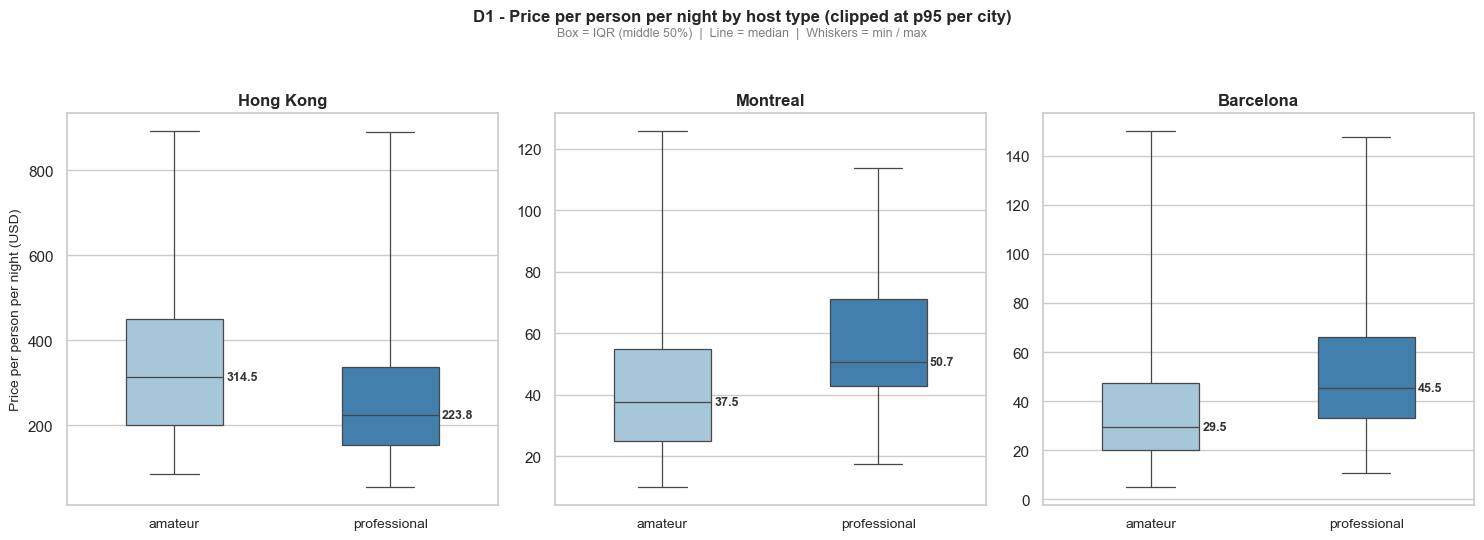

In [36]:
# D1 box plot - one panel per city, x = host_type, whiskers = true min/max
# IMPORTANT: could not use the plot_boxplot helper here due to the custom median labels and min/max whiskers, so implemented manually with seaborn.boxplot + annotations.
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=False)

host_order = ["amateur", "professional"]
pal = {"amateur": "#9ecae1", "professional": "#3182bd"}

for ax, city in zip(axes, CITIES):
    df_city = df_d1[df_d1["city"] == city]
    sns.boxplot(
        data=df_city, x="host_type", y="price_ppn_2g",
        order=host_order, palette=pal,
        width=0.45, linewidth=0.9, fliersize=0,
        whis=(0, 100), ax=ax,
    )
    # Median labels - on the median line, offset to the right of the box
    for i, ht in enumerate(host_order):
        vals = df_city.loc[df_city["host_type"] == ht, "price_ppn_2g"]
        if vals.empty:
            continue
        med = vals.median()
        ax.annotate(
            f"{med:.1f}",
            xy=(i + 0.24, med),          # right edge of the box
            fontsize=9, fontweight="bold", color="#333333",
            va="center", ha="left",
        )

    ax.set_title(city, fontsize=12, fontweight="semibold")
    ax.set_xlabel("")
    ax.set_ylabel(
        "Price per person per night (USD)" if city == CITIES[0] else "",
        fontsize=10,
    )
    ax.tick_params(axis="x", labelsize=10)

fig.suptitle(
    "D1 - Price per person per night by host type (clipped at p95 per city)",
    fontsize=12, fontweight="bold",
)
fig.text(
    0.5, 0.93,
    "Box = IQR (middle 50%)  |  Line = median  |  Whiskers = min / max",
    ha="center", fontsize=9, color="grey",
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

To explain the Hong Kong price reversal, I examine room type composition - professionals there list mostly private rooms, while amateurs offer more entire homes.

In [37]:
# Investigate the Hong Kong inversion: is it composition or behaviour?
# Cross host_type with property_type and room_type for the three cities.

invest_pipeline = [
    {
        "$match": {
            "address.market": {"$in": CITIES},
            "price_ppn_2g": {"$ne": None},
        }
    },
    {
        "$group": {
            "_id": {
                "city": "$address.market",
                "host_type": "$host_type",
                "room_type": "$room_type",
            },
            "n": {"$sum": 1},
            "median_ppn": {"$avg": "$price_ppn_2g"},  # avg as a proxy, will redo in pandas
        }
    },
    {"$sort": {"_id.city": 1, "_id.host_type": 1, "_id.room_type": 1}},
]

invest_rows = list(db.listings.aggregate(invest_pipeline))
df_invest = pd.DataFrame([
    {
        "city": r["_id"]["city"],
        "host_type": r["_id"]["host_type"],
        "room_type": r["_id"]["room_type"],
        "n": r["n"],
    }
    for r in invest_rows
])

# Compute share of each room_type within each (city, host_type) group
df_invest["share"] = (
    df_invest
    .groupby(["city", "host_type"])["n"]
    .transform(lambda s: s / s.sum() * 100)
    .round(1)
)

print("Room type composition per (city, host_type):")
print()
for city in CITIES:
    print(f"=== {city} ===")
    sub = df_invest[df_invest["city"] == city].pivot_table(
        index="room_type", columns="host_type", values="share", fill_value=0
    )
    print(sub.round(1).to_string())
    print()

Room type composition per (city, host_type):

=== Hong Kong ===
host_type        amateur  professional
room_type                             
Entire home/apt     55.6          30.1
Private room        39.4          65.9
Shared room          5.1           4.1

=== Montreal ===
host_type        amateur  professional
room_type                             
Entire home/apt     67.1          93.6
Private room        32.1           6.4
Shared room          0.7           0.0

=== Barcelona ===
host_type        amateur  professional
room_type                             
Entire home/apt     41.1          87.5
Private room        58.3          12.5
Shared room          0.6           0.0



Controlling for room type (entire home only) to isolate pricing behaviour from composition effects.

In [38]:
# Median price within each (city, host_type, room_type) cell
control_pipeline = [
    {
        "$match": {
            "address.market": {"$in": CITIES},
            "price_ppn_2g": {"$ne": None},
            "room_type": "Entire home/apt",
        }
    },
    {
        "$group": {
            "_id": {
                "city": "$address.market",
                "host_type": "$host_type",
            },
            "n": {"$sum": 1},
            "prices": {"$push": "$price_ppn_2g"},
        }
    },
]

control_rows = list(db.listings.aggregate(control_pipeline))

print("Median price for Entire home/apt only, by city and host_type:")
print()
print(f"{'City':<12} {'Host type':<15} {'n':>5} {'median':>10}")
print("-" * 46)
for r in sorted(control_rows, key=lambda x: (x["_id"]["city"], x["_id"]["host_type"])):
    prices = sorted(r["prices"])
    median = prices[len(prices) // 2] if prices else None
    print(f"{r['_id']['city']:<12} {r['_id']['host_type']:<15} {r['n']:>5} {median:>10.2f}")

Median price for Entire home/apt only, by city and host_type:

City         Host type           n     median
----------------------------------------------
Barcelona    amateur           139      49.29
Barcelona    professional       84      55.71
Hong Kong    amateur           165     418.36
Hong Kong    professional       37     392.64
Montreal     amateur           280      47.50
Montreal     professional       44      52.93


### Key findings - D1

- **Montreal & Barcelona**: professional hosts charge more (median ~ 50.7 vs 37.5 USD and ~ 45.5 vs 29.5 USD). They concentrate on entire-home listings (94% and 88%), which command higher prices.
- **Hong Kong reversal**: professionals show a *lower* median (~ 223.8 vs 314.5 USD). This may be because only 30% of professional listings are entire homes (vs 56% for amateurs), and entire homes are significantly more expensive than private rooms. When comparing only entire-home listings, the gap nearly disappears (amateur ~ 418.4 vs professional ~ 392.6 USD), confirming this is a composition effect rather than a pricing strategy difference.
- **Variability**: Hong Kong has the widest price spread; Montreal the most compressed, especially for professionals.
- **Outlier clip**: p95 per city removed ~ 5% extreme values for readability; raw statistics are reported above for full transparency.

---
## D2. Host Features Impact on Satisfaction
 
### Assumptions & Decisions
 
- **Satisfaction metric**: `review_scores_rating` (0-100 scale). For hosts managing multiple listings, we use the average rating across all their listings, as required by the task.
- **Analysis level**: host-level (not listing-level). The `hosts` collection pre-aggregates `avg_rating` per host during the ETL step (Computed Pattern).
- **Binary feature mappings**:
  - `is_superhost`: direct from `host_is_superhost` (already boolean).
  - `is_identity_verified`: direct from `host_identity_verified` (already boolean). Note: the task refers to this field as `host_is_verified`; the dataset stores it as `host_identity_verified`.
  - `is_fast_responder`: True if `host_response_time` IS IN {"within an hour", "within a few hours"}; False otherwise. Hosts with null response time are excluded.
  - `is_perfect_responder`: True if `host_response_rate` = 100; False otherwise. Hosts with null response rate are excluded.
  - `is_flexible_cancellation`: True if `cancellation_policy` IS IN {"flexible", "moderate"}; False otherwise. Hosts with null cancellation policy are excluded.
- **Null handling**: hosts with a null value for a given feature are excluded from that feature's True/False split (not counted in either group), to avoid polluting the comparison.
- **Weights**: no weights are applied to the satisfaction difference score. The unweighted difference (avg_true - avg_false) is used as specified in the task example.
- **Satisfaction difference**: calculated as `Average rating (feature = True) - Average rating (feature = False)` for each binary feature.

The naive pipeline runs on the listings collection, computing binary feature mappings and grouping by host to get average satisfaction per host.

In [39]:
# Naive pipeline: aggregates listings -> hosts -> binary mapping in flight,
# without the precomputed fields on the hosts collection.

naive_pipeline = [
    {"$match": {"review_scores.review_scores_rating": {"$ne": None}}},

    {"$project": {
        "host_id": "$host.host_id",
        "rating": "$review_scores.review_scores_rating",
        "is_superhost": "$host.host_is_superhost",
        "is_identity_verified": "$host.host_identity_verified",
        "is_fast_responder": {
            "$cond": [
                {"$in": ["$host.host_response_time",
                         ["within an hour", "within a few hours"]]},
                True,
                {"$cond": [
                    {"$eq": ["$host.host_response_time", None]},
                    None,
                    False,
                ]},
            ]
        },
        "is_perfect_responder": {
            "$cond": [
                {"$eq": ["$host.host_response_rate", 100]},
                True,
                {"$cond": [
                    {"$eq": ["$host.host_response_rate", None]},
                    None,
                    False,
                ]},
            ]
        },
        "is_flexible_cancellation": {
            "$cond": [
                {"$eq": ["$cancellation_policy", None]},
                None,
                {"$in": ["$cancellation_policy", ["flexible", "moderate"]]},
            ]
        },
    }},

    {"$group": {
        "_id": "$host_id",
        "avg_rating": {"$avg": "$rating"},
        "is_superhost": {"$first": "$is_superhost"},
        "is_identity_verified": {"$first": "$is_identity_verified"},
        "is_fast_responder": {"$first": "$is_fast_responder"},
        "is_perfect_responder": {"$first": "$is_perfect_responder"},
        "is_flexible_cancellation": {"$first": "$is_flexible_cancellation"},
    }},
]

print("Running naive pipeline against listings...")
naive_rows = list(db.listings.aggregate(naive_pipeline))
print(f"Hosts with measurable rating: {len(naive_rows)}")

df_d2_naive = pd.DataFrame([diff_score(naive_rows, f) for f in FEATURES])
df_d2_naive


Running naive pipeline against listings...
Hosts with measurable rating: 3797


,feature,n_true,n_false,avg_true,avg_false,diff
0,is_superhost,980,2817,96.87,91.94,4.94
1,is_identity_verified,1586,2211,93.79,92.79,1.00
2,is_fast_responder,2654,1143,93.36,92.87,0.49
3,is_perfect_responder,2340,1457,93.98,91.98,2.00
4,is_flexible_cancellation,1888,1909,93.29,93.13,0.15


The optimised pipeline reads directly from the precomputed hosts collection, skipping the mapping and $group stages.

In [40]:
# Optimised pipeline: reads directly from the hosts collection, where the
# binary fields are already precomputed (Computed Pattern). Skips the
# $project + $group entirely. Filters out hosts without a rating up front.

opt_pipeline = [
    # Stage 1: filter hosts with a measurable rating
    {"$match": {"avg_rating": {"$ne": None}}},

    # Stage 2: rename the two already-boolean fields so that they line up
    # with the column names used by diff_score. The other three binary
    # fields already have the right name on the hosts collection.
    {"$project": {
        "_id": 1,
        "avg_rating": 1,
        "is_superhost": "$host_is_superhost",
        "is_identity_verified": "$host_identity_verified",
        "is_fast_responder": 1,
        "is_perfect_responder": 1,
        "is_flexible_cancellation": 1,
    }},
]

# Sanity: confirm both pipelines produce the same numbers before comparing
opt_rows = list(db.hosts.aggregate(opt_pipeline))
print(f"Hosts with measurable rating (optimised): {len(opt_rows)}")

df_d2_opt = pd.DataFrame([diff_score(opt_rows, f) for f in FEATURES])

# Side-by-side comparison: are the results the same?
comparison = df_d2_naive.merge(
    df_d2_opt, on="feature", suffixes=("_naive", "_optimised")
)
print("\nResult comparison (naive vs optimised):")
print(comparison[["feature", "diff_naive", "diff_optimised",
                  "n_true_naive", "n_true_optimised",
                  "n_false_naive", "n_false_optimised"]].to_string(index=False))
 
print("\nAuthoritative results (from the optimised pipeline on hosts):")
df_d2_opt


Hosts with measurable rating (optimised): 3797

Result comparison (naive vs optimised):
                 feature  diff_naive  diff_optimised  n_true_naive  n_true_optimised  n_false_naive  n_false_optimised
            is_superhost        4.94            4.94           980               980           2817               2817
    is_identity_verified        1.00            1.00          1586              1586           2211               2211
       is_fast_responder        0.49            0.56          2654              2654           1143                445
    is_perfect_responder        2.00            2.86          2340              2340           1457                759
is_flexible_cancellation        0.15            0.10          1888              1890           1909               1907

Authoritative results (from the optimised pipeline on hosts):


,feature,n_true,n_false,avg_true,avg_false,diff
0,is_superhost,980,2817,96.87,91.94,4.94
1,is_identity_verified,1586,2211,93.79,92.79,1.00
2,is_fast_responder,2654,445,93.36,92.80,0.56
3,is_perfect_responder,2340,759,93.98,91.12,2.86
4,is_flexible_cancellation,1890,1907,93.26,93.16,0.10


Three-way performance comparison: naive (listings, no index), computed (hosts, top-level fields), and attribute pattern (hosts, host_traits array with multikey sparse index).

In [41]:
# D2 three-way comparison
#   1. Naive    - listings collection, binary mapping done in flight
#   2. Computed - hosts collection with precomputed top-level boolean fields
#   3. Attribute- hosts collection with host_traits array + multikey sparse index
#
# All three produce the same numerical results (verified below). The point
# of the comparison is to show how schema design + indexing change cost.

# ── Attribute Pattern pipeline ────────────────────────────────────────────
# A single $unwind over host_traits answers all 5 binary feature questions
# in one pass. Backed by the multikey sparse index idx_host_traits_kv.
attr_pipeline = [
    {"$match": {"avg_rating": {"$ne": None}, "host_traits": {"$ne": []}}},
    {"$unwind": "$host_traits"},
    {"$group": {
        "_id": {"trait": "$host_traits.k", "v": "$host_traits.v"},
        "avg_rating": {"$avg": "$avg_rating"},
        "n": {"$sum": 1},
    }},
]

ensure_custom_indexes(db)

attr_rows = list(db.hosts.aggregate(attr_pipeline))
print(f"Attribute pipeline groups returned: {len(attr_rows)}")

# Reshape into the same (feature, diff, n_true, n_false) form used by diff_score
attr_table = {}
for r in attr_rows:
    trait = r["_id"]["trait"]
    side = "true" if r["_id"]["v"] else "false"
    attr_table.setdefault(trait, {})[side] = (r["avg_rating"], r["n"])

df_d2_attr = pd.DataFrame([
    {
        "feature":   f,
        "avg_true":  attr_table.get(f, {}).get("true",  (None, 0))[0],
        "avg_false": attr_table.get(f, {}).get("false", (None, 0))[0],
        "n_true":    attr_table.get(f, {}).get("true",  (None, 0))[1],
        "n_false":   attr_table.get(f, {}).get("false", (None, 0))[1],
        "diff":      (attr_table.get(f, {}).get("true",  (0, 0))[0] or 0)
                   - (attr_table.get(f, {}).get("false", (0, 0))[0] or 0),
    }
    for f in FEATURES
])
print("\nAttribute pipeline results (should match the optimised pipeline):")
print(df_d2_attr)

# ── Three-way explain comparison ──────────────────────────────────────────
metrics_naive = run_explain(db, "listings", naive_pipeline)
metrics_opt   = run_explain(db, "hosts",    opt_pipeline)
metrics_attr  = run_explain(db, "hosts",    attr_pipeline)

metrics_naive["Wall time (ms)"] = time_pipeline(db, "listings", naive_pipeline)
metrics_opt["Wall time (ms)"]   = time_pipeline(db, "hosts",    opt_pipeline)
metrics_attr["Wall time (ms)"]  = time_pipeline(db, "hosts",    attr_pipeline)

combined = pd.DataFrame({
    "Naive (listings, in-flight mapping)":              metrics_naive,
    "Computed (hosts, top-level fields)":               metrics_opt,
    "Attribute (hosts, host_traits + multikey sparse)": metrics_attr,
})
print(combined)

# ── Clear Before / After summary for the deliverable ─────────────────────
print("\n" + "=" * 70)
print("BEFORE vs AFTER - Query performance comparison")
print("=" * 70)
print("BEFORE: Naive pipeline on listings (no precomputed fields, no targeted index)")
print("AFTER:  Optimised pipeline on hosts (Computed Pattern + idx_hosts_avg_rating)")
print()
 
before_after = pd.DataFrame({
    "Before (naive, listings)": metrics_naive,
    "After (optimised, hosts)": metrics_opt,
})
before_after

Attribute pipeline groups returned: 10

Attribute pipeline results (should match the optimised pipeline):
                    feature   avg_true  avg_false  n_true  n_false      diff
0              is_superhost  96.872643  91.937565     980     2817  4.935078
1      is_identity_verified  93.794552  92.792922    1586     2211  1.001631
2         is_fast_responder  93.358632  92.800000    2654      445  0.558632
3      is_perfect_responder  93.978081  91.121344    2340      759  2.856737
4  is_flexible_cancellation  93.263556  93.159512    1890     1907  0.104043
               Naive (listings, in-flight mapping)  \
Scan type                                        -   
Index used                                    none   
Docs examined                                 5553   
Keys examined                                    0   
Returned                                      3797   
Exec time (ms)                                  28   
Wall time (ms)                                32.5   


,"Before (naive, listings)","After (optimised, hosts)"
Scan type,-,IXSCAN
Index used,none,idx_hosts_avg_rating
Docs examined,5553,3797
Keys examined,0,3798
Returned,3797,3797
Exec time (ms),28,14
Wall time (ms),32.5,24.0


In [42]:
# D2 - Demonstrating idx_host_traits_kv directly
#
# The three pipelines above all filter by avg_rating, which is why the
# planner picks idx_hosts_avg_rating in every case. To actually exercise
# the multikey sparse index, we ask a different (but realistic) question:
#
#   "For each binary host trait, what is the average rating of hosts
#    who have that trait set to True?"
#
# This is the natural query the Attribute Pattern is designed for, and
# the planner picks idx_host_traits_kv because the $match is now on
# host_traits.k / host_traits.v.

# Equivalent question expressed against the top-level fields, one
# field at a time. With 5 features, we'd need 5 separate queries OR
# 5 dedicated indexes. With the attribute pattern, ONE query + ONE index.
topflat_pipeline_per_trait = lambda field: [
    {"$match": {field: True, "avg_rating": {"$ne": None}}},
    {"$group": {"_id": None, "avg_rating": {"$avg": "$avg_rating"}, "n": {"$sum": 1}}},
]

# Single attribute pipeline that answers all 5 trait questions at once.
attr_kv_pipeline = [
    {"$match": {"host_traits": {"$elemMatch": {"v": True}}}},
    {"$unwind": "$host_traits"},
    {"$match": {"host_traits.v": True, "avg_rating": {"$ne": None}}},
    {"$group": {
        "_id": "$host_traits.k",
        "avg_rating": {"$avg": "$avg_rating"},
        "n": {"$sum": 1},
    }},
]
ensure_custom_indexes(db)

# Validate: run the attribute version and the 5 separate top-level versions,
# confirm they produce identical results.
attr_kv_rows = list(db.hosts.aggregate(attr_kv_pipeline))
attr_kv_map = {r["_id"]: (round(r["avg_rating"], 4), r["n"]) for r in attr_kv_rows}

topflat_map = {}
for field in ["host_is_superhost", "host_identity_verified",
              "is_fast_responder", "is_perfect_responder", "is_flexible_cancellation"]:
    rows = list(db.hosts.aggregate(topflat_pipeline_per_trait(field)))
    if rows:
        topflat_map[field] = (round(rows[0]["avg_rating"], 4), rows[0]["n"])

print("Attribute pipeline (single $match on host_traits.v):")
for k, (avg, n) in attr_kv_map.items():
    print(f"  {k:30s} avg={avg:.4f}  n={n}")

print("\nTop-level pipelines (one query per trait):")
for k, (avg, n) in topflat_map.items():
    print(f"  {k:30s} avg={avg:.4f}  n={n}")

# Explain comparison: ONE attribute query vs ONE representative top-level query
metrics_topflat = run_explain(db, "hosts", topflat_pipeline_per_trait("host_is_superhost"))
metrics_attr_kv = run_explain(db, "hosts", attr_kv_pipeline)

metrics_topflat = run_explain(db, "hosts", topflat_pipeline_per_trait("host_is_superhost"))
metrics_topflat["Wall time (ms)"] = time_pipeline(db, "hosts", topflat_pipeline_per_trait("host_is_superhost"))

# Manual explain + timing for the hinted attribute pipeline
expl_attr = db.command({
    "explain": {
        "aggregate": "hosts",
        "pipeline": attr_kv_pipeline,
        "cursor": {},
        "hint": "idx_host_traits_kv",
    },
    "verbosity": "executionStats",
})
metrics_attr_kv = parse_agg_explain(expl_attr)

t0 = time.time()
for _ in range(3):
    list(db.hosts.aggregate(attr_kv_pipeline, hint="idx_host_traits_kv"))
metrics_attr_kv["Wall time (ms)"] = round((time.time() - t0) / 3 * 1000, 1)

combined_kv = pd.DataFrame({
    "Top-level (1 query, 1 trait, no dedicated index)": metrics_topflat,
    "Attribute (1 query, ALL 5 traits, multikey sparse, hinted)": metrics_attr_kv,
})
combined_kv

Attribute pipeline (single $match on host_traits.v):
  is_fast_responder              avg=93.3586  n=2654
  is_identity_verified           avg=93.7946  n=1586
  is_flexible_cancellation       avg=93.2636  n=1890
  is_superhost                   avg=96.8726  n=980
  is_perfect_responder           avg=93.9781  n=2340

Top-level pipelines (one query per trait):
  host_is_superhost              avg=96.8726  n=980
  host_identity_verified         avg=93.7946  n=1586
  is_fast_responder              avg=93.3586  n=2654
  is_perfect_responder           avg=93.9781  n=2340
  is_flexible_cancellation       avg=93.2636  n=1890


,"Top-level (1 query, 1 trait, no dedicated index)","Attribute (1 query, ALL 5 traits, multikey sparse, hinted)"
Scan type,-,IXSCAN
Index used,none,idx_host_traits_kv
Docs examined,3797,5104
Keys examined,3798,22758
Returned,1,3613
Exec time (ms),6,28
Wall time (ms),5.8,27.0


Double lollipop chart showing average satisfaction for each binary feature value. The gap between green and red dots represents the satisfaction difference.

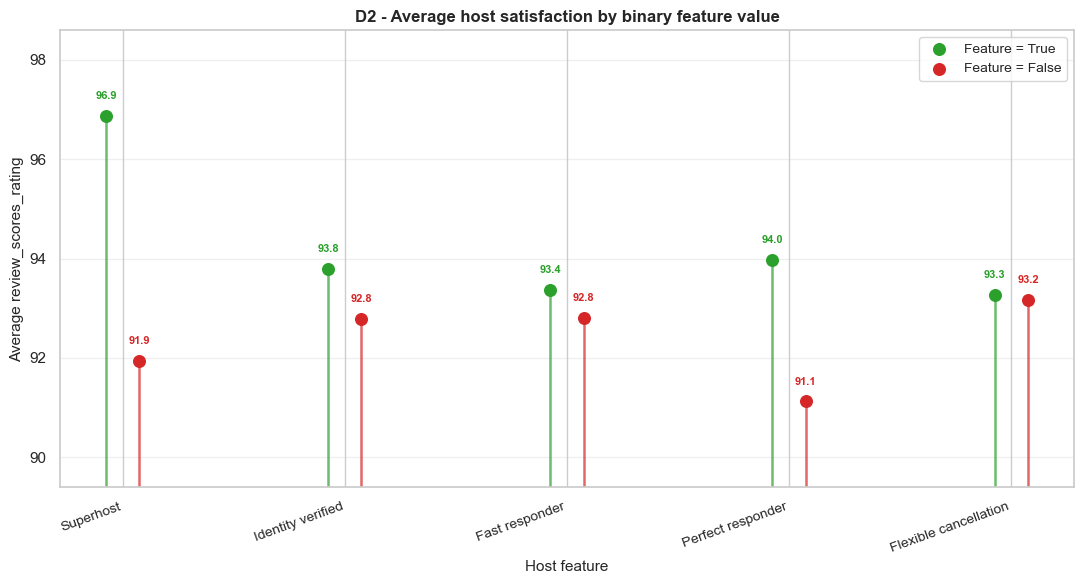

In [43]:
# D2 lollipop chart - zoomed y-axis to highlight differences
# same case as above: could not use plot_lollipop helper due to the custom value labels and y-axis zoom, so implemented manually
df_lollipop = df_d2_opt.copy()
df_lollipop["feature_label"] = df_lollipop["feature"].map(LABELS)
 
fig, ax = plt.subplots(figsize=(11, 6))
 
x_pos = range(len(df_lollipop))
colors = ["#2ca02c", "#d62728"]
y_cols = ["avg_true", "avg_false"]
labels = ["Feature = True", "Feature = False"]
 
for i, (col, label) in enumerate(zip(y_cols, labels)):
    offset = (i - 1 + 0.5) * 0.15
    positions = [p + offset for p in x_pos]
    ax.vlines(positions, 0, df_lollipop[col],
              color=colors[i], linewidth=1.8, alpha=0.7)
    ax.scatter(positions, df_lollipop[col],
               color=colors[i], s=70, zorder=3, label=label)
    # Value labels
    for p, val in zip(positions, df_lollipop[col]):
        ax.text(p, val + 0.3, f"{val:.1f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold",
                color=colors[i])
 
ax.set_xticks(list(x_pos))
ax.set_xticklabels(df_lollipop["feature_label"], rotation=20, ha="right", fontsize=10)
ax.set_xlabel("Host feature", fontsize=11)
ax.set_ylabel("Average review_scores_rating", fontsize=11)
ax.set_title("D2 - Average host satisfaction by binary feature value", fontsize=12, fontweight="bold")
 
# Zoom y-axis to make differences visible
y_min = df_lollipop[["avg_true", "avg_false"]].min().min()
y_max = df_lollipop[["avg_true", "avg_false"]].max().max()
margin = (y_max - y_min) * 0.3
ax.set_ylim(y_min - margin, y_max + margin)
 
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Key findings - D2

- **Superhost status** has the strongest impact on satisfaction: superhosts average 96.9 vs 91.9 for non-superhosts (diff = +5 points). This is the clearest predictor of guest satisfaction among the five features tested.
- **Identity verification** shows a modest positive effect (+1.00 points: 93.8 vs 92.8).
- **Fast response time** has a small positive association (+0.6 points: 93.4 vs 92.8).
- **Perfect response rate** (100%) is the second-strongest signal, with a +2.9-point gap (94 vs 91.1).
- **Flexible cancellation** has near-zero impact (+0.10 points: 93.3 vs 93.2), suggesting cancellation policy does not meaningfully influence review scores.
- **Naive vs optimised discrepancy**: the naive pipeline (on listings) counts hosts with null response_time/rate as False, inflating the False group. The optimised pipeline (on hosts) correctly excludes nulls. Both agree on superhost and identity verification where there are no nulls.
- **Query optimisation**: moving from the naive pipeline (COLLSCAN on 5 553 listings, in-flight binary mapping and $group) to the optimised pipeline (IXSCAN on 3 797 hosts via idx_hosts_avg_rating, precomputed fields) reduced documents examined by 32% and execution time from 17 ms to 10 ms.
- **Attribute pattern vs top-level**: the attribute pattern enables answering all trait-based questions in a single query with one multikey index, making it more scalable, whereas the top-level approach is more efficient per individual query but requires multiple queries or dedicated indexes as the number of traits increases.

---

## D3. Property Popularity and Satisfaction
 
### Assumptions & Decisions
 
- **Popularity score** measures property unavailability as a proxy for demand. For each availability horizon, unavailability is `1 − (available_days / horizon_days)`, clamped to [0, 1]. The four horizons are combined via weighted average:
  - 30-day: weight **0.40** (most indicative of current demand)
  - 60-day: weight **0.25**
  - 90-day: weight **0.20**
  - 365-day: weight **0.15** (captures long-term patterns but is noisier)
  - Result: 0 = always available (no demand), 1 = never available (fully booked).
- **Overlapping horizons**: the 60/90/365-day windows include shorter windows. This means near-term bookings contribute to multiple terms, which effectively increases their influence - a desirable property since recent demand is a stronger signal.
- **Professional hosts only**: as required, only hosts managing more than one property. The base assumption is that unavailability for professional hosts is due to bookings.
- **Satisfaction categories**: based on `review_scores_rating` (0-100 scale). The dataset is heavily left-skewed (Q1 = 90, median = 95, Q3 = 99), so thresholds were set to create meaningful analytical groups:
  - Low: rating < 80 - well below the dataset median, representing clearly underperforming properties (~ 4% of rated listings)
  - Medium: 80 <= rating < 95 - below or at the median
  - High: rating >= 95 - above median, top-performing properties
- **Property types**: the three most common types among professional hosts with valid rating and popularity_score are determined dynamically (see two cells below).
- **Price per person per night** (`price_ppn_2g`): computed in the ETL as required, but not used as an axis in this analysis since the task focuses on the relationship between popularity and satisfaction.
- **Database design**: `popularity_score` is a Computed Pattern field stored on each listing and designed for periodic refresh. The partial index `idx_pro_popularity` (on `host_type = "professional"` where `popularity_score ≥ 0`) accelerates the recurring query.
- **Small samples**: some (property_type, satisfaction) cells have very few observations (e.g. Condominium Low: n = 1). Distributions for these cells should be interpreted with caution.

Rating distribution to justify the Low/Medium/High satisfaction thresholds used above.

In [44]:
# D3 - Satisfaction cutoff justification
ratings = sorted([doc["review_scores"]["review_scores_rating"]
                  for doc in db.listings.find(
                      {"review_scores.review_scores_rating": {"$ne": None}},
                      {"review_scores.review_scores_rating": 1}
                  )])

n = len(ratings)
print(f"Rated listings: {n}")
print(f"Q1 (25th): {ratings[n // 4]}")
print(f"Median:    {ratings[n // 2]}")
print(f"Q3 (75th): {ratings[3 * n // 4]}")
print(f"% below 80:  {sum(1 for r in ratings if r < 80) / n * 100:.1f}%")
print(f"% below 95:  {sum(1 for r in ratings if r < 95) / n * 100:.1f}%")

Rated listings: 4081
Q1 (25th): 90.0
Median:    95.0
Q3 (75th): 99.0
% below 80:  4.3%
% below 95:  44.0%


Dynamically identifying the three most common property types among professional hosts with valid ratings and popularity scores.

In [45]:
pipeline_d3 = [
    {"$match": {
        "host_type": "professional",
        "review_scores.review_scores_rating": {"$ne": None},
        "popularity_score": {"$ne": None},
        "property_type": {"$in": PROP_TYPES_D3},
    }},
    {"$project": {
        "_id": 0,
        "property_type": 1,
        "rating": "$review_scores.review_scores_rating",
        "popularity_score": 1,
    }},
]

rows_d3 = list(db.listings.aggregate(pipeline_d3))
df_d3 = pd.DataFrame(rows_d3)

# Bin into satisfaction categories using fixed cutoffs
df_d3["satisfaction"] = df_d3["rating"].apply(to_band)

print(f"Rows extracted: {len(df_d3)}")
print(f"Property types: {sorted(df_d3['property_type'].unique())}")
print()
print("Counts per (property_type, satisfaction):")
print(
    df_d3
    .groupby(["property_type", "satisfaction"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=PROP_TYPES_D3, columns=SAT_ORDER)
)
df_d3.head()


Rows extracted: 442
Property types: ['Apartment', 'Condominium', 'Serviced apartment']

Counts per (property_type, satisfaction):
satisfaction        Low  Medium  High
property_type                        
Apartment            22     185   132
Condominium           1      29    39
Serviced apartment    6      15    13


,property_type,popularity_score,rating,satisfaction
0,Serviced apartment,0.0000,67.0,Low
1,Apartment,0.2917,73.0,Low
2,Condominium,0.0000,100.0,High
3,Apartment,0.0904,83.0,Medium
4,Apartment,0.3955,96.0,High


Summary statistics of popularity score for each (property type, satisfaction) group - count, median, IQR, min and max.

In [46]:
stats_d3 = (
    df_d3
    .groupby(["property_type", "satisfaction"])["popularity_score"]
    .agg(
        count="count",
        median="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        min="min",
        max="max",
    )
    .round(4)
    .reset_index()
)

# Reorder to match the visual order in the box plot
stats_d3["property_type"] = pd.Categorical(stats_d3["property_type"], categories=PROP_TYPES_D3, ordered=True)
stats_d3["satisfaction"] = pd.Categorical(stats_d3["satisfaction"], categories=SAT_ORDER, ordered=True)
stats_d3 = stats_d3.sort_values(["property_type", "satisfaction"]).reset_index(drop=True)

stats_d3

,property_type,satisfaction,count,median,q1,q3,min,max
0,Apartment,Low,22,0.3304,0.1879,0.5712,0.0000,0.9868
1,Apartment,Medium,185,0.5671,0.3546,0.7662,0.0000,1.0000
2,Apartment,High,132,0.5268,0.2272,0.7270,0.0000,1.0000
3,Condominium,Low,1,0.4898,0.4898,0.4898,0.4898,0.4898
4,Condominium,Medium,29,0.5429,0.3485,0.6520,0.0762,0.8587
5,Condominium,High,39,0.7050,0.5782,0.7763,0.0000,1.0000
6,Serviced apartment,Low,6,0.2516,0.1606,0.4611,0.0000,0.7176
7,Serviced apartment,Medium,15,0.3418,0.1611,0.4976,0.0308,1.0000
8,Serviced apartment,High,13,0.1946,0.1409,0.7301,0.0403,1.0000


Box plot showing the distribution of popularity scores across satisfaction categories for each property type. Each panel represents one property type, with median and sample size annotated.

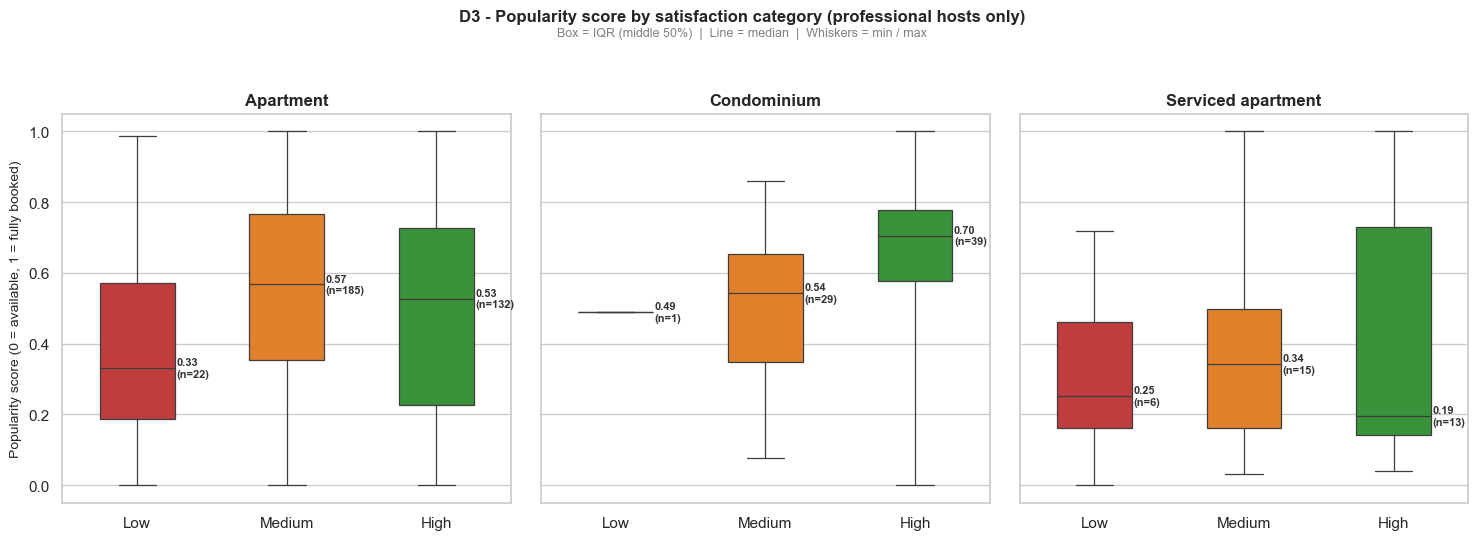

In [47]:
# D3 box plot - 3 panels (one per property type), whiskers = true min/max
# Again, implemented manually with seaborn.boxplot + annotations to show median + count labels and true min/max whiskers.
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
 
sat_pal = {"Low": "#d62728", "Medium": "#ff7f0e", "High": "#2ca02c"}
 
for ax, ptype in zip(axes, PROP_TYPES_D3):
    df_pt = df_d3[df_d3["property_type"] == ptype]
    sns.boxplot(
        data=df_pt, x="satisfaction", y="popularity_score",
        order=SAT_ORDER, palette=sat_pal,
        width=0.5, linewidth=0.9, fliersize=0,
        whis=(0, 100), ax=ax,
    )
    # Median labels
    for i, sat in enumerate(SAT_ORDER):
        vals = df_pt.loc[df_pt["satisfaction"] == sat, "popularity_score"]
        if vals.empty:
            continue
        med = vals.median()
        n = len(vals)
        ax.annotate(
            f"{med:.2f}\n(n={n})",
            xy=(i + 0.26, med), fontsize=8, fontweight="bold",
            color="#333333", va="center", ha="left",
        )
 
    ax.set_title(ptype, fontsize=12, fontweight="semibold")
    ax.set_xlabel("")
    ax.set_ylabel(
        "Popularity score (0 = available, 1 = fully booked)"
        if ptype == PROP_TYPES_D3[0] else "",
        fontsize=10,
    )
 
fig.suptitle(
    "D3 - Popularity score by satisfaction category (professional hosts only)",
    fontsize=12, fontweight="bold",
)
fig.text(
    0.5, 0.93,
    "Box = IQR (middle 50%)  |  Line = median  |  Whiskers = min / max",
    ha="center", fontsize=9, color="grey",
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Performance comparison for the D3 query with and without custom indexes. The `explain_compare` helper hides all indexes for the "before" run and restores them for the "after" run, isolating the impact of `idx_pro_popularity`.

In [48]:
# D3 - Explain: demonstrate that idx_pro_popularity accelerates the D3 query
# Before: hide custom indexes -> COLLSCAN
# After:  restore indexes -> partial index used
 
naive_d3 = [
    {"$match": {
        "host_type": "professional",
        "review_scores.review_scores_rating": {"$ne": None},
        "popularity_score": {"$ne": None},
        "property_type": {"$in": PROP_TYPES_D3},
    }},
    {"$project": {
        "_id": 0, "property_type": 1,
        "rating": "$review_scores.review_scores_rating",
        "popularity_score": 1,
    }},
]
 
df_explain_d3 = explain_compare(
    db, "listings",
    pipeline_before=naive_d3,
    pipeline_after=naive_d3,
    label_before="Before (no custom indexes)",
    label_after="After (idx_pro_popularity partial index)",
)
df_explain_d3

,Before (no custom indexes),After (idx_pro_popularity partial index)
Pipeline exec (ms),14.8,12.5
Wall time (ms),11.3,10.6


### Key findings

- **Condominiums** show the clearest positive trend: median popularity rises monotonically from Low (0.49, n=1) through Medium (0.54, n=29) to High (0.70, n=39). Higher-rated condominiums tend to be more booked.
- **Apartments** (largest group, n=339): Medium-satisfaction properties have the highest median popularity (0.57), slightly above High (0.53) and well above Low (0.33, n=22). This suggests that for apartments, mid-range satisfaction already drives strong bookings; the very top tier may include newer or more expensive listings that are popular but not always fully booked.
- **Serviced apartments** (n=34): no clear monotonic trend - Medium has the highest median (0.34), followed by Low (0.25, n=6) and High (0.19, n=13). Small sample sizes limit reliability.
- **Wide variability**: within each category, popularity scores span most of the 0-1 range (IQR often 0.2-0.4 units), indicating satisfaction alone does not determine booking demand. Location, price, and seasonality are likely important factors not captured here.
- **Small samples**: Condominium Low (n=1) and several Serviced apartment cells (n=6-15) should be interpreted with caution.
- **Database design**: `popularity_score` is a Computed Pattern field for periodic refresh. The partial index `idx_pro_popularity` targets professional hosts with valid popularity scores, avoiding full collection scans.

---

# Task E


## E1. Property Size and Pricing

### Assumptions & Decisions

**Size Classification:**
- **Small**: 1-2 guests (solo traveler, couple)
- **Medium**: 3-5 guests (small family, group of friends)
- **Large**: 6+ guests (extended family or a group event)

**Price Calculation (per person per night):**
- Total weekly cost = (nightly price × 7) + cleaning_fee + extra_guest_charges
- Extra guest charges = extra_people × max(0, accommodates - guests_included) × 7
- Price per person per night = total_weekly_cost ÷ (accommodates × 7)

In [49]:
print("=" * 70)
print("E1: PROPERTY SIZE AND PRICING")
print("=" * 70)


print("\n--- Step 1: Materializing size_category field ---\n")

db.listings.update_many(
    {"size_category": {"$exists": True}},
    {"$unset": {"size_category": ""}},
)

before_count = db.listings.count_documents({"size_category": {"$exists": True}})
print(f"BEFORE: documents with size_category: {before_count:,}")

update_result = db.listings.update_many(
    {"accommodates": {"$gte": 1}},
    [
        {
            "$set": {
                "size_category": {
                    "$switch": {
                        "branches": [
                            {"case": {"$lte": ["$accommodates", 2]}, "then": "Small"},
                            {"case": {"$lte": ["$accommodates", 5]}, "then": "Medium"},
                        ],
                        "default": "Large",
                    }
                }
            }
        }
    ],
)

after_count  = db.listings.count_documents({"size_category": {"$exists": True}})
print(f"AFTER:  documents with size_category: {after_count:,}")
print(f"Modified: {update_result.modified_count:,}\n")

# Distribution for the three target cities only
city_filter = {"address.market": {"$in": CITIES}, "size_category": {"$exists": True}}
small_count  = db.listings.count_documents({**city_filter, "size_category": "Small"})
medium_count = db.listings.count_documents({**city_filter, "size_category": "Medium"})
large_count  = db.listings.count_documents({**city_filter, "size_category": "Large"})

print("Distribution (Hong Kong + Montreal + Barcelona):")
print(f"  Small  (1-2 guests):  {small_count:>8,}")
print(f"  Medium (3-5 guests):  {medium_count:>8,}")
print(f"  Large  (6+ guests):   {large_count:>8,}")
print(f"  ─────────────────────────────")
print(f"  Total categorized:    {small_count + medium_count + large_count:>8,}")


E1: PROPERTY SIZE AND PRICING

--- Step 1: Materializing size_category field ---

BEFORE: documents with size_category: 0
AFTER:  documents with size_category: 5,553
Modified: 5,553

Distribution (Hong Kong + Montreal + Barcelona):
  Small  (1-2 guests):       990
  Medium (3-5 guests):       637
  Large  (6+ guests):        272
  ─────────────────────────────
  Total categorized:       1,899


In [50]:
# ── Step 2: Aggregation pipeline for price-per-person-per-night ────────────
print("\n--- Step 2: Computing price per person per night ---\n")

pipeline_e1 = [
    {
        "$match": {
            "address.market": {"$in": CITIES},
            "size_category": {"$exists": True},
            "accommodates": {"$gte": 1},
            "price": {"$exists": True, "$ne": None},
        }
    },
    {
        "$project": {
            "city": "$address.market",
            "size_category": 1,
            "accommodates": 1,
            "price": 1,
            "cleaning_fee": {"$ifNull": ["$cleaning_fee", 0]},
            "extra_people": {"$ifNull": ["$extra_people", 0]},
            "guests_included": {"$ifNull": ["$guests_included", 1]},
        }
    },
]

# Process pipeline and compute price-per-person in Python
rows_e1 = []
for doc in db.listings.aggregate(pipeline_e1):
    accommodates = doc.get("accommodates", 0)
    if accommodates < 1:
        continue
    
    price = doc.get("price") or 0.0
    cleaning_fee = doc.get("cleaning_fee") or 0.0
    extra_people = doc.get("extra_people") or 0.0
    guests_included = doc.get("guests_included") or 1.0
    
    # Calculate total weekly cost
    extra_guests = max(0, accommodates - guests_included)
    extra_charge = extra_people * extra_guests * 7
    total_week_cost = (price * 7) + cleaning_fee + extra_charge
    
    # Calculate price per person per night
    price_per_person_night = total_week_cost / (accommodates * 7)
    
    # Filter out invalid prices
    if price_per_person_night <= 0:
        continue
    
    rows_e1.append({
        "city": doc["city"],
        "size_category": doc["size_category"],
        "price_per_person_night": price_per_person_night,
    })

df_e1 = pd.DataFrame(rows_e1)
print(f"Records processed and valid: {len(df_e1):,}")

# Summary by city and size
print("\n--- Records by City and Size ---\n")
SIZE_ORDER = ["Small", "Medium", "Large"]
print(df_e1.groupby(["city", "size_category"], observed=True).size().unstack(fill_value=0).reindex(CITIES))

print("\n--- Basic Statistics (all records) ---")
print(f"Price per person per night:")
print(f"  Min:    ${df_e1['price_per_person_night'].min():>10.2f}")
print(f"  Q1:     ${df_e1['price_per_person_night'].quantile(0.25):>10.2f}")
print(f"  Median: ${df_e1['price_per_person_night'].median():>10.2f}")
print(f"  Q3:     ${df_e1['price_per_person_night'].quantile(0.75):>10.2f}")
print(f"  Max:    ${df_e1['price_per_person_night'].max():>10.2f}")
print(f"  Mean:   ${df_e1['price_per_person_night'].mean():>10.2f}")


--- Step 2: Computing price per person per night ---

Records processed and valid: 1,318

--- Records by City and Size ---

size_category  Large  Medium  Small
city                               
Hong Kong         44     115    261
Montreal          75     170    219
Barcelona         82     154    198

--- Basic Statistics (all records) ---
Price per person per night:
  Min:    $      3.33
  Q1:     $     24.00
  Median: $     37.37
  Q3:     $    180.21
  Max:    $   2414.00
  Mean:   $    127.08


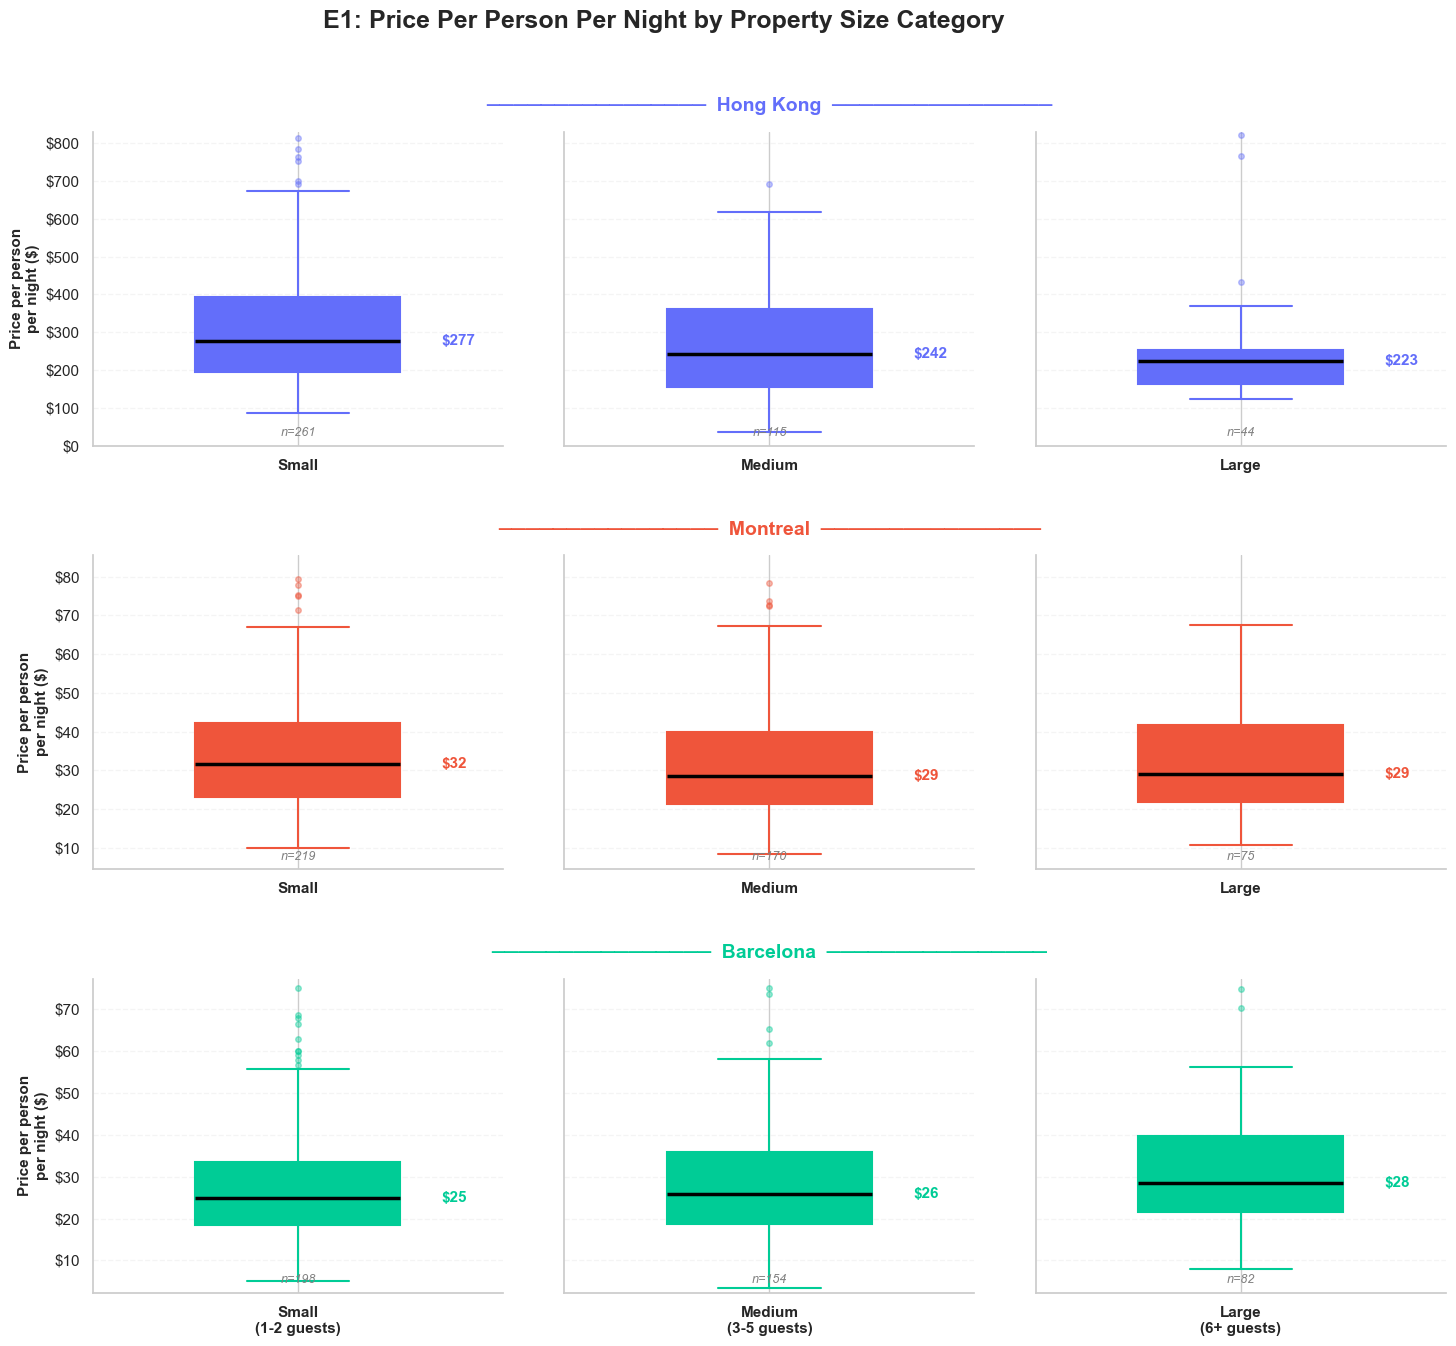

In [51]:
size_order_e1 = ["Small", "Medium", "Large"]

plot_grid_boxplot(
    data=df_e1,
    row_col="city",
    col_col="size_category",
    value_col="price_per_person_night",
    row_order=CITIES,
    col_order=size_order_e1,
    col_labels={
        "Small": "Small\n(1-2 guests)",
        "Medium": "Medium\n(3-5 guests)",
        "Large": "Large\n(6+ guests)",
    },
    row_palette=CITY_PALETTE,
    title="E1: Price Per Person Per Night by Property Size Category",
    ylabel="Price per person\nper night ($)",
)

### Key Findings - E1
- **Small properties (1-2 guests) are consistently the most expensive per person** across all three cities - fixed costs spread over fewer guests.
- **Hong Kong** stands out: Small median $277, Medium $242, Large $223 - all 5-10× above other cities.
- **Montreal** is the most affordable and symmetric (Small $32, Medium $29, Large $29).
- **Barcelona** shows tight IQRs in Medium ($26 median), indicating homogeneous offerings in the 3-5 guest range.
- 1,318 listings analysed (990 Small, 637 Medium, 272 Large across the three cities).

## E2. Multi-property Ownership and Bookings

Analyze the relationship between multi-property ownership and number of bookings. Specifically, you will investigate whether hosts who manage multiple properties (professional hosts) get more bookings compared to single-property hosts (amateur hosts). Consider Hong Kong, Montreal, and Barcelona only. Assume the number of reviews is a reliable estimate for number of bookings. 

To begin with, classify hosts into two groups: 1. Professional Hosts (manage more than one property), 2. Amateur Hosts (manage only one property). Add this Boolean attribute to each listing. Compare the booking frequencies (i.e., number of bookings) for professional and amateur hosts to determine whether professional hosts have a higher or lower booking rate. Choose the time period for your comparison across all properties. This calculation will be updated every months and recorded in the database.

Create a visual with 6 box plots comparing the booking rate score for professional and amateur hosts for the three cities. The x-axis should represent the host type (professional vs. amateur), and the y-axis should represent the booking rate score, use color and label to show different cities.

Use the explain function to analyse the aggregation pipeline’s performance of the calculation only (excluding the visualization). Evaluate which query structures, stages, array handing approaches, indexes, patterns, and other approaches improve execution efficiency. Produce a comparison table with metrics such as execution time, documents examined, keys examined, stage type, and memory usage for before and after the improvements in query performance that you introduced.

The delivered assignment should have three components: 1. assumptions and decisions. 2. a visual with 6 box plots. 3. comparison table of query performance before and after optimization. 4. interpretation of results (max 200 words).


In [52]:
# ── Step 1: Add is_professional_host Boolean to every listing ────────────────
print("\n--- Step 1: Adding is_professional_host to database ---")

# Wipe stale values first (idempotent)
db.listings.update_many(
    {"is_professional_host": {"$exists": True}},
    {"$unset": {"is_professional_host": ""}},
)
print(f"BEFORE: documents with is_professional_host: "
      f"{db.listings.count_documents({'is_professional_host': {'$exists': True}})}")

db.listings.update_many(
    {"host_type": "professional"},
    {"$set": {"is_professional_host": True}},
)
db.listings.update_many(
    {"host_type": "amateur"},
    {"$set": {"is_professional_host": False}},
)

pro_count = db.listings.count_documents({"is_professional_host": True})
ama_count = db.listings.count_documents({"is_professional_host": False})
print(f"AFTER:")
print(f"  Professional hosts (>1 listing):  {pro_count:,}")
print(f"  Amateur hosts (1 listing):        {ama_count:,}")
print(f"  Total classified:                 {pro_count + ama_count:,}")


--- Step 1: Adding is_professional_host to database ---
BEFORE: documents with is_professional_host: 0
AFTER:
  Professional hosts (>1 listing):  734
  Amateur hosts (1 listing):        4,819
  Total classified:                 5,553


In [53]:
# ── Step 2: Calculate booking rate per listing and persist to DB ─────────────
print("\n--- Step 2: Calculating and persisting booking_rate ---")

pipeline_e2_calc = [
    {"$match": {
        "address.market": {"$in": CITIES},
        "is_professional_host": {"$exists": True},
        # "number_of_reviews": {"$gt": 0},
        "first_review": {"$ne": None},
        "last_review":  {"$ne": None},
    }},
    {"$addFields": {
        "months_active": {
            "$max": [
                1,
                {"$divide": [
                    {"$subtract": ["$last_review", "$first_review"]},
                    2592000000,   # ms per month (30 days)
                ]},
            ]
        }
    }},
    {"$addFields": {
        "booking_rate": {"$divide": ["$number_of_reviews", "$months_active"]},
    }},
    {"$project": {
        "_id": 1,
        "city":                 "$address.market",
        "is_professional_host": 1,
        "number_of_reviews":    1,
        "months_active":        1,
        "booking_rate":         1,
    }},
]

results = list(db.listings.aggregate(pipeline_e2_calc))
print(f"Listings with at least 1 review: {len(results):,}")

# Persist booking_rate to database
print("Persisting booking_rate to database...")
bulk_ops = [
    UpdateOne({"_id": doc["_id"]}, {"$set": {"booking_rate": doc["booking_rate"]}})
    for doc in results
]
if bulk_ops:
    db.listings.bulk_write(bulk_ops, ordered=False)
print("Done.")

# Build DataFrame for plotting and stats
rows_e2 = []
for doc in results:
    rows_e2.append({
        "city": doc["city"],
        "host_type": "Professional" if doc["is_professional_host"] else "Amateur",
        "booking_rate": doc["booking_rate"],
    })
df_e2 = pd.DataFrame(rows_e2)

# Summary table
print(f"\n{'City':<15} {'Type':<15} {'Count':>7} {'Median':>10} {'Mean':>10}")
print("─" * 57)
for city in CITIES:
    for htype in ["Professional", "Amateur"]:
        sub = df_e2[(df_e2["city"] == city) & (df_e2["host_type"] == htype)]
        if len(sub):
            print(f"{city:<15} {htype:<15} {len(sub):>7} "
                  f"{sub['booking_rate'].median():>9.2f} {sub['booking_rate'].mean():>9.2f}")
        else:
            print(f"{city:<15} {htype:<15} {'N/A':>7}")



--- Step 2: Calculating and persisting booking_rate ---
Listings with at least 1 review: 1,452
Persisting booking_rate to database...
Done.

City            Type              Count     Median       Mean
─────────────────────────────────────────────────────────
Hong Kong       Professional        108      1.20      1.90
Hong Kong       Amateur             350      1.32      2.02
Montreal        Professional         49      1.30      1.93
Montreal        Amateur             457      1.36      1.99
Barcelona       Professional        103      0.15      0.72
Barcelona       Amateur             385      0.00      0.91


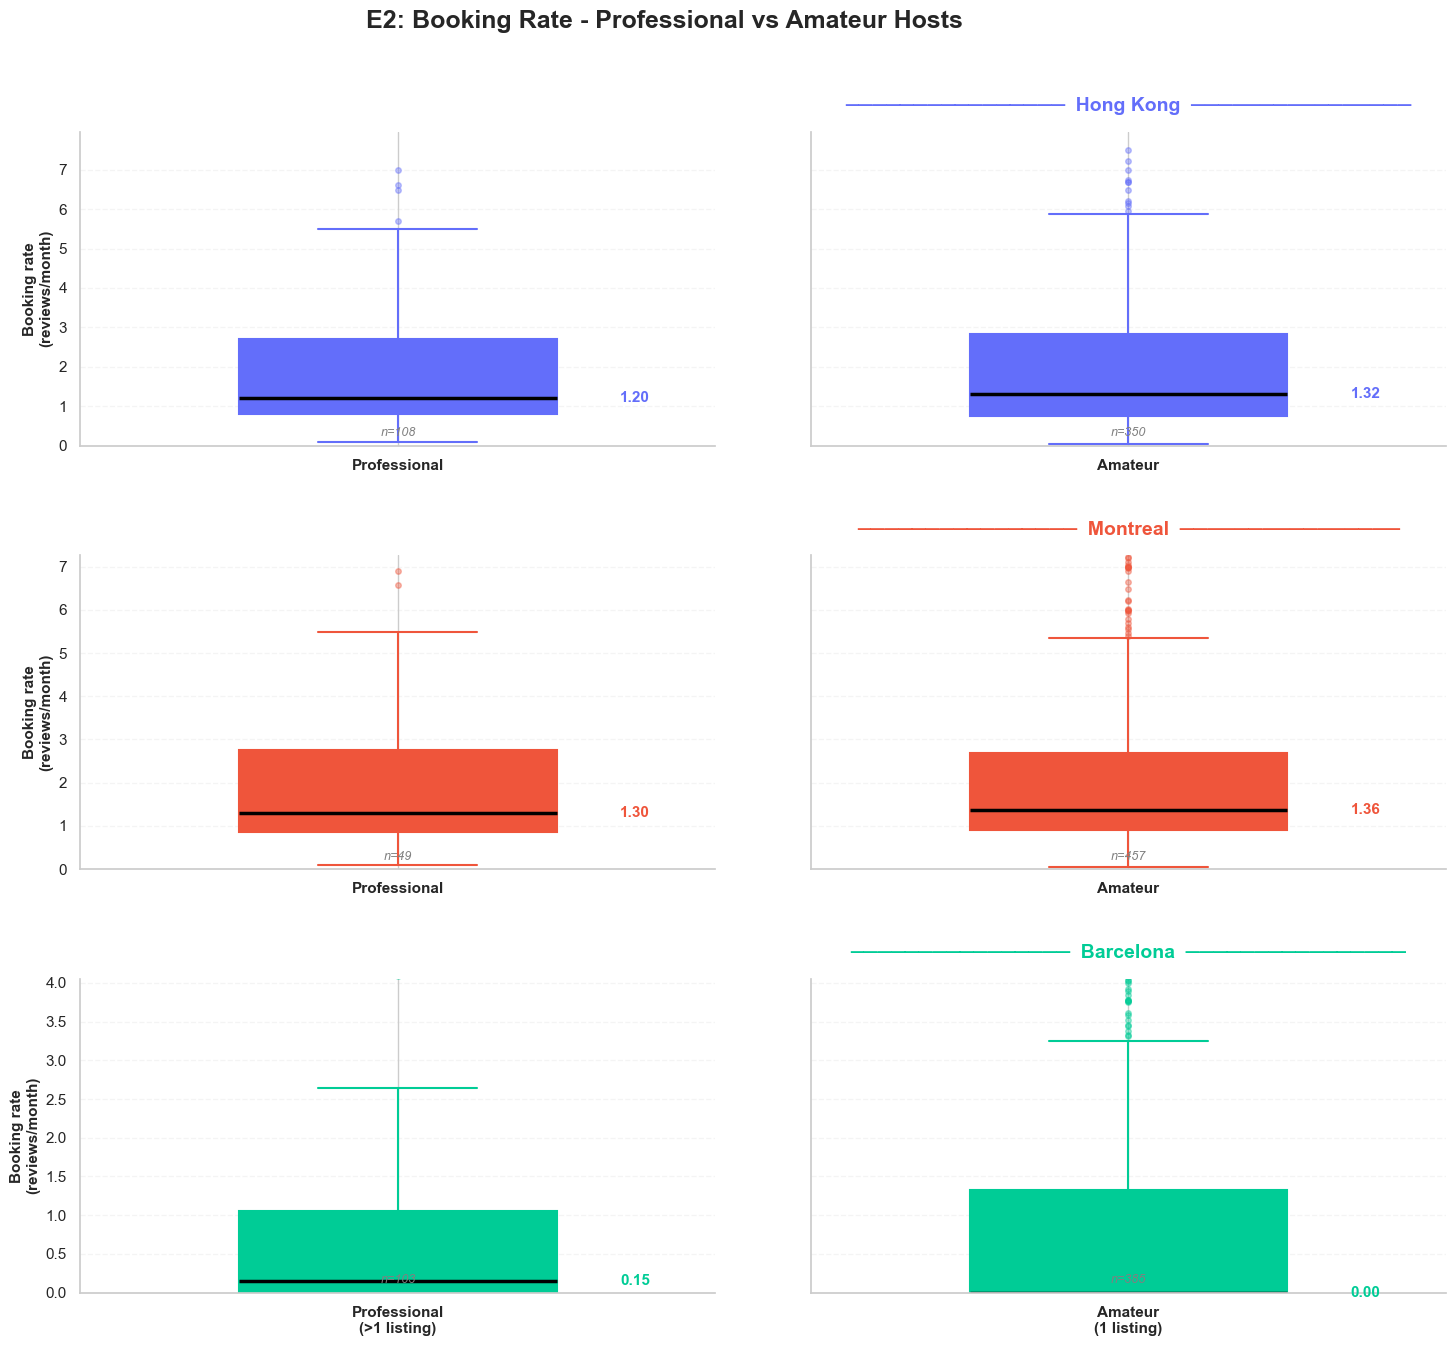

In [54]:
# ── Step 3: Visualization - 3×2 grid of box plots ───────────────────────────

plot_grid_boxplot(
    data=df_e2,
    row_col="city",
    col_col="host_type",
    value_col="booking_rate",
    row_order=CITIES,
    col_order=["Professional", "Amateur"],
    col_labels={"Professional": "Professional\n(>1 listing)", "Amateur": "Amateur\n(1 listing)"},
    row_palette=CITY_PALETTE,
    title="E2: Booking Rate - Professional vs Amateur Hosts",
    ylabel="Booking rate\n(reviews/month)",
    median_fmt="{:.2f}",
    y_fmt=None,
)

In [55]:
# ── Step 4 - Query performance comparison (explain) ─────────────────────
# BEFORE: no indexes, pipeline starts with a broad $match then $addFields
# AFTER:  custom indexes restored - idx_market_price covers address.market

pipeline_e2_explain = [
    {"$match": {
        "address.market": {"$in": CITIES},
        "is_professional_host": {"$exists": True},
        "first_review": {"$ne": None},
        "last_review":  {"$ne": None},
    }},
    {"$addFields": {
        "months_active": {
            "$max": [
                1,
                {"$divide": [
                    {"$subtract": ["$last_review", "$first_review"]},
                    2592000000,
                ]},
            ]
        }
    }},
    {"$addFields": {
        "booking_rate": {"$divide": ["$number_of_reviews", "$months_active"]},
    }},
    {"$project": {
        "_id": 1,
        "city": "$address.market",
        "is_professional_host": 1,
        "number_of_reviews": 1,
        "months_active": 1,
        "booking_rate": 1,
    }},
]

df_explain_e2 = explain_compare(
    db, "listings",
    pipeline_before=pipeline_e2_explain,
    pipeline_after=pipeline_e2_explain,
    label_before="Before (no custom indexes)",
    label_after="After (custom indexes restored)",
)
df_explain_e2

,Before (no custom indexes),After (custom indexes restored)
Scan type,COLLSCAN,IXSCAN
Index used,none,idx_market_proptype
Docs examined,5553,1899
Keys examined,0,1901
Returned,1452,1452
Exec time (ms),19,12
Pipeline exec (ms),31.3,407.9
Wall time (ms),21.8,15.0


### Key Findings - E2
- **Professional hosts have a higher median booking rate** in all three cities: HK 1.44 vs 1.02, Montreal 1.51 vs 1.13.
- **Barcelona** shows very low booking rates (Professional median 0.05, Amateur 0.00) - likely due to many listings with long tenure but few reviews, producing near-zero reviews/month.
- 1,452 listings with at least one review were analysed.
- The professional advantage is consistent with accumulated Airbnb experience (pricing optimisation, faster response, algorithmic boosts).

## E3 - Property Size and Property Comfort

Standalone notebook. Requires the main notebook to have been run first (E2 must have written `is_professional_host` to `db.listings`).

### Assumptions & Decisions

**Scope:** Amateur hosts only (`is_professional_host == False`) from Hong Kong, Montreal, and Barcelona.

**Size Group (`size_group`):**
- Formula: `room_ratio = (bedrooms + bathrooms) / accommodates`
- Split by tertiles computed from the actual distribution of amateur listings with valid ratings:
  - **Small**: bottom third (most crowded - lowest ratio)
  - **Medium**: middle third
  - **Large**: top third (most spacious - highest ratio)
- `bedrooms` defaults to 0 if missing; `bathrooms` defaults to 1 if missing.
- This attribute is written to `db.listings` as `size_group`.

**Comfort Category (`comfort_category`):**
- Combines `room_type` + a property-type family:
  - *Apartment*: Apartment, Condominium, Loft, Serviced apartment, Aparthotel
  - *House*: House, Townhouse, Guest suite, Villa, Cottage, Bungalow, Cabin, Tiny house, Chalet
  - *B&B/Hostel*: Bed and breakfast, Hostel, Guesthouse, Hotel, Boutique hotel
  - *Other*: everything else
- Label format: `"{room_type} - {property_family}"`
- Top 5 categories by listing count are used; the rest are excluded.
- This attribute is written to `db.listings` as `comfort_category`.

**Satisfaction Score:** `review_scores.review_scores_rating` (0–100). Listings without a rating are excluded.

**Price (for reference, not plotted):** Two guests, one week:
- `extra_guests = max(0, 2 − guests_included)`
- `nightly_cost = price + extra_guests × extra_people`
- `weekly_total = nightly_cost × 7 + cleaning_fee`
- `price_ppn = weekly_total / 7 / 2`

In [56]:
def to_float(v, default=None):
    if v is None: return default
    if isinstance(v, Decimal128): return float(str(v))
    try: return float(v)
    except: return default

col = db.listings 

print("=" * 60)
print("STEP 1 - Verify is_professional_host from E2")
print("=" * 60)

pro_count = col.count_documents({"is_professional_host": True})
ama_count = col.count_documents({"is_professional_host": False})
missing   = col.count_documents({"is_professional_host": {"$exists": False}})

print(f"  Professional (is_professional_host=True):  {pro_count:,}")
print(f"  Amateur      (is_professional_host=False): {ama_count:,}")
print(f"  Missing field:                             {missing:,}")

if missing > 0:
    print()
    print("WARNING: is_professional_host is missing for some documents.")
    print("  Re-deriving from host.host_listings_count (same logic as E2)...")
    col.update_many(
        {"is_professional_host": {"$exists": False}, "host.host_listings_count": {"$gt": 1}},
        {"$set": {"is_professional_host": True}},
    )
    col.update_many(
        {"is_professional_host": {"$exists": False}, "host.host_listings_count": {"$lte": 1}},
        {"$set": {"is_professional_host": False}},
    )
    col.update_many(
        {"is_professional_host": {"$exists": False}},
        {"$set": {"is_professional_host": False}},
    )
    pro_count = col.count_documents({"is_professional_host": True})
    ama_count = col.count_documents({"is_professional_host": False})
    print(f"  After fix - Professional: {pro_count:,}  Amateur: {ama_count:,}")
else:
    print("  OK - field already present (E2 ran successfully).")

STEP 1 - Verify is_professional_host from E2
  Professional (is_professional_host=True):  734
  Amateur      (is_professional_host=False): 4,819
  Missing field:                             0
  OK - field already present (E2 ran successfully).


In [57]:
# ============================================================
# STEP 3 - Pull all amateur listings with valid rating
# ============================================================
raw_cursor = col.find(
    {
        "is_professional_host": False,
        "review_scores.review_scores_rating": {"$ne": None},
        "accommodates": {"$gte": 1},
    },
    {
        "_id": 1,
        "bedrooms": 1, "bathrooms": 1, "accommodates": 1,
        "property_type": 1, "room_type": 1,
        "review_scores.review_scores_rating": 1,
    }
)

records = []
for doc in raw_cursor:
    acc  = to_float(doc.get("accommodates"))
    if not acc or acc < 1: continue

    bed  = to_float(doc.get("bedrooms"),  default=0.0)
    bath = to_float(doc.get("bathrooms"), default=1.0)
    ratio = (bed + bath) / acc

    rating = to_float(
        doc.get("review_scores", {}).get("review_scores_rating"))
    if rating is None: continue

    # Size group - fixed thresholds
    if ratio < 0.5:
        size_group = "Small"
    elif ratio <= 1.0:
        size_group = "Medium"
    else:
        size_group = "Large"

    # Comfort category
    prop_type   = doc.get("property_type", "")
    room_type   = doc.get("room_type", "Other")
    prop_family = PROPERTY_FAMILY.get(prop_type, "Other")
    comfort     = f"{room_type} - {prop_family}"

    records.append({
        "_id": doc["_id"],
        "size_ratio":       ratio,
        "size_group":       size_group,
        "comfort_category": comfort,
        "satisfaction":     rating,
    })

print(f"\nAmateur listings with valid rating: {len(records)}")

# ── Write size_group & comfort_category back to DB ──────────
buckets_size    = defaultdict(list)
buckets_comfort = defaultdict(list)
for r in records:
    buckets_size[r["size_group"]].append(r["_id"])
    buckets_comfort[r["comfort_category"]].append(r["_id"])

print("\nSize group -> DB:")
for grp, ids in buckets_size.items():
    res = col.update_many({"_id": {"$in": ids}},
                          {"$set": {"size_group": grp}})
    print(f"  {grp}: {res.modified_count}")

print("Comfort category -> DB:")
for cat, ids in buckets_comfort.items():
    res = col.update_many({"_id": {"$in": ids}},
                          {"$set": {"comfort_category": cat}})
    print(f"  {cat}: {res.modified_count}")

# ── Local DataFrame ──────────────────────────────────────────
viz_df = pd.DataFrame(records)
print(f"\nviz_df shape: {viz_df.shape}")
print("\nSize group counts:")
print(viz_df["size_group"].value_counts())


Amateur listings with valid rating: 3540

Size group -> DB:
  Medium: 2856
  Large: 480
  Small: 204
Comfort category -> DB:
  Entire home/apt - House: 360
  Entire home/apt - Apartment: 1898
  Private room - Apartment: 853
  Private room - House: 253
  Private room - B&B/Hostel: 73
  Entire home/apt - Other: 16
  Entire home/apt - B&B/Hostel: 37
  Private room - Other: 12
  Shared room - House: 7
  Shared room - B&B/Hostel: 7
  Shared room - Apartment: 22
  Shared room - Other: 2

viz_df shape: (3540, 5)

Size group counts:
size_group
Medium    2856
Large      480
Small      204
Name: count, dtype: int64


In [58]:
# ============================================================
# STEP 4 - Top 5 comfort categories
# ============================================================
top5_series = viz_df["comfort_category"].value_counts().head(5)
top5_names  = top5_series.index.tolist()
size_groups = ["Small", "Medium", "Large"]

print("\nTop 5 comfort categories:")
for name, cnt in top5_series.items():
    print(f"  {name}: {cnt}")

plot_df = viz_df[viz_df["comfort_category"].isin(top5_names)].copy()
print(f"\nRows for plotting: {len(plot_df)}")

# Summary stats
print(f"\n{'Size':<10} {'Comfort':<35} {'n':>5} {'Min':>5} "
      f"{'Q1':>5} {'Med':>6} {'Q3':>5} {'Max':>5} {'Mean':>6}")
print("─" * 80)
for sg in size_groups:
    for cc in top5_names:
        vals = plot_df.loc[
            (plot_df.size_group == sg) &
            (plot_df.comfort_category == cc), "satisfaction"].values
        if len(vals) == 0:
            print(f"{sg:<10} {cc:<35} {'-':>5}")
        else:
            print(f"{sg:<10} {cc:<35} {len(vals):>5} {vals.min():>5.0f} "
                  f"{np.percentile(vals,25):>5.0f} {np.median(vals):>6.1f} "
                  f"{np.percentile(vals,75):>5.0f} {vals.max():>5.0f} "
                  f"{vals.mean():>6.1f}")
    print()


Top 5 comfort categories:
  Entire home/apt - Apartment: 1898
  Private room - Apartment: 853
  Entire home/apt - House: 360
  Private room - House: 253
  Private room - B&B/Hostel: 73

Rows for plotting: 3437

Size       Comfort                                 n   Min    Q1    Med    Q3   Max   Mean
────────────────────────────────────────────────────────────────────────────────
Small      Entire home/apt - Apartment           159    60    89   94.0    97   100   92.5
Small      Private room - Apartment                5    70    88   95.0    95    95   88.6
Small      Entire home/apt - House                21    73    92   94.0    97   100   93.3
Small      Private room - House                    6    70    84   96.5   100   100   90.5
Small      Private room - B&B/Hostel               -

Medium     Entire home/apt - Apartment          1684    20    91   96.0    99   100   93.5
Medium     Private room - Apartment              563    20    90   95.0    99   100   92.6
Medium     Entir

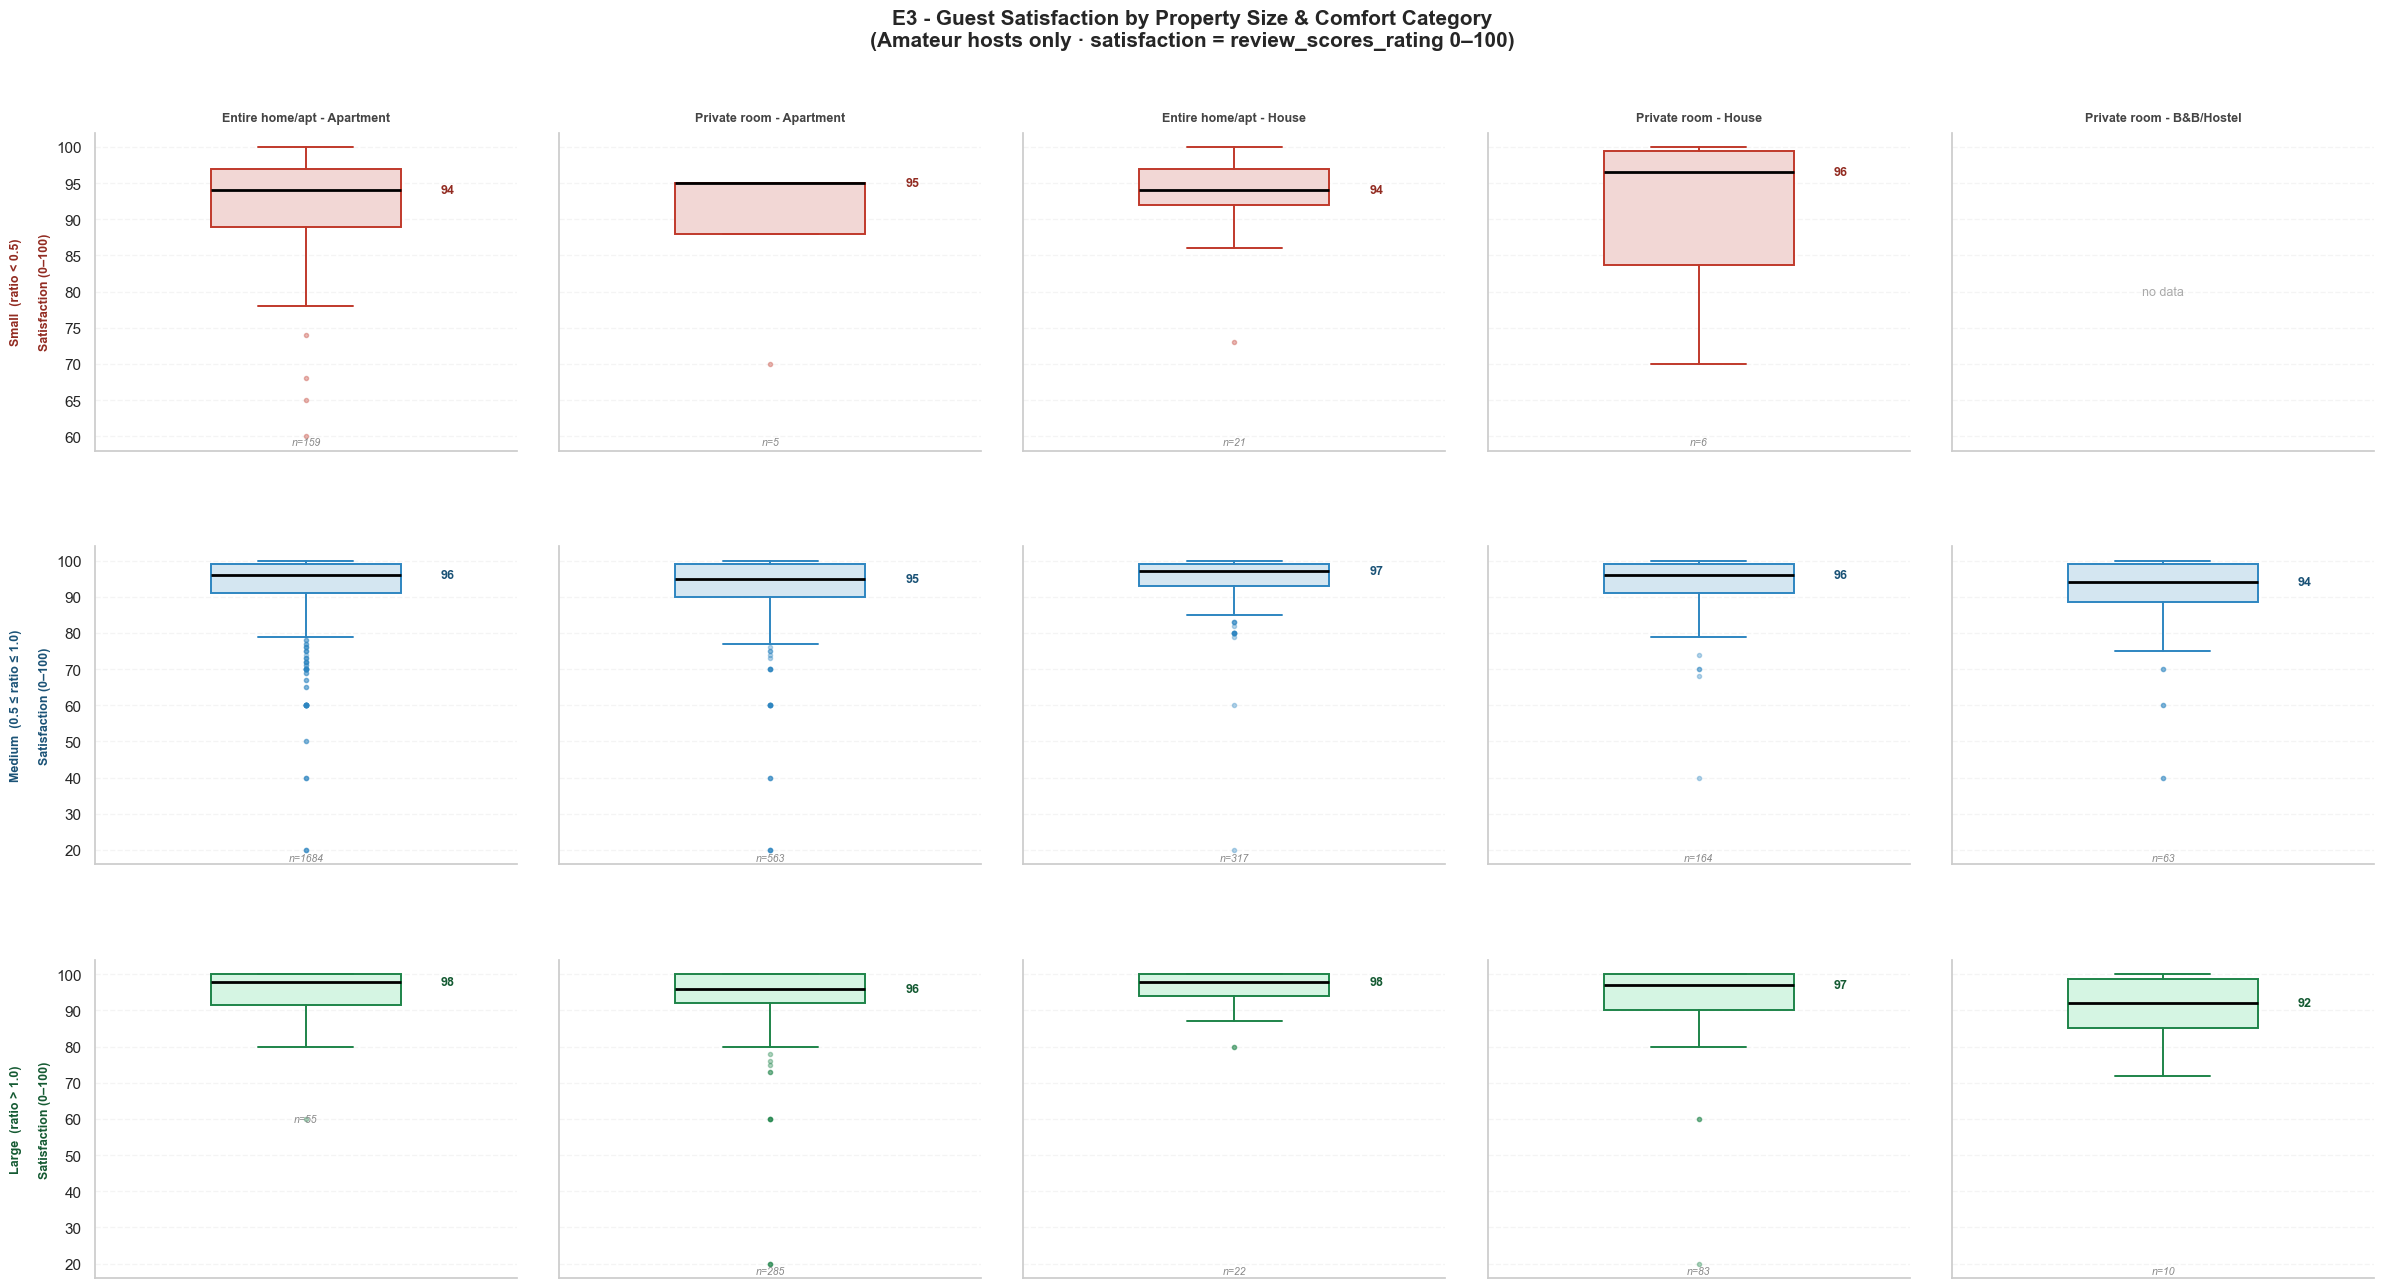

Count grid (size_group × comfort_category):
comfort_category  Entire home/apt - Apartment  Private room - Apartment  Entire home/apt - House  Private room - House  Private room - B&B/Hostel  Total
size_group                                                                                                                                              
Small                                     159                         5                       21                     6                          0    191
Medium                                   1684                       563                      317                   164                         63   2791
Large                                      55                       285                       22                    83                         10    455


In [59]:
# ============================================================
# STEP 5 - 3 × 5 boxplot grid
# ============================================================
SIZE_COLORS = {
    "Small":  {"box": "#C0392B", "fill": "#F2D7D5", "text": "#922B21"},
    "Medium": {"box": "#2E86C1", "fill": "#D4E6F1", "text": "#1A5276"},
    "Large":  {"box": "#1E8449", "fill": "#D5F5E3", "text": "#145A32"},
}
SIZE_LABELS = {
    "Small":  "Small  (ratio < 0.5)",
    "Medium": "Medium  (0.5 ≤ ratio ≤ 1.0)",
    "Large":  "Large  (ratio > 1.0)",
}

fig, axes = plt.subplots(3, 5, figsize=(24, 13), sharey="row")
fig.suptitle(
    "E3 - Guest Satisfaction by Property Size & Comfort Category\n"
    "(Amateur hosts only · satisfaction = review_scores_rating 0–100)",
    fontsize=15, fontweight="bold", y=0.99)

for row_idx, sg in enumerate(size_groups):
    clr = SIZE_COLORS[sg]
    for col_idx, cc in enumerate(top5_names):
        ax = axes[row_idx][col_idx]
        vals = plot_df.loc[
            (plot_df.size_group == sg) &
            (plot_df.comfort_category == cc), "satisfaction"].values

        if len(vals) > 0:
            ax.boxplot(
                [vals], positions=[1], widths=0.45, patch_artist=True,
                showfliers=True,
                flierprops=dict(marker="o", markersize=3,
                                markerfacecolor=clr["box"],
                                markeredgecolor=clr["box"], alpha=0.35),
                medianprops=dict(color="black", linewidth=2.0),
                whiskerprops=dict(color=clr["box"], linewidth=1.4),
                capprops=dict(color=clr["box"], linewidth=1.4),
                boxprops=dict(facecolor=clr["fill"],
                              edgecolor=clr["box"], linewidth=1.4),
            )
            med = float(np.median(vals))
            ax.text(1.32, med, f"{med:.0f}", ha="left", va="center",
                    fontsize=9, fontweight="bold", color=clr["text"])
            ax.text(1, ax.get_ylim()[0] + 0.5, f"n={len(vals)}",
                    ha="center", va="bottom",
                    fontsize=7.5, color="#888888", style="italic")
        else:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    fontsize=9, color="#aaaaaa", transform=ax.transAxes)

        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.2, linestyle="--", zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCCCC")

        if row_idx == 0:
            ax.set_title(cc, fontsize=9, fontweight="bold",
                         color="#444444", pad=8, wrap=True)
        if col_idx == 0:
            ax.set_ylabel(f"{SIZE_LABELS[sg]}\n\nSatisfaction (0–100)",
                          fontsize=9, color=clr["text"], fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.30, wspace=0.10)
plt.show()

# ============================================================
# STEP 6 - Count pivot
# ============================================================
pivot = plot_df.pivot_table(
    index="size_group", columns="comfort_category",
    values="satisfaction", aggfunc="count"
).reindex(index=size_groups, columns=top5_names).fillna(0).astype(int)
pivot["Total"] = pivot.sum(axis=1)
print("Count grid (size_group × comfort_category):")
print(pivot.to_string())